# Gap-Filling & Distressed Time-Series Reconstruction
### Equity Portfolio · Distress Events · Restructuring Regime Breaks · Peer-Based Proxy Methods

A comprehensive notebook for reconstructing corrupted price data during
distressed periods using peer-based proxy methods, with drift detection,
model optimisation (OLS / Ridge), and strategy backtesting.

### How This Notebook is Organised

| Section | What You'll Learn | Key Output |
|---------|-------------------|------------|
| **0** | The problem — distressed stock series and why they matter | Why peer-based reconstruction is needed |
| **1** | Data loading, peer selection, and scoring | `load_data()` · `select_peers()` with peer/vol/composite scores |
| **2** | Diagnostics — correlation, volatility ratio, cointegration, peer visualisation | Peer ranking tables, 2×2 dashboard, cointegration scoring |
| **3A–3F** | Reconstruction methods | Simple fill · Static · Dynamic · ML Proxy · ML Optimisation · Cointegration Proxy |
| **4** | Evaluation — compare all methods | RMSE · MAE · Return Corr · Per-method grid |
| **—** | How we reconstruct prices from returns (debugger's guide) | Return-to-price chain, compounding mechanics, drift maths |
| **5** | Drift detection & correction | Residual Bias · Rolling Bias · Error Feedback |
| **6** | Backtesting — strategy impact | Mean-reversion P&L comparison across methods |
| **7** | Beginner's guide & recommendations | When to use each method |

## 0. The Problem — What Is a "Distressed" Stock Series?

> **In plain English**: imagine you are a quant analyst backtesting a portfolio strategy.
> Your historical price data for one stock looks fine most of the time, but in one specific
> period prices become misleading relative to sector peers:
>
> **A distress-and-restructuring episode** — for 30 days the stock crashes, trades like a
> distressed security, and then emerges as a **restructured company**. From that point onward,
> it should be treated economically as a *new regime* with different betas, different volatility,
> and potentially a different business mix.

### Why Does This Matter?

| Use-case | What goes wrong with raw corrupted data |
|----------|-----------------------------------------|
| Backtesting | Strategy returns are distorted during the event |
| Risk models (VaR/CVaR) | Covariance matrix can mix incompatible regimes |
| Factor models | Beta estimates from the legacy stock are contaminated by post-restructuring behavior |
| Portfolio optimisation | The optimiser treats different economic states as one asset |
| ML features | Regime break harms stationarity |

### Our Approach

We reconstruct **what the legacy pre-restructuring price series would have looked like
during the distressed window** using peer-based proxy methods of increasing complexity:

| Tier | Method | Regressor | Complexity |
|------|--------|-----------|------------|
| **Simple** | Forward fill / Backward fill / Linear interpolation | — | ⭐ |
| **Static Proxy** | Snapshot peer selection before distress | OLS | ⭐⭐ |
| **Dynamic Proxy** | Rolling peer selection each day of distress | OLS | ⭐⭐⭐ |
| **ML Proxy** | Feature-based clustering (returns, vol, drawdown) | OLS | ⭐⭐⭐⭐ |
| **ML Optimisation** | Grid search over LOOKBACK × CLUSTER_THR for ML Proxy | OLS | ⭐⭐⭐⭐ |
| **Cointegration** | Error-correction reconstruction from cointegrated peers | Spread-based | ⭐⭐⭐ |

Beyond reconstruction, the notebook also:

- **Scores peers** — correlation, volatility alignment, return MAE, coverage, and **cointegration** (ADF test on price-level spreads)
- **Reconstructs** — 6 approaches: Simple Fill, Static/ Dynamic/ ML Proxy, ML Optimisation, **Cointegration Proxy**
- **Detects drift** — cumulative prediction error and tracking error over the window
- **Corrects drift** — residual bias, rolling bias, and error feedback methods
- **Optimises** — grid search over LOOKBACK × CLUSTER_THR for ML Proxy parameters
- **Backtests** — compares the trading P&L (mean-reversion strategy) of each method
- **Recommends** — a decision guide matching the right method to your use case

### Key Concepts in This Notebook

| Term | Meaning |
|------|---------|
| **DIST_TRUE** | The true (uncorrupted) price path — used only for evaluation |
| **DIST_OBS** | The observed (corrupted) price path — what you actually see |
| **Distress window** | The period where prices are corrupted |
| **Peer score** | $| \rho | \times \text{coverage} / (1 + \text{MAE})$ — ranks peers by directional alignment |
| **Vol score** | $\exp(-| \ln(\text{VR}) |)$ — ranks peers by volatility alignment |
| **Cointegration score** | $-\text{sign}(\beta) \times \text{ADF-statistic}$ — ranks peers by price-level mean-reversion strength |
| **Composite score** | Weighted blend: 0.3 × peer\_score + 0.3 × vol\_score + 0.4 × coint\_score\_norm |
| **Drift** | The gradual separation between predicted and true prices as errors compound |

> **Note**: this notebook uses real stock data as the legacy reference and injects
> controlled distress-window corruption into `DIST_OBS` for quantitative evaluation.

## Features, Metrics, and When to Use What

This notebook uses several metrics to select and evaluate peer proxies.
Here is a plain-English explanation of each one and when it matters.

---

### 📏 The Four Score Metrics

#### 1. Peer Score — "Does the peer move in the SAME direction as the target?"

$$ \text{peer\_score} = \frac{|\rho| \times \text{coverage}}{1 + \text{MAE}} $$

| Component | What it means |
|-----------|---------------|
| **$|\rho|$ (correlation)** | Do they zig and zag on the same days? 1.0 = perfect lockstep |
| **Coverage** | How much history do they share? 100% = always available |
| **MAE** | Average return difference — how big are the daily mistakes? |

**Use this when:** you are building a *return-prediction* model (OLS/Ridge). The
regression coefficient $\beta$ automatically handles any difference in volatility,
so you mainly need peers that co-move directionally.

#### 2. Vol Score — "Does the peer jump the RIGHT AMOUNT?"

$$ \text{vol\_score} = e^{-|\ln(\text{vol\_ratio})|}, \quad
   \text{vol\_ratio} = \frac{\sigma_{\text{peer}}}{\sigma_{\text{target}}} $$

| VR value | What it means | Vol score |
|----------|---------------|-----------|
| 1.0 | Same volatility — perfect | 1.0 |
| 2.0 | Peer is twice as volatile | 0.69 |
| 0.5 | Peer is half as volatile | 0.69 |
| 3.0 | Peer is three times as volatile | 0.40 |

**Use this when:** you are *directly scaling* a peer's price (not using regression).
If you replace the target's price with 2× a peer's movement, you'll overshoot.

#### 3. Composite Score — "Is the peer a good proxy OVERALL?"

$$ \text{composite\_score} = 0.5 \times \text{norm(peer\_score)} + 0.5 \times \text{vol\_score} $$

This is the **tie-breaker**. A peer with high correlation but very different volatility
will score well on `peer_score` but poorly on `composite_score`. Use this when you want
peers that are truly "similar" in both direction *and* magnitude.

> **Note:** once cointegration scoring is applied (see dedicated cell), the composite
> score is **reweighted** to: $0.3 \times \text{peer\_score} + 0.3 \times \text{vol\_score} + 0.4 \times \text{coint\_score\_norm}$

#### 4. Cointegration Score — "Do the PRICE LEVELS move together long-term?"

$$ \text{coint\_score} = -\text{sign}(\beta) \times \text{ADF-statistic}, \quad
   \text{where } P_{target} = \alpha + \beta \times P_{peer} + \epsilon $$

| Scenario | ADF statistic | Coint score | What it means |
|----------|---------------|-------------|---------------|
| Strong cointegration | Very negative ($\ll -3$) | Large positive | Spread is highly mean-reverting — ideal for error-correction reconstruction |
| Weak cointegration | Near zero | Near zero | Prices drift apart — poor proxy |
| No cointegration | Positive | Negative | Spread is explosive — avoid this peer entirely |

**Use this when:** you are building a *price-level* reconstruction using error
correction (the Cointegration Proxy in Approach 3F). Unlike the other scores which
operate on returns, cointegration captures the long-run equilibrium between price
*levels* — a peer that is cointegrated with the target will have a spread that
mean-reverts, preventing the reconstruction from drifting arbitrarily.

### 🔄 How the Scores Work Together

| Score | Domain | What it captures | Best for |
|-------|--------|------------------|----------|
| **Peer score** | Returns | Short-term directional alignment | OLS regression models |
| **Vol score** | Returns | Volatility magnitude match | Direct price scaling |
| **Cointegration** | Prices | Long-run equilibrium | Error-correction reconstruction |
| **Composite** | Blended | Weighted average of all three | General peer ranking |

---

### 🔀 Which Reconstruction Method Should I Use?

| If you... | Use... | Why |
|-----------|--------|-----|
| Have **no peer data** | **Simple Fill** (forward/backward/linear) | It's all you can do — stretch or connect prices |
| Have peers, short distress (&lt;20 days) | **Static Proxy** | Fast, stable, interpretable; peer relationships don't change much |
| Have peers, long distress (&gt;20 days) | **Dynamic Proxy** | Peer relationships may shift — re-select daily |
| Want the **most sophisticated** approach | **ML Proxy** | Uses 10 features (returns, vol, drawdown) not just correlation |
| Want to **optimise** ML Proxy parameters | **ML Optimisation (Sweep)** | Grid search over LOOKBACK × CLUSTER_THR |
| Have **cointegrated** peers | **Cointegration Proxy** | Error-correction on price-level spreads; resists drift |
| See **prices drifting away over time** | Add **Drift Correction** (Section 5) | Residual bias, rolling bias, or error feedback |

### Quick Decision Tree

```
Do you have peer data?
├── No  → Simple Fill (3A)
└── Yes →
    ├── Short distress window?    → Static Proxy (3B)
    ├── Long or changing window?  → Dynamic Proxy (3C)
    ├── Maximum accuracy?         → ML Proxy (3D) → try Sweep (3E)
    └── Cointegrated price levels?→ Cointegration Proxy (3F)
```

---

### 📊 Correlation vs Volatility Ratio — When to Prioritise Each

| Ask yourself... | Prioritise... | Because... |
|----------------|---------------|------------|
| "Do I care which way the peer moves?" | **Correlation** | Regression models need directional signal |
| "Do I care how MUCH the peer moves?" | **Volatility Ratio** | Direct price scaling needs the right multiplier |
| "Do I care about both?" | **Composite Score** | This blends correlation + vol alignment |

**Rule of thumb:** If you are using **OLS or Ridge regression** (the default in this
notebook), optimise for **correlation** — the regression coefficient handles scaling.
If you are **directly substituting prices**, optimise for **volatility ratio**.

---

### 🔍 What to Look For in the Results

| Metric | What it tells you | Target |
|--------|-------------------|--------|
| **RMSE** | How far off are the reconstructed prices? | Lower = better |
| **Return Corr** | Does the reconstructed *return* path match the true one? | Higher = better (max 1.0) |
| **Price Corr** | Does the reconstructed *price level* match the true one? | Higher = better |
| **Vol Ratio** | Is the reconstructed volatility close to true? | Near 1.0 = best |
| **Final Gap** | How far apart are the prices at the end of the window? | Near 0 = best |
| **Max Drift** | Largest cumulative deviation during the window | Lower = better |
| **Coint Score** | How strongly cointegrated is the peer with the target? | Higher = better (more negative ADF) |

> **Not sure where to start?** Run **Static Proxy + OLS** first. It's the sweet spot
> of simplicity and accuracy. Then try the Cointegration Proxy if you suspect the
> price levels are mean-reverting, or the ML Optimisation sweep to fine-tune.


In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})

In [113]:
import os
from pathlib import Path

# Resolve data directory relative to the notebook location
NOTEBOOK_DIR = Path(os.getcwd())
DATA_DIR = NOTEBOOK_DIR / 'data'


def load_data(data_dir: Path | str = DATA_DIR) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load the instruments catalog and the stock_data time-series panel.

    Parameters
    ----------
    data_dir : Path or str, optional
        Directory containing ``instruments.csv`` and ``stock_data.csv``.
        Defaults to a ``data`` folder in the current working directory.

    Returns
    -------
    instruments_df : pd.DataFrame
        Catalog of instruments (one row per ticker, with sector / metadata).
    stocks_data_df : pd.DataFrame
        Panel of historical OHLC + volume data indexed by date and ticker.
    """
    data_dir = Path(data_dir)
    instruments_df = pd.read_csv(data_dir / 'instruments.csv')
    stocks_data_df = pd.read_csv(data_dir / 'stock_data.csv')
    print(f"Loaded {len(instruments_df)} instruments from 'instruments.csv'")
    print(f"Loaded {stocks_data_df.shape[0]:,} rows from 'stock_data.csv'")
    return instruments_df, stocks_data_df


instruments_df, stocks_data_df = load_data()

Loaded 503 instruments from 'instruments.csv'
Loaded 501 rows from 'stock_data.csv'


In [114]:
def select_peers(
    target_ticker: str,
    instruments_df: pd.DataFrame,
    stocks_data_df: pd.DataFrame,
    min_peer_history_days: int = 120,
    min_peer_coverage: float = 0.85,
    max_model_peers: int = 25,
    include_cross_sector: bool = False,
) -> dict:
    """Build a peer universe around a target instrument.

    The function ranks every candidate in the instrument universe by
    correlation / return MAE / coverage against the target ticker, then
    returns a structured dictionary containing:

    - the long candidate basket (full set of qualifying same-sector peers)
    - the slim model subset (best ``max_model_peers`` for downstream models)
    - the wide prices panel aligned on the common trading calendar
    - the peers metadata frame (target + same-sector peers)
    - convenience lookups for sector and peer bucket
    - a diagnostic performance table sorted by ``peer_score``

    Parameters
    ----------
    target_ticker : str
        Target instrument symbol (case-insensitive), e.g. ``'AAPL'``.
    instruments_df : pd.DataFrame
        Instrument catalog. Must contain ``symbol`` and ``sector`` columns.
    stocks_data_df : pd.DataFrame
        Wide-format OHLC + volume panel with a ``Date`` column.
    min_peer_history_days : int, optional
        Minimum number of overlapping daily returns required for a peer.
    min_peer_coverage : float, optional
        Minimum fraction of non-NaN observations required for a peer.
    max_model_peers : int, optional
        Maximum number of peers kept in the model subset.
    include_cross_sector : bool, optional
        Whether to keep cross-sector peers as a separate diagnostic group.

    Returns
    -------
    dict
        Dictionary with the keys:

        - ``target_ticker`` (str)
        - ``target_sector`` (str)
        - ``same_sector_all`` (list[str])
        - ``same_sector_peers`` (list[str])
        - ``cross_sector_peers`` (list[str])
        - ``model_peer_cols`` (list[str])
        - ``peers_df`` (pd.DataFrame)
        - ``peer_sector_map`` (dict[str, str])
        - ``peer_bucket_map`` (dict[str, list[str]])
        - ``performance_df`` (pd.DataFrame)
        - ``prices_wide`` (pd.DataFrame)
    """
    meta = instruments_df.copy()
    meta['symbol'] = meta['symbol'].astype(str).str.upper()
    sector_lookup = meta.set_index('symbol')['sector'].to_dict()
    target_ticker = target_ticker.upper()
    target_sector = sector_lookup.get(target_ticker)

    prices_wide = stocks_data_df.copy()
    prices_wide['Date'] = pd.to_datetime(prices_wide['Date'])
    prices_wide = prices_wide.sort_values('Date').set_index('Date')
    prices_wide.columns = [str(c).upper() for c in prices_wide.columns]

    # Keep only tickers that also exist in instrument metadata
    valid_tickers = [c for c in prices_wide.columns if c in set(meta['symbol'])]
    prices_wide = prices_wide[valid_tickers]

    if target_ticker not in prices_wide.columns:
        raise ValueError(f'{target_ticker} not available in stocks_data_df')

    # Candidate universe: ALL same-sector tickers
    same_sector_all = [
        s for s in valid_tickers
        if s != target_ticker and sector_lookup.get(s) == target_sector
    ]
    cross_sector_all = [
        s for s in valid_tickers
        if s != target_ticker and sector_lookup.get(s) != target_sector
    ]

    target_ret_all = np.log(prices_wide[target_ticker] / prices_wide[target_ticker].shift(1))

    def _evaluate(cands: list[str]) -> pd.DataFrame:
        rows = []
        for t in cands:
            px = prices_wide[t]
            overlap_px = pd.concat([prices_wide[target_ticker], px], axis=1).dropna()
            if len(overlap_px) < min_peer_history_days:
                continue

            ret_t = np.log(px / px.shift(1))
            overlap_ret = pd.concat([target_ret_all, ret_t], axis=1).dropna()
            if len(overlap_ret) < min_peer_history_days:
                continue

            corr = overlap_ret.iloc[:, 0].corr(overlap_ret.iloc[:, 1])
            vol_ratio = overlap_ret.iloc[:, 1].std() / overlap_ret.iloc[:, 0].std()
            mae = (overlap_ret.iloc[:, 0] - overlap_ret.iloc[:, 1]).abs().mean()
            coverage = prices_wide[t].notna().mean()

            if pd.isna(corr):
                continue

            vol_ratio_val = float(vol_ratio)
            # vol_score: 1.0 when vol_ratio == 1.0, decays as vol_ratio deviates
            vol_score = np.exp(-abs(np.log(vol_ratio_val)))

            perf_score = abs(corr) * coverage / (1.0 + mae)
            # Composite score: equally weighted correlation performance + vol alignment
            composite_score = 0.5 * (perf_score / (perf_score + 1e-10)) + 0.5 * vol_score

            rows.append({
                'ticker': t,
                'sector': sector_lookup.get(t),
                'corr_to_target': float(corr),
                'abs_corr': float(abs(corr)),
                'vol_ratio': vol_ratio_val,
                'vol_score': float(vol_score),
                'ret_mae': float(mae),
                'coverage': float(coverage),
                'overlap_days': int(len(overlap_ret)),
                'peer_score': float(perf_score),
                'composite_score': float(composite_score),
            })

        if not rows:
            return pd.DataFrame(
                columns=['ticker', 'sector', 'corr_to_target', 'abs_corr',
                         'vol_ratio', 'vol_score', 'ret_mae', 'coverage',
                         'overlap_days', 'peer_score', 'composite_score']
            )

        return (
            pd.DataFrame(rows)
            .sort_values(['composite_score', 'peer_score', 'abs_corr'], ascending=False)
            .reset_index(drop=True)
        )

    same_sector_perf = _evaluate(same_sector_all)
    cross_sector_perf = _evaluate(cross_sector_all) if include_cross_sector else pd.DataFrame()

    # Long basket: all same-sector peers that meet the coverage threshold
    long_basket = same_sector_perf[
        same_sector_perf['coverage'] >= min_peer_coverage
    ]['ticker'].tolist()
    if len(long_basket) < 3:
        long_basket = same_sector_perf['ticker'].tolist()
    if len(long_basket) < 3:
        raise ValueError('Not enough same-sector peers after performance screening')

    # Slim model subset: best peers by score from the long basket
    model_peer_cols = [
        t for t in same_sector_perf['ticker'].tolist() if t in long_basket
    ][:max_model_peers]
    if len(model_peer_cols) < 5:
        raise ValueError('Model peer subset is too small after ranking')

    cross_sector_peers = cross_sector_perf['ticker'].tolist() if include_cross_sector else []

    peers_df = pd.DataFrame(
        [{'ticker': target_ticker, 'sector': target_sector, 'peer_bucket': 'target'}]
        + [{'ticker': t, 'sector': sector_lookup.get(t), 'peer_bucket': 'same_sector'}
           for t in long_basket]
    )
    peer_sector_map = peers_df.set_index('ticker')['sector'].to_dict()
    peer_bucket_map = peers_df.groupby('peer_bucket')['ticker'].apply(list).to_dict()

    performance_df = same_sector_perf.assign(peer_bucket='same_sector')
    if include_cross_sector and not cross_sector_perf.empty:
        performance_df = pd.concat(
            [performance_df, cross_sector_perf.assign(peer_bucket='cross_sector')],
            ignore_index=True,
        )

    return {
        'target_ticker': target_ticker,
        'target_sector': target_sector,
        'same_sector_all': same_sector_all,
        'same_sector_peers': long_basket,
        'cross_sector_peers': cross_sector_peers,
        'model_peer_cols': model_peer_cols,
        'peers_df': peers_df,
        'peer_sector_map': peer_sector_map,
        'peer_bucket_map': peer_bucket_map,
        'performance_df': performance_df,
        'prices_wide': prices_wide,
    }



In [115]:
# ── Candidate stocks: 5 randomly per sector for testing ──
print('Available sectors:')
sector_counts = instruments_df['sector'].value_counts()
for s, cnt in sector_counts.items():
    print(f'  {s:<30} {cnt} tickers')

print(f'\nTotal: {len(instruments_df)} instruments across {len(sector_counts)} sectors')

# Pick 5 random tickers per sector as candidates
np.random.seed(42)
candidates = (
    instruments_df
    .sample(frac=1, random_state=42)                     # shuffle first
    .groupby('sector')
    .head(5)                                             # take 5 per sector
    .reset_index(drop=True)
    [['sector', 'symbol', 'security_name']]
    .rename(columns={'symbol': 'ticker'})
)

print(f'\n{"="*90}')
print(f'{"Candidate Stocks for Testing — 5 per sector":^90}')
print(f'{"="*90}')
for sector in sorted(candidates['sector'].unique()):
    sect_df = candidates[candidates['sector'] == sector]
    print(f'\n  {sector}')
    print(f'  {"─" * (len(sector) + 2)}')
    for _, r in sect_df.iterrows():
        print(f'    • {r["ticker"]:<10} {r["security_name"]}')
print(f'\n{"="*90}')
print(f'Total: {len(candidates)} candidates across {len(sector_counts)} sectors '
      f'(5 per sector)')

print(f'\nTo test a different target, change TARGET_TICKER below to any ticker above.')
print(f'The `select_peers()` function will automatically find same-sector peers.')

Available sectors:
  Industrials                    78 tickers
  Financials                     73 tickers
  Information Technology         69 tickers
  Health Care                    60 tickers
  Consumer Discretionary         51 tickers
  Consumer Staples               38 tickers
  Utilities                      31 tickers
  Real Estate                    31 tickers
  Materials                      26 tickers
  Communication Services         23 tickers
  Energy                         23 tickers

Total: 503 instruments across 11 sectors

                       Candidate Stocks for Testing — 5 per sector                        

  Communication Services
  ────────────────────────
    • NWSA       News Corp (Class A)
    • OMC        Omnicom Group
    • MTCH       Match Group
    • IPG        Interpublic Group of Companies (The)
    • VZ         Verizon

  Consumer Discretionary
  ────────────────────────
    • BKNG       Booking Holdings
    • RL         Ralph Lauren Corporation
    •

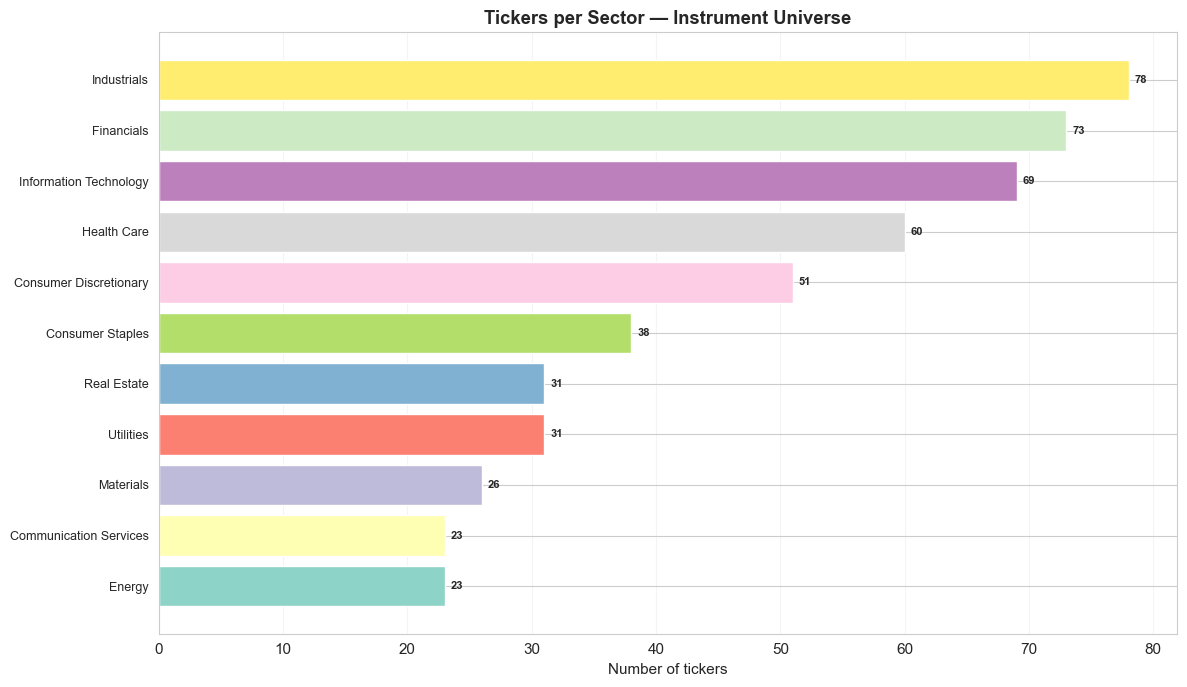

Total: 503 instruments across 11 sectors


In [85]:
# ── Visualise sector coverage ──
fig, ax = plt.subplots(figsize=(12, 7))

sector_counts_sorted = sector_counts.sort_values()
colors_sectors = plt.cm.Set3(np.linspace(0, 1, len(sector_counts_sorted)))
bars = ax.barh(range(len(sector_counts_sorted)), sector_counts_sorted.values,
               color=colors_sectors, edgecolor='white')
ax.set_yticks(range(len(sector_counts_sorted)))
ax.set_yticklabels(sector_counts_sorted.index, fontsize=9)
ax.set_xlabel('Number of tickers')
ax.set_title('Tickers per Sector — Instrument Universe', fontweight='bold')
for i, (_, v) in enumerate(sector_counts_sorted.items()):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=8, fontweight='bold')
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Total: {sector_counts.sum()} instruments across {len(sector_counts)} sectors')

In [ ]:
# Build the analysis universe from real inputs
TARGET_TICKER = 'WMB'
MAX_MODEL_PEERS = 25
MIN_PEER_HISTORY_DAYS = 252
MIN_PEER_COVERAGE = 0.85
N_DAYS = 500
DIST_DEPTH = 0.35

TOP_N = 12

universe = select_peers(
    target_ticker=TARGET_TICKER,
    instruments_df=instruments_df,
    stocks_data_df=stocks_data_df,
    min_peer_history_days=MIN_PEER_HISTORY_DAYS,
    min_peer_coverage=MIN_PEER_COVERAGE,
    max_model_peers=MAX_MODEL_PEERS,
    include_cross_sector=False,
)

target_ticker       = universe['target_ticker']
target_sector       = universe['target_sector']
same_sector_all     = universe['same_sector_all']
same_sector_peers   = universe['same_sector_peers']
cross_sector_peers  = universe['cross_sector_peers']
model_peer_cols     = universe['model_peer_cols']
peers_df            = universe['peers_df']
peer_sector_map     = universe['peer_sector_map']
peer_bucket_map     = universe['peer_bucket_map']
peers_performance_df = universe['performance_df']
prices_wide         = universe['prices_wide']

selected_tickers = [target_ticker] + same_sector_peers
raw = prices_wide[selected_tickers].dropna().copy()

if len(raw) < MIN_PEER_HISTORY_DAYS:
    raise ValueError(f'Not enough common history after broad peer selection: {len(raw)} days')

# Keep a manageable common sample length for the notebook logic
N_DAYS = min(N_DAYS, len(raw))
raw = raw.iloc[-N_DAYS:]
dates = raw.index


In [87]:


# Main price container
prices_df = pd.DataFrame(index=dates)
for t in same_sector_peers + [target_ticker]:
    prices_df[t] = raw[t]
prices_df['TARGET_ORIG'] = raw[target_ticker]

# Use real target_ticker as legacy reference (no synthetic price path)
prices_df['DIST_TRUE'] = prices_df['TARGET_ORIG'].copy()

# Distress event settings
DIST_START = max(40, int(0.60 * N_DAYS))
DIST_END = min(DIST_START + 30, N_DAYS - 5)
RESTRUCTURE_DAY = DIST_END


# Create observed (corrupted) series from actual target_ticker legacy path (distress only)
DIST_OBS = prices_df['DIST_TRUE'].values.copy()

n_d = DIST_END - DIST_START
for i in range(n_d):
    t_norm = i / (n_d - 1) if n_d > 1 else 0.0
    dev = -DIST_DEPTH * np.sin(np.pi * t_norm)
    DIST_OBS[DIST_START + i] = prices_df['DIST_TRUE'].iloc[DIST_START + i] * (1 + dev)

prices_df['DIST_OBS'] = DIST_OBS

# # Backward-compatibility aliases for older cells
# if len(model_peer_cols) >= 3:
#     prices_df['PEER_A'] = prices_df[model_peer_cols[0]]
#     prices_df['PEER_B'] = prices_df[model_peer_cols[1]]
#     prices_df['PEER_C'] = prices_df[model_peer_cols[2]]
# if len(model_peer_cols) >= 5:
#     prices_df['OTHER_X'] = prices_df[model_peer_cols[3]]
#     prices_df['OTHER_Y'] = prices_df[model_peer_cols[4]]

# Keep original mask variable names used throughout the notebook
gap_mask = np.zeros(N_DAYS, dtype=bool)
dist_mask = np.zeros(N_DAYS, dtype=bool)
dist_mask[DIST_START:DIST_END] = True
post_restructure_mask = np.zeros(N_DAYS, dtype=bool)
post_restructure_mask[RESTRUCTURE_DAY:] = True
legacy_clean_mask = (~dist_mask) & (~post_restructure_mask)
clean_mask = legacy_clean_mask.copy()

# Data shape checks
required_cols = model_peer_cols + ['TARGET_ORIG', 'DIST_TRUE', 'DIST_OBS']
missing_cols = [c for c in required_cols if c not in prices_df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in prices_df: {missing_cols}')
if prices_df[required_cols].isna().any().any():
    raise ValueError('prices_df contains NaNs in required columns')
if peers_df[['ticker', 'sector', 'peer_bucket']].isna().any().any():
    raise ValueError('peers_df contains NaNs in required metadata')

# Use top-ranked peers for plotting readability
plot_same_sector_peers = model_peer_cols[:12]
plot_cross_sector_peers = []

print(f'Target ticker: {target_ticker} | sector: {target_sector}')
print(f'Same-sector universe size (all candidates): {len(same_sector_all)}')
print(f'Same-sector candidate basket after quality screen: {len(same_sector_peers)}')
print(f'Model peer subset (best by performance): {len(model_peer_cols)}')
print(f'Sample: {N_DAYS} trading days | starts {dates[0].date()} | ends {dates[-1].date()}')
print(f'Distress window: day {DIST_START}-{DIST_END-1} ({dates[DIST_START].date()} - {dates[DIST_END-1].date()}) -> max dip {DIST_DEPTH*100:.0f}%')
print(f'Restructuring: day {RESTRUCTURE_DAY} ({dates[RESTRUCTURE_DAY].date()})')
print('prices_df uses real TARGET_ORIG as DIST_TRUE reference; DIST_OBS is distress-only corrupted version.')

Target ticker: MSFT | sector: Information Technology
Same-sector universe size (all candidates): 68
Same-sector candidate basket after quality screen: 66
Model peer subset (best by performance): 25
Sample: 500 trading days | starts 2023-10-03 | ends 2025-09-30
Distress window: day 300-329 (2024-12-11 - 2025-01-27) -> max dip 35%
Restructuring: day 330 (2025-01-28)
prices_df uses real TARGET_ORIG as DIST_TRUE reference; DIST_OBS is distress-only corrupted version.


In [88]:
def print_correlations(peers_performance_df, target_ticker='MSFT'):
    """Print the Panel C rank table and correlation summary statistics."""
    print(f'Panel C - Distribution of |Correlation| with {target_ticker} '
          f'(instruments ranked by similarity)')
    print('-' * 90)
    print(f'{"Rank":<5}{"Ticker":<10}{"Sector":<28}{"|Corr|":>10}'
          f'{"Return MAE":>14}{"Coverage":>12}{"Score":>12}')
    print('-' * 90)

    dist_summary = (
        peers_performance_df[['ticker', 'sector', 'abs_corr',
                              'ret_mae', 'coverage', 'peer_score']]
        .sort_values('abs_corr', ascending=False)
        .reset_index(drop=True)
    )

    for rank, row in dist_summary.iterrows():
        print(f"{rank+1:<5}{row['ticker']:<10}{row['sector']:<28}"
              f"{row['abs_corr']:>10.3f}{row['ret_mae']:>14.4f}"
              f"{row['coverage']*100:>11.1f}%{row['peer_score']:>12.3f}")
        if rank >= 19:
            print('   ... (remaining peers omitted for brevity)')
            break

    print('-' * 90)
    print(f'Universe size: {len(dist_summary)} same-sector instruments screened')
    print(f'Strongest proxy: {dist_summary.iloc[0]["ticker"]} '
          f'(|corr|={dist_summary.iloc[0]["abs_corr"]:.3f}, '
          f'sector: {dist_summary.iloc[0]["sector"]})')
    print(f'Weakest proxy : {dist_summary.iloc[-1]["ticker"]} '
          f'(|corr|={dist_summary.iloc[-1]["abs_corr"]:.3f}, '
          f'sector: {dist_summary.iloc[-1]["sector"]})')
    print(f'Mean |corr|   : {dist_summary["abs_corr"].mean():.3f}')
    print(f'Median |corr| : {dist_summary["abs_corr"].median():.3f}')
    print(f'Std |corr|    : {dist_summary["abs_corr"].std():.3f}')
    print()
    print('How to read the histogram:')
    print(f'  - Bars to the RIGHT (closer to 1.0) are the names that move most like {target_ticker}.')
    print(f'  - Bars to the LEFT (closer to 0.0) are the names that move independently of {target_ticker}.')
    print('  - The red dashed line is the MEAN similarity across all candidates.')
    print('  - The orange dashed line is the MEDIAN similarity (robust to outliers).')
    print('  - If the mean and median are close, similarity is symmetric;')
    print('    a long left tail means most names are weak proxies and only a few dominate.')
    print('  - The KDE curve smooths the histogram and helps spot multimodal clusters,')
    print('    e.g. a "core group" of high-similarity names plus a tail of loosely related ones.')


print_correlations(peers_performance_df, target_ticker=target_ticker)

Panel C - Distribution of |Correlation| with MSFT (instruments ranked by similarity)
------------------------------------------------------------------------------------------
Rank Ticker    Sector                          |Corr|    Return MAE    Coverage       Score
------------------------------------------------------------------------------------------
1    NOW       Information Technology           0.572        0.0126      100.0%       0.565
2    CDNS      Information Technology           0.555        0.0125      100.0%       0.548
3    NVDA      Information Technology           0.545        0.0194      100.0%       0.534
4    APH       Information Technology           0.541        0.0112      100.0%       0.535
5    AAPL      Information Technology           0.500        0.0116      100.0%       0.495
6    CRWD      Information Technology           0.498        0.0174      100.0%       0.489
7    ANET      Information Technology           0.488        0.0174      100.0%       0.4

In [89]:
def print_volatility_ratio(peers_performance_df, target_ticker='MSFT'):
    """Print the vol-ratio rank table sorted by vol_score (closeness to 1.0)."""
    print(f'Volatility Ratio Summary — {target_ticker} '
          f'(instruments ranked by vol_score)')
    print('=' * 100)
    print(f'{"Rank":<5}{"Ticker":<10}{"Sector":<28}{"Vol Ratio":>12}'
          f'{"Vol Score":>12}{"Return MAE":>14}{"Coverage":>12}')
    print('=' * 100)

    dist_summary = (
        peers_performance_df[['ticker', 'sector', 'vol_ratio', 'vol_score',
                              'ret_mae', 'coverage']]
        .sort_values('vol_score', ascending=False)
        .reset_index(drop=True)
    )

    for rank, row in dist_summary.iterrows():
        print(f"{rank+1:<5}{row['ticker']:<10}{row['sector']:<28}"
              f"{row['vol_ratio']:>12.3f}{row['vol_score']:>12.3f}"
              f"{row['ret_mae']:>14.4f}{row['coverage']*100:>11.1f}%")
        if rank >= 19:
            print('   ... (remaining peers omitted for brevity)')
            break

    print('=' * 100)
    print(f'Universe size: {len(dist_summary)} same-sector instruments screened')
    print(f'Best vol match: {dist_summary.iloc[0]["ticker"]} '
          f'(vol_ratio={dist_summary.iloc[0]["vol_ratio"]:.3f}, '
          f'vol_score={dist_summary.iloc[0]["vol_score"]:.3f})')
    print(f'Worst vol match: {dist_summary.iloc[-1]["ticker"]} '
          f'(vol_ratio={dist_summary.iloc[-1]["vol_ratio"]:.3f}, '
          f'vol_score={dist_summary.iloc[-1]["vol_score"]:.3f})')
    print(f'Median vol_ratio : {dist_summary["vol_ratio"].median():.3f}')
    print(f'Mean vol_ratio   : {dist_summary["vol_ratio"].mean():.3f}')
    print(f'Std vol_ratio    : {dist_summary["vol_ratio"].std():.3f}')
    print(f'Mean vol_score   : {dist_summary["vol_score"].mean():.3f}')
    print()
    print('How to read this table:')
    print(f'  - Vol Ratio = σ(peer) / σ({target_ticker}) — a ratio of 1.0 means identical volatility.')
    print(f'  - Vol Score = exp(-|ln(vol_ratio)|) — 1.0 is perfect alignment, decays to 0.')
    print(f'  - A peer with vol_ratio=1.0 and high correlation is an ideal proxy.')


print_volatility_ratio(peers_performance_df, target_ticker=target_ticker)

Volatility Ratio Summary — MSFT (instruments ranked by vol_score)
Rank Ticker    Sector                         Vol Ratio   Vol Score    Return MAE    Coverage
1    VRSN      Information Technology             0.990       0.990        0.0122      100.0%
2    TDY       Information Technology             1.010       0.990        0.0113      100.0%
3    CTSH      Information Technology             1.028       0.973        0.0120      100.0%
4    CSCO      Information Technology             0.958       0.958        0.0105      100.0%
5    MSI       Information Technology             0.909       0.909        0.0109      100.0%
6    TYL       Information Technology             1.122       0.891        0.0120      100.0%
7    TEL       Information Technology             1.135       0.881        0.0111      100.0%
8    ACN       Information Technology             1.152       0.868        0.0125      100.0%
9    IBM       Information Technology             1.154       0.866        0.0126      1

## Score Reference — What Do These Numbers Mean?

If this is your first time working with peer scoring, here is an explanation of every metric used to rank candidate peers. The `select_peers()` function computes all of them automatically.

### Score Definitions

| Metric | Symbol | Formula | What It Measures | Ideal Value |
|--------|--------|---------|------------------|-------------|
| **Correlation** | $\rho$ | $\text{corr}(R_{target},\ R_{peer})$ | Directional co-movement of daily returns — do they zig and zag at the same time? | Near $\pm 1.0$ |
| **Volatility Ratio** | $\text{VR}$ | $\sigma_{peer} / \sigma_{target}$ | How much the peer jumps compared to the target. $\text{VR} > 1$ means the peer is more volatile. | **1.0** |
| **Vol Score** | $V_{score}$ | $\exp(-\| \ln(\text{VR}) \|)$ | Penalises peers whose volatility is too high or too low relative to the target. 1.0 is perfect alignment. | **1.0** |
| **Return MAE** | MAE | $\frac{1}{n}\sum\|R_{target} - R_{peer}\|$ | Average absolute return difference — the "mistake size" if you replaced the target's return with the peer's. | **0** |
| **Coverage** | $C$ | fraction of non-NaN days | How much of the history the peer actually exists for. Low coverage means fewer overlapping trading days to learn from. | **1.0** (100%) |
| **Peer Score** | $S_{corr}$ | $\| \rho \| \times C / (1 + \text{MAE})$ | Composite that rewards **high directional alignment × high coverage × low return error**. The most important single-number ranking for return-based regression models. | **Higher is better** |
| **Composite Score** | $S_{comp}$ | $0.5 \cdot \frac{S_{corr}}{\max(S_{corr})} + 0.5 \cdot V_{score}$ (before coint); $0.3 \cdot norm(S_{corr}) + 0.3 \cdot V_{score} + 0.4 \cdot norm(coint)$ (after coint) | Blended ranking of directional alignment, volatility alignment, and cointegration strength. Cointegration score is computed separately via ADF test on price-level spreads. | **1.0** |
| **Cointegration Score** | $C_{score}$ | $-\text{sign}(\beta) \times \text{ADF-statistic}$, where $P_{target} = \alpha + \beta P_{peer} + \epsilon$ | Measures long-run equilibrium between price levels via the Augmented Dickey-Fuller test on OLS residuals. A more negative ADF statistic (flipped to positive) means stronger mean-reversion. | **Higher is better** |

### Why Three Scores?

- **`peer_score`** rewards peers that zig and zag *at the same time* as the target (high correlation) with *small average error* (low MAE) and *good coverage*. This is the most important signal for return-based regression models because the OLS coefficient can absorb volatility scaling differences.

- **`vol_score`** rewards peers whose *jump size* matches the target's. A peer can have $\rho = 0.90$ but $\text{VR} = 2.5$ (twice as volatile) — the regression will shrink the coefficient, but the reconstruction is less stable and more sensitive to outliers.

- **`coint_score`** rewards peers whose *price levels* share a long-run equilibrium with the target. Even if two stocks have moderate return correlation, strong cointegration means their spread is mean-reverting — ideal for error-correction reconstruction.

- **`composite_score`** (updated) blends all three: $0.3 \times norm(peer\_score) + 0.3 \times vol\_score + 0.4 \times coint\_score\_norm$. The cointegration component is weighted highest because it captures information (price-level equilibrium) that return-based metrics miss.

### Quick Interpretation Guide

| Scenario | $\rho$ | VR | $V_{score}$ | Coint | $S_{comp}$ (new) | Verdict | Why |
|----------|--------|----|-------------|-------|-------------------|---------|-----|
| **Perfect proxy** | 0.95 | 1.0 | 1.0 | strong | high | **Excellent** | Moves in lockstep, identical vol, cointegrated levels |
| **High corr, double vol** | 0.90 | 2.0 | 0.69 | moderate | medium | Good for OLS, risky for scaling | Regression shrinks coefficient; cointegration helps stabilise spread |
| **Low corr, matched vol** | 0.30 | 1.1 | 0.91 | weak | low | Not useful independently | Directional signal is too weak even if vol matches |
| **Noisy, wrong vol, no coint** | 0.40 | 3.0 | 0.40 | weak/none | low | **Avoid** | Neither returns nor prices are aligned |
| **Moderate corr, strong coint** | 0.60 | 1.3 | 0.77 | strong | high | **Good for coint proxy** | Price levels mean-revert; ideal for error-correction reconstruction |

The key insight: **correlation captures "when", volatility ratio captures "how much"**. A good proxy needs both, but their relative importance depends on the downstream task.

### What to Look For in the Diagnostics

1. **`print_correlations()`** — ranked by **abs_corr**: find peers that move *when* the target does.

2. **`print_volatility_ratio()`** — ranked by **vol_score**: find peers with matching *jump size*.

3. **Cointegration scoring cell** — ranked by **coint_score**: find peers whose price levels share a long-run equilibrium with the target. A peer with $\rho = 0.60$ and strong cointegration may outperform a peer with $\rho = 0.90$ and no cointegration for the error-correction proxy.

4. **Panel D heatmap** — side-by-side view of correlation, vol_ratio, vol_score, coint_score, return MAE, and coverage for the top 15 peers. Watch for peers with high coint_score **but** low abs_corr — they are useful for the Cointegration Proxy but not for OLS regression.


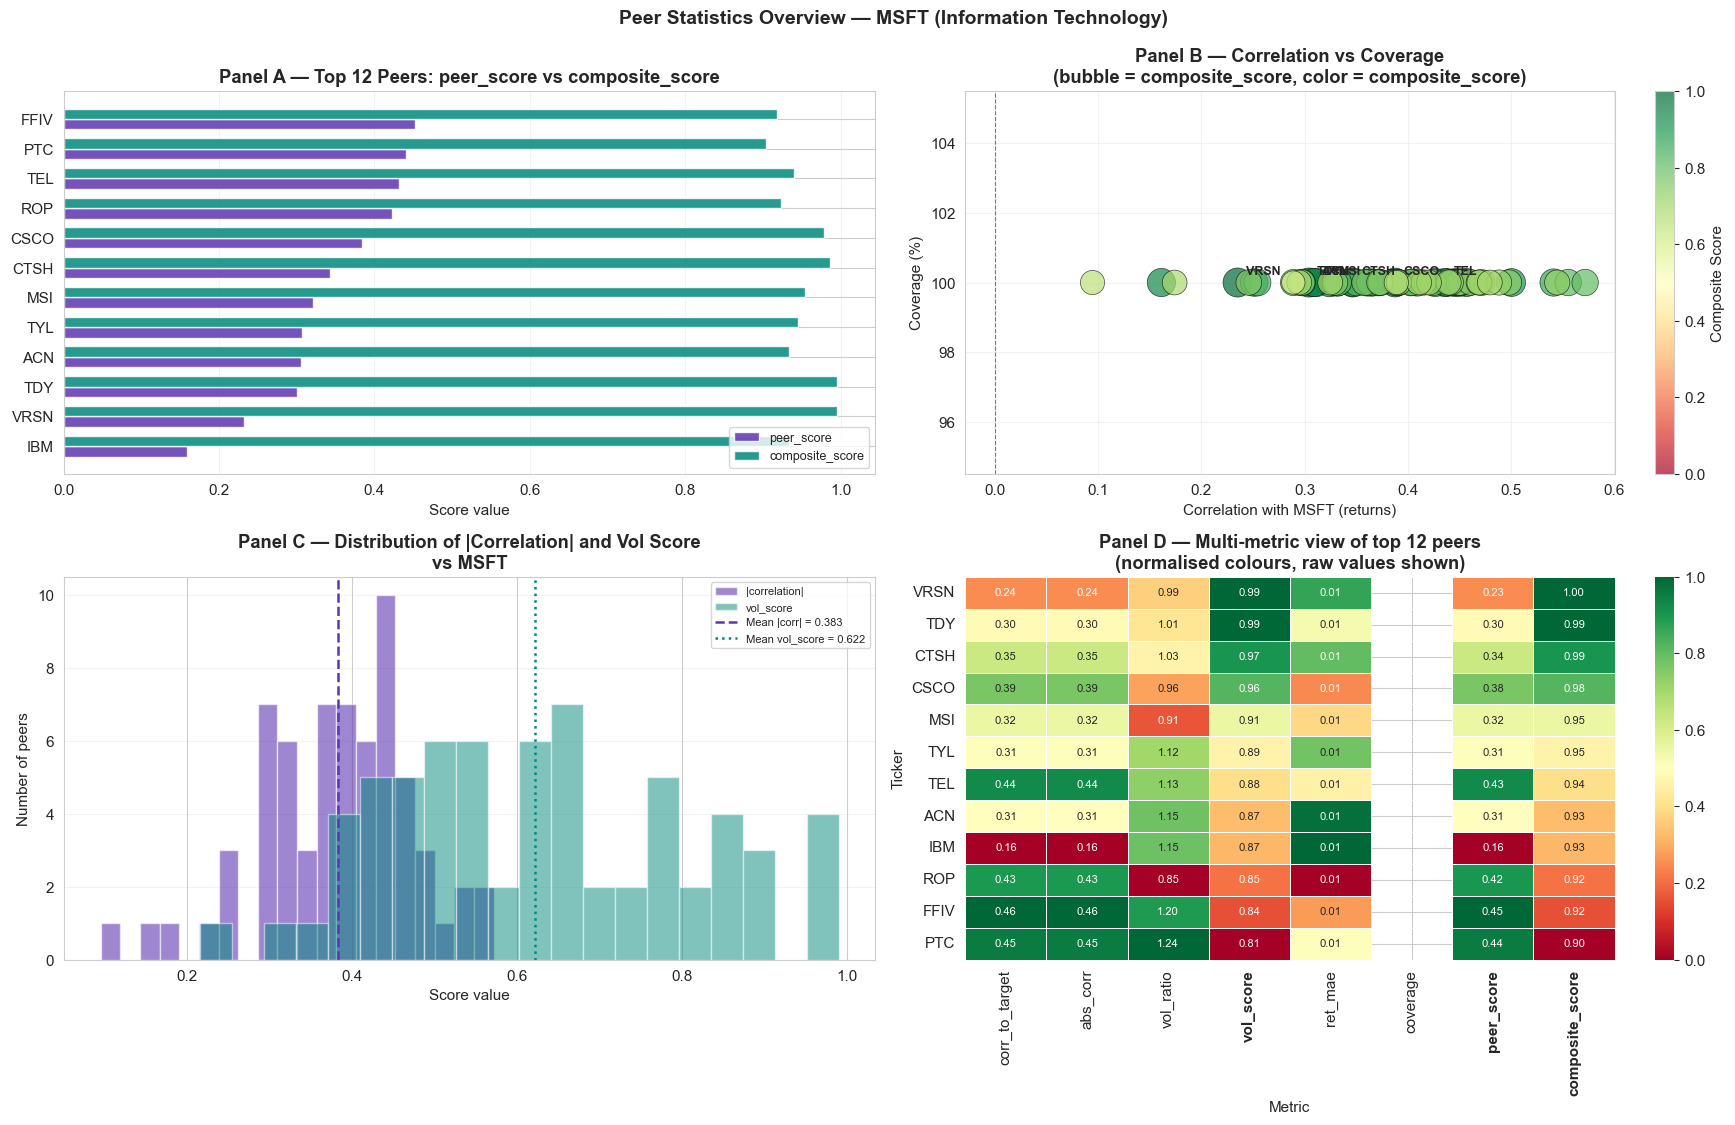

Peer universe summary:
  Total candidates screened : 68
  Peers passing quality gate : 66
  Mean |corr| with MSFT     : 0.383
  Median |corr| with MSFT   : 0.389
  Mean coverage             : 100.000%
  Mean peer score           : 0.377
  Mean composite score      : 0.811
  Median vol_ratio          : 1.647
  Best peer                 : VRSN (score=0.232, corr=0.235)


In [90]:

def plot_peers_summary(peers_performance_df, target_ticker='MSFT', target_sector='',
                       same_sector_all=None, same_sector_peers=None, top_n=15):
    """Render the 2x2 peer-statistics dashboard and print a textual universe summary.

    Metrics shown include correlation, volatility ratio, vol_score, peer_score,
    composite_score, return MAE, and coverage — side-by-side for the top peers.
    """
    perf = peers_performance_df.copy()

    fig, axes = plt.subplots(2, 2, figsize=(18, 11))

    # ── Panel A: top peers — peer_score vs composite_score side-by-side ──
    ax = axes[0, 0]
    top_perf = perf.head(top_n).sort_values('peer_score', ascending=True)
    y_pos = range(len(top_perf))
    bar_height = 0.35
    ax.barh([y - bar_height / 2 for y in y_pos], top_perf['peer_score'],
            bar_height, color='#5E35B1', alpha=0.85, label='peer_score')
    ax.barh([y + bar_height / 2 for y in y_pos], top_perf['composite_score'],
            bar_height, color='#00897B', alpha=0.85, label='composite_score')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(top_perf['ticker'])
    ax.set_title(f'Panel A — Top {top_n} Peers: peer_score vs composite_score',
                 fontweight='bold')
    ax.set_xlabel('Score value')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.25)

    # ── Panel B: correlation vs coverage (color = composite_score) ──
    ax = axes[0, 1]
    scatter = ax.scatter(
        perf['corr_to_target'], perf['coverage'] * 100,
        s=perf['composite_score'] * 400 + 40,
        c=perf['composite_score'], cmap='RdYlGn',
        vmin=0, vmax=1, alpha=0.7, edgecolor='black', linewidth=0.5,
    )
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title('Panel B — Correlation vs Coverage\n(bubble = composite_score, color = composite_score)',
                 fontweight='bold')
    ax.set_xlabel(f'Correlation with {target_ticker} (returns)')
    ax.set_ylabel('Coverage (%)')
    ax.grid(alpha=0.25)
    for _, row in perf.head(8).iterrows():
        ax.annotate(row['ticker'],
                    (row['corr_to_target'], row['coverage'] * 100),
                    fontsize=9, fontweight='bold',
                    xytext=(6, 6), textcoords='offset points')
    plt.colorbar(scatter, ax=ax, label='Composite Score')

    # ── Panel C: distribution of absolute correlations and vol_score ──
    ax = axes[1, 0]
    ax.hist(perf['abs_corr'], bins=20, alpha=0.6, color='#5E35B1', label='|correlation|')
    if 'vol_score' in perf.columns:
        ax.hist(perf['vol_score'], bins=20, alpha=0.5, color='#00897B', label='vol_score')
    ax.axvline(perf['abs_corr'].mean(), color='#5E35B1', ls='--', lw=1.8,
               label=f'Mean |corr| = {perf["abs_corr"].mean():.3f}')
    if 'vol_score' in perf.columns:
        ax.axvline(perf['vol_score'].mean(), color='#00897B', ls=':', lw=1.8,
                   label=f'Mean vol_score = {perf["vol_score"].mean():.3f}')
    ax.set_title(f'Panel C — Distribution of |Correlation| and Vol Score\nvs {target_ticker}',
                 fontweight='bold')
    ax.set_xlabel('Score value')
    ax.set_ylabel('Number of peers')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.25)

    # ── Panel D: multi-metric ranking heatmap for top peers ──
    ax = axes[1, 1]
    heatmap_cols = [c for c in ['corr_to_target', 'abs_corr', 'vol_ratio', 'vol_score',
                                 'ret_mae', 'coverage', 'peer_score', 'composite_score']
                    if c in perf.columns]
    heatmap_metrics = perf.head(top_n).set_index('ticker')[heatmap_cols]
    heatmap_norm = ((heatmap_metrics - heatmap_metrics.min())
                    / (heatmap_metrics.max() - heatmap_metrics.min()))
    sns.heatmap(heatmap_norm, annot=heatmap_metrics.round(2), fmt='.2f',
                cmap='RdYlGn', center=0.5, ax=ax,
                linewidths=0.4, linecolor='white', annot_kws={'size': 8})
    ax.set_title(f'Panel D — Multi-metric view of top {top_n} peers\n'
                 '(normalised colours, raw values shown)', fontweight='bold')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Ticker')
    # Highlight key columns
    for j, col in enumerate(heatmap_cols):
        if col in ('composite_score', 'peer_score', 'vol_score'):
            ax.get_xticklabels()[j].set_weight('bold')

    plt.tight_layout()
    plt.suptitle(f'Peer Statistics Overview — {target_ticker} ({target_sector})',
                 fontweight='bold', fontsize=14, y=1.02)
    plt.show()

    # Quick textual summary
    print('Peer universe summary:')
    if same_sector_all is not None:
        print(f"  Total candidates screened : {len(same_sector_all)}")
    if same_sector_peers is not None:
        print(f"  Peers passing quality gate : {len(same_sector_peers)}")
    print(f"  Mean |corr| with {target_ticker}     : {perf['abs_corr'].mean():.3f}")
    print(f"  Median |corr| with {target_ticker}   : {perf['abs_corr'].median():.3f}")
    print(f"  Mean coverage             : {perf['coverage'].mean():.3%}")
    print(f"  Mean peer score           : {perf['peer_score'].mean():.3f}")
    if 'composite_score' in perf.columns:
        print(f"  Mean composite score      : {perf['composite_score'].mean():.3f}")
    if 'vol_ratio' in perf.columns:
        print(f"  Median vol_ratio          : {perf['vol_ratio'].median():.3f}")
    print(f"  Best peer                 : {perf.iloc[0]['ticker']} "
          f"(score={perf.iloc[0]['peer_score']:.3f}, "
          f"corr={perf.iloc[0]['corr_to_target']:.3f})")


plot_peers_summary(peers_performance_df, target_ticker=target_ticker,
                   target_sector=target_sector,
                   same_sector_all=same_sector_all,
                   same_sector_peers=same_sector_peers,
                   top_n=TOP_N)

## Cointegration — A Signal for Peer Selection

In addition to correlation and volatility alignment, we now introduce
**cointegration** as a peer selection signal.

### What Is Cointegration?

Two price series are cointegrated if they move together in the long run
despite short-term deviations.  Formally, $P_{target}$ and $P_{peer}$ are
cointegrated if there exists a coefficient $\beta$ such that:

$$ \text{spread}_t = P_{target,t} - \beta \times P_{peer,t} $$

is **stationary** (mean-reverting).  Unlike correlation (which measures
directional alignment of *returns*), cointegration measures the
long-run equilibrium relationship between *price levels*.

### The Cointegration Score

For each peer, we compute:

1. Regress $P_{target} = \alpha + \beta \times P_{peer} + \epsilon$
2. Test the residuals $\epsilon_t$ for stationarity using the
   Augmented Dickey-Fuller (ADF) test.
3. $$ \text{coint\_score} = -\text{sign}(\beta) \times \text{ADF-statistic} $$

   A more *negative* ADF statistic means stronger cointegration.
   We flip the sign so that **higher = better**, consistent with the
   other scores.

The `coint_score` is then normalised and blended into the composite
score: $0.3 \times peer\_score + 0.3 \times vol\_score + 0.4 \times coint\_score\_norm$.


In [91]:
# ── Cointegration Scoring: add coint_score to peers_performance_df ──
from statsmodels.tsa.stattools import adfuller

target_px = prices_df['TARGET_ORIG']
coint_scores = {}

for t in peers_performance_df['ticker']:
    if t == target_ticker:
        continue
    peer_px = prices_df[t]
    pair = pd.concat([target_px, peer_px], axis=1).dropna()
    if len(pair) < 60:
        coint_scores[t] = 0.0
        continue
    X = np.column_stack([np.ones(len(pair)), pair.iloc[:, 1].values])
    y = pair.iloc[:, 0].values
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    spread = y - X @ beta
    try:
        adf_stat = adfuller(spread, maxlag=min(12, len(spread)//4 - 2), autolag='AIC')[0]
        coint_score = -adf_stat * np.sign(beta[1])
    except Exception:
        coint_score = 0.0
    coint_scores[t] = float(coint_score)

peers_performance_df['coint_score'] = peers_performance_df['ticker'].map(coint_scores).fillna(0.0)
cs_min, cs_max = peers_performance_df['coint_score'].min(), peers_performance_df['coint_score'].max()
if cs_max > cs_min:
    peers_performance_df['coint_score_norm'] = (
        (peers_performance_df['coint_score'] - cs_min) / (cs_max - cs_min)
    )
else:
    peers_performance_df['coint_score_norm'] = 0.0

# Recompute composite: 0.3 peer_score + 0.3 vol_score + 0.4 coint_score
peers_performance_df['composite_score'] = (
    0.3 * (peers_performance_df['peer_score'] / (peers_performance_df['peer_score'].max() + 1e-10))
    + 0.3 * peers_performance_df['vol_score']
    + 0.4 * peers_performance_df['coint_score_norm']
)

print(f'Cointegration scores computed for {len(coint_scores)} peers')
print(f'  Best cointegrated: {peers_performance_df.loc[peers_performance_df["coint_score"].idxmax(), "ticker"]} '
      f'(score={peers_performance_df["coint_score"].max():.2f})')
print(f'  New composite = 0.3 * peer_score + 0.3 * vol_score + 0.4 * coint_score_norm')
print(f'\n{"Top 8 by Cointegration Score":^60}')
print(f'{"Ticker":<10}{"Coint Score":>12}{"Peer Score":>12}{"New Composite":>14}')
for _, r in peers_performance_df.sort_values('coint_score', ascending=False).head(8).iterrows():
    print(f'{r["ticker"]:<10}{r["coint_score"]:>12.2f}{r["peer_score"]:>12.3f}{r["composite_score"]:>14.3f}')


Cointegration scores computed for 66 peers
  Best cointegrated: TEL (score=3.59)
  New composite = 0.3 * peer_score + 0.3 * vol_score + 0.4 * coint_score_norm

                Top 8 by Cointegration Score                
Ticker     Coint Score  Peer Score New Composite
TEL               3.59       0.431         0.894
CDNS              3.38       0.548         0.862
APH               3.23       0.535         0.882
KLAC              3.16       0.444         0.769
ORCL              3.13       0.435         0.751
JBL               3.08       0.353         0.724
AVGO              3.07       0.461         0.744
HPE               2.91       0.368         0.718


## Score Reference — What Do These Numbers Mean?

If this is your first time working with peer scoring, here is an explanation
of every metric used to rank candidate peers. The `select_peers()` function
computes all of them automatically.

### Score Definitions

| Metric | Symbol | Formula | What it measures | Ideal value |
|--------|--------|---------|-----------------|-------------|
| **Correlation** | $\rho$ | $\text{corr}(R_{target},\ R_{peer})$ | Directional co-movement of daily returns | Near 1.0 (or -1.0) |
| **Volatility Ratio** | $\text{VR}$ | $\sigma_{peer} / \sigma_{target}$ | How much the peer jumps compared to the target | **1.0** |
| **Vol Score** | $V_{score}$ | $\exp(-\| \ln(\text{VR}) \|)$ | Penalises peers whose volatility is too high or too low | **1.0** |
| **Return MAE** | MAE | $\frac{1}{n}\sum\|R_{target} - R_{peer}\|$ | Average absolute return difference — lower is better | 0 |
| **Coverage** | $C$ | fraction of non-NaN days | How much of the history the peer actually exists for | 1.0 (100%) |
| **Peer Score** | $S_{corr}$ | $\| \rho \| \times C / (1 + \text{MAE})$ | Composite that rewards high correlation + high coverage + low MAE | Higher is better |
| **Composite Score** | $S_{comp}$ | $0.5 \cdot \frac{S_{corr}}{\max(S_{corr})} + 0.5 \cdot V_{score}$ (before coint) | Blend of correlation-quality and volatility alignment | **1.0** |
| **Cointegration Score** | $C_{score}$ | $-\text{sign}(\beta) \times \text{ADF-statistic}$ | Long-run price-level equilibrium via ADF test on OLS residuals | Higher is better |

### Why Three Scores?

- **`peer_score`** rewards peers that zig and zag *at the same time* as the target
  (high correlation) with *small average error* (low MAE).
  This is the most important signal for return-based regression models.

- **`vol_score`** rewards peers whose *jump size* matches the target's.
  A peer can have $\rho = 0.90$ but $\text{VR} = 2.5$ (twice as volatile) —
  the regression will shrink the coefficient, but the reconstruction is less stable.

- **`composite_score`** balances both: a peer needs **both** directional alignment
  **and** volatility alignment to rank highly. Use this when you want peers that
  are truly "similar" rather than just correlated.

### Quick Interpretation Guide

| Scenario | $\rho$ | VR | $V_{score}$ | $S_{corr}$ | $S_{comp}$ | Verdict |
|----------|--------|----|-------------|-------------|-------------|---------|
| Perfect proxy | 0.95 | 1.0 | 1.0 | high | high | **Excellent** |
| High corr, double vol | 0.90 | 2.0 | 0.69 | high | medium | Good for regression, risky for scaling |
| Low corr, matched vol | 0.30 | 1.1 | 0.91 | low | medium | Moves independently — not useful |
| Noisy, wrong vol | 0.40 | 3.0 | 0.40 | low | low | **Avoid** |

### What to Look For in the Diagnostics

1. **`print_correlations()`** — ranked by **abs_corr**: find peers that move *when* the target does.
2. **`print_volatility_ratio()`** — ranked by **vol_score**: find peers with matching *jump size*.
3. **Cointegration scoring** — ranked by **coint_score**: find peers with strong price-level equilibrium.
4. **Panel D heatmap** — side-by-side view of correlation, vol_ratio, coint_score, peer_score for top peers.
   Watch for peers with high correlation **but** vol_ratio far from 1.0, or high coint_score
   **but** low abs_corr — they serve different reconstruction methods.


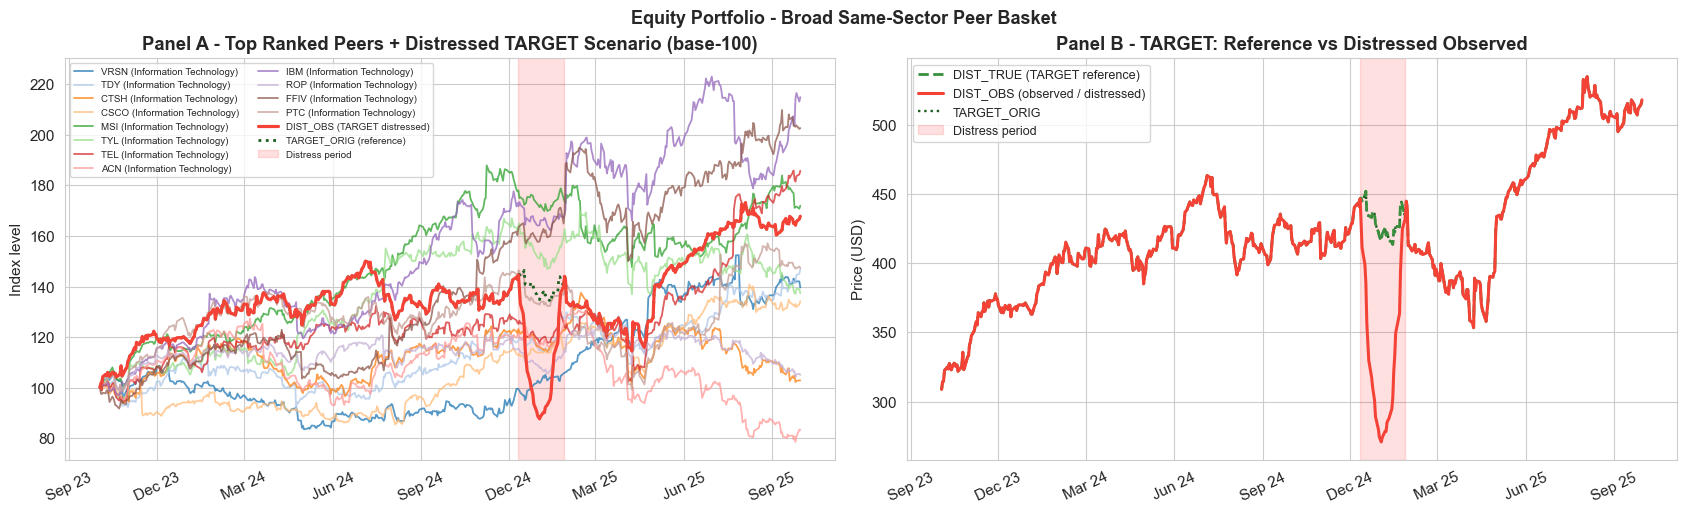

In [92]:
# First look at the portfolio and at observed-vs-reference AAPL path
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Use full peer basket in computation, but top-ranked subset in this chart for readability
plot_peer_cols = plot_same_sector_peers + plot_cross_sector_peers
peer_colors = sns.color_palette('tab20', n_colors=max(len(plot_peer_cols), 1))
peer_palette = {t: peer_colors[i] for i, t in enumerate(plot_peer_cols)}

# Panel A: show top-ranked peers + observed distressed path + original AAPL reference
ax = axes[0]
for t in plot_peer_cols:
    lbl = f"{t} ({peer_sector_map.get(t, 'Unknown')})"
    ax.plot(dates, prices_df[t] / prices_df[t].iloc[0] * 100,
            color=peer_palette[t], alpha=0.75, lw=1.3, label=lbl)
ax.plot(dates, prices_df['DIST_OBS'] / prices_df['DIST_OBS'].iloc[0] * 100,
        color='#F44336', lw=2.3, label='DIST_OBS (TARGET distressed)', zorder=5)
ax.plot(dates, prices_df['TARGET_ORIG'] / prices_df['TARGET_ORIG'].iloc[0] * 100,
        color='#1B5E20', lw=2.0, ls=':', label='TARGET_ORIG (reference)', zorder=4)
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress period')
ax.set_title('Panel A - Top Ranked Peers + Distressed TARGET Scenario (base-100)', fontweight='bold')
ax.set_ylabel('Index level')
ax.legend(fontsize=7, loc='upper left', ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B: compare reference path, distressed observed, and original TARGET
ax = axes[1]
ax.plot(dates, prices_df['DIST_TRUE'], color='#388E3C', lw=2,
        ls='--', label='DIST_TRUE (TARGET reference)', zorder=4)
ax.plot(dates, prices_df['DIST_OBS'], color='#F44336', lw=2.2,
        label='DIST_OBS (observed / distressed)', zorder=5)
ax.plot(dates, prices_df['TARGET_ORIG'], color='#1B5E20', lw=1.7,
        ls=':', label='TARGET_ORIG', zorder=3)
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress period')
ax.set_title('Panel B - TARGET: Reference vs Distressed Observed', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

plt.tight_layout()
plt.suptitle('Equity Portfolio - Broad Same-Sector Peer Basket',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

In [93]:
# Pick performance-selected model peers and target columns for return conversion
peer_cols = model_peer_cols.copy()
price_cols = peer_cols + ['DIST_OBS']
prices_for_ret = prices_df[price_cols].copy()

print(f'Candidate same-sector peers: {len(same_sector_peers)} | Model peers used: {len(peer_cols)}')
print('Model peers (top 15):', peer_cols[:15])

Candidate same-sector peers: 66 | Model peers used: 25
Model peers (top 15): ['VRSN', 'TDY', 'CTSH', 'CSCO', 'MSI', 'TYL', 'TEL', 'ACN', 'IBM', 'ROP', 'FFIV', 'PTC', 'AAPL', 'ADSK', 'CDW']


In [94]:
# Convert prices to daily log returns and rename DIST_OBS to DIST
ret_df = np.log(prices_for_ret / prices_for_ret.shift(1)).dropna()
ret_df = ret_df.rename(columns={'DIST_OBS': 'DIST'})

In this cell, `legacy_clean_mask` means: use only days where DIST still behaves like the original pre-restructuring stock and is not contaminated by distress corruption.

So a day is `True` in `legacy_clean_mask` only if it is:

* not inside the distressed window
* not after the restructuring date
* Why we need it in this cell:

The cell estimates the normal correlation structure of the legacy stock versus peers.
* If you include the distress window, you mix in corrupted prices that no longer reflect the clean legacy process.
* If you include post-restructuring data, you are no longer looking at the same economic/statistical asset.


In [95]:
# Shift the mask because returns start one day after prices
legacy_ret_mask = legacy_clean_mask[1:]
ret_legacy = ret_df.iloc[np.where(legacy_ret_mask)[0]]
corr_clean = ret_legacy.corr()

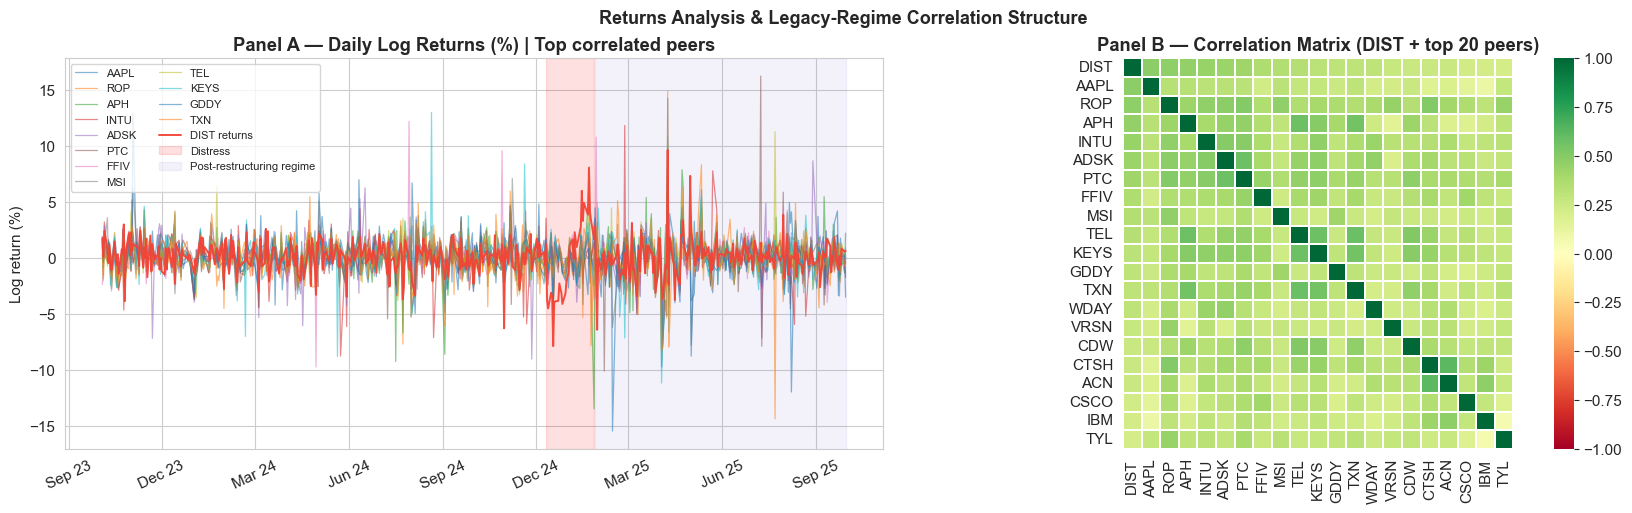

Top correlations with DIST (legacy clean days):
AAPL    0.479916
ROP     0.472074
APH     0.459977
INTU    0.437809
ADSK    0.435545
PTC     0.415363
FFIV    0.361151
MSI     0.344277
TEL     0.337153
KEYS    0.315287
GDDY    0.309490
TXN     0.307609
WDAY    0.306231
VRSN    0.270000
CDW     0.263305
CTSH    0.261800
ACN     0.259290
CSCO    0.228719
IBM     0.224531
TYL     0.213133


In [96]:

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Focus visuals on the strongest peers while keeping full matrix for computation
if 'DIST' not in corr_clean.columns:
    raise ValueError('DIST column missing in corr_clean')

corr_to_dist = corr_clean['DIST'].drop('DIST').sort_values(ascending=False)
plot_peer_cols = corr_to_dist.head(12).index.tolist()
heatmap_cols = ['DIST'] + corr_to_dist.head(20).index.tolist()

# Panel A: show daily returns for top peers and DIST
ax = axes[0]
peer_colors = sns.color_palette('tab10', n_colors=max(len(plot_peer_cols), 1))
for col, c in zip(plot_peer_cols, peer_colors):
    ax.plot(ret_df.index, ret_df[col] * 100, color=c, alpha=0.55, lw=0.9, label=col)
ax.plot(ret_df.index, ret_df['DIST'] * 100,
        color='#F44336', lw=1.4, alpha=0.95, label='DIST returns')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1],
           color='red', alpha=0.12, label='Distress')
ax.axvspan(dates[RESTRUCTURE_DAY], dates[-1],
           color='slateblue', alpha=0.08, label='Post-restructuring regime')
ax.set_title('Panel A — Daily Log Returns (%) | Top correlated peers', fontweight='bold')
ax.set_ylabel('Log return (%)')
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B: show reduced correlation matrix for readability
ax = axes[1]
corr_plot = corr_clean.loc[heatmap_cols, heatmap_cols]
sns.heatmap(corr_plot, annot=False, cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.3, linecolor='white')
ax.set_title('Panel B — Correlation Matrix (DIST + top 20 peers)', fontweight='bold')

plt.tight_layout()
plt.suptitle('Returns Analysis & Legacy-Regime Correlation Structure',
             fontweight='bold', fontsize=13, y=1.02)
plt.show()

print('Top correlations with DIST (legacy clean days):')
print(corr_to_dist.head(20).to_string())

## Reconstruction Methods — Distressed Window Gap-Filling

We now apply several approaches to reconstruct the legacy price series during the
distressed window. Each method returns a full-length price series with the distress
period filled in, **without side effects** on the original data.

### Methods Overview

| Tier | Method | Approach | Complexity |
|------|--------|----------|------------|
| **Simple** | Forward / Backward Fill & Linear Interpolation | Uses only the target's own pre/post distress anchors | ⭐ |
| **Static Proxy** | Snapshot peer selection before distress, then regress | Selects peers once from clean pre-distress data, fits OLS, applies during distress | ⭐⭐ |
| **Dynamic Proxy** | Rolling peer selection each day of distress | Re-selects peers daily using a rolling lookback window | ⭐⭐⭐ |
| **ML / Clustering** | Hierarchical clustering + OLS on peer group | Clusters peers by distance, uses same-cluster peers as regressors | ⭐⭐⭐⭐ |

### Common Settings

All methods share these parameters (set once here):


In [97]:
# ── Shared configuration for all reconstruction methods ──
recon = {}                                    # Container: method_name -> reconstructed Series
LOOKBACK = 80                                  # Lookback window (trading days) for rolling estimators
CLUSTER_THR = 0.35                             # Dendrogram cut threshold for cluster identification
MAX_PEERS = 5                                  # Max peers used in OLS regression
MIN_PEERS = 2                                  # Min peers required before fallback to global ranking
ALPHA = 1.0                                   # Regularisation strength for Ridge regression

from sklearn.linear_model import Ridge


def get_regressor(model_type: str = 'ols', alpha: float = 1.0):
    """Return a regressor instance by type name.

    Parameters
    ----------
    model_type : str
        One of ``'ols'`` (LinearRegression), ``'ridge'`` (Ridge with L2 penalty).
    alpha : float
        Regularisation strength (only used for ridge).

    Returns
    -------
    estimator
        A scikit-learn regressor with a .fit() / .predict() / .score() API.
    """
    model_type = model_type.lower()
    if model_type == 'ols':
        return LinearRegression()
    elif model_type == 'ridge':
        return Ridge(alpha=alpha, random_state=42)
    else:
        raise ValueError(f"Unknown model_type '{model_type}'. Use 'ols' or 'ridge'.")


# Compute daily log returns for all peers + DIST_OBS (used by proxy methods)
prices_for_ret = prices_df[model_peer_cols + ['DIST_OBS']].copy()
ret_df = np.log(prices_for_ret / prices_for_ret.shift(1)).dropna()
ret_df = ret_df.rename(columns={'DIST_OBS': 'DIST'})
print(f'Return dataframe: {ret_df.shape[0]} days × {ret_df.shape[1]} assets')
print(f'Distress window: day {DIST_START}–{DIST_END-1}  |  '
      f'Lookback: {LOOKBACK} days  |  Max peers: {MAX_PEERS}')
print(f'Regressors available: ols (LinearRegression), ridge(α={ALPHA})')

Return dataframe: 499 days × 26 assets
Distress window: day 300–329  |  Lookback: 80 days  |  Max peers: 5
Regressors available: ols (LinearRegression), ridge(α=1.0)


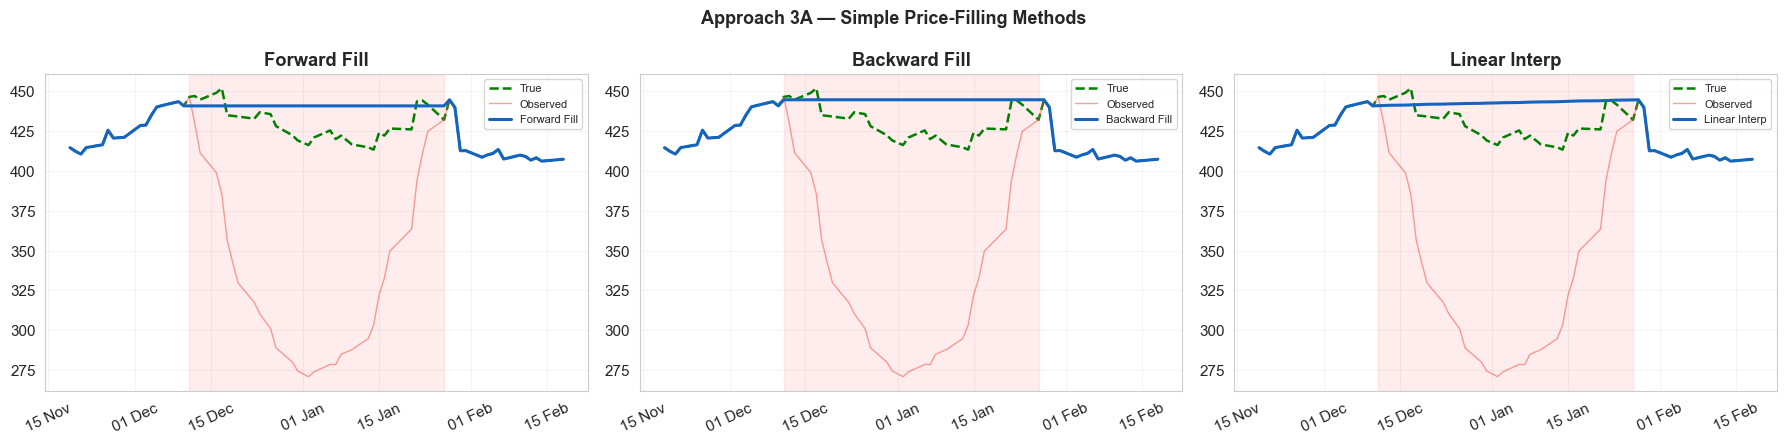

Simple methods applied. Results stored in `recon` dict.
  ✓ Forward Fill
  ✓ Backward Fill
  ✓ Linear Interp


In [98]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Approach 3A – Simple Price-Filling Methods                 ║
# ║  Forward Fill · Backward Fill · Linear Interpolation        ║
# ╚══════════════════════════════════════════════════════════════╝
#
# These are the most basic gap-filling techniques. They ignore peers
# entirely and use only the target's own price history.
#
#   • Forward Fill  – keep the last clean price flat through the gap
#   • Backward Fill – use the first post-distress price backwards
#   • Linear Interp – connect pre/post anchors with a straight line


def simple_fill_reconstruction(
    prices: pd.Series,
    gap_start: int,
    gap_end: int,
) -> dict[str, pd.Series]:
    """Apply forward-fill, backward-fill and linear interpolation to a price gap.

    Parameters
    ----------
    prices : pd.Series
        Full price series with the gap period containing corrupted values.
    gap_start, gap_end : int
        Indices defining the gap window (Python slice convention).

    Returns
    -------
    dict[str, pd.Series]
        Three reconstructed series keyed by method name.
    """
    anchor_pre  = prices.iloc[gap_start - 1]
    anchor_post = prices.iloc[gap_end]

    ffill = prices.copy()
    ffill.iloc[gap_start:gap_end] = anchor_pre

    bfill = prices.copy()
    bfill.iloc[gap_start:gap_end] = anchor_post

    linear = prices.copy()
    linear.iloc[gap_start:gap_end] = np.nan
    linear = linear.interpolate(method='linear')

    return {'Forward Fill': ffill, 'Backward Fill': bfill, 'Linear Interp': linear}


# ── Apply and visualise ──
simple_methods = simple_fill_reconstruction(prices_df['DIST_OBS'], DIST_START, DIST_END)
recon.update(simple_methods)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
zoom = slice(max(0, DIST_START - 15), min(len(dates), DIST_END + 15))

for ax, (name, series) in zip(axes, simple_methods.items()):
    ax.plot(dates[zoom], prices_df['DIST_TRUE'].iloc[zoom], 'g--', lw=1.8, label='True')
    ax.plot(dates[zoom], prices_df['DIST_OBS'].iloc[zoom], color='#F44336', lw=1, alpha=0.5, label='Observed')
    ax.plot(dates[zoom], series.iloc[zoom], color='#1565C0', lw=2.2, label=name)
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
    ax.grid(alpha=0.2)

plt.suptitle('Approach 3A — Simple Price-Filling Methods', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Simple methods applied. Results stored in `recon` dict.')
for name in simple_methods:
    print(f'  ✓ {name}')

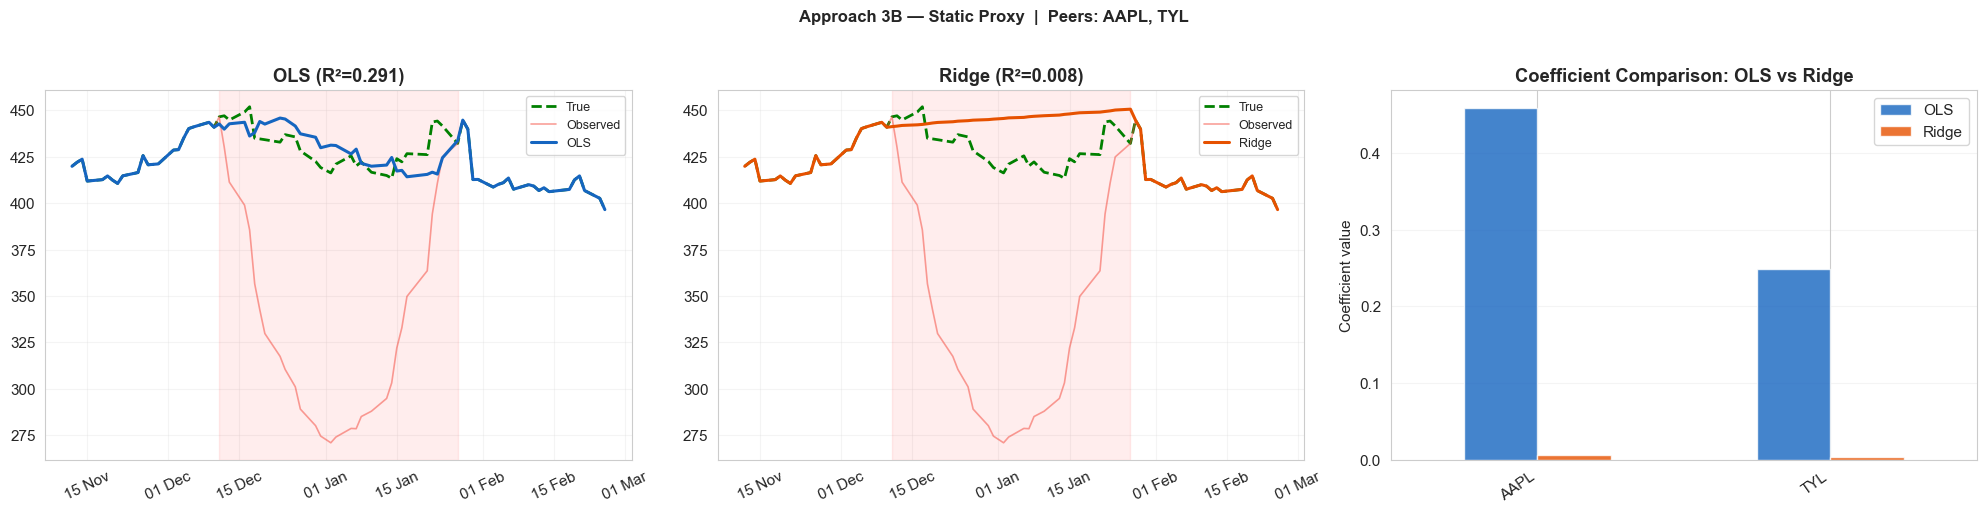

Static Proxy+OLS stored in `recon["Static Proxy+OLS"]`.
  R²=0.2908  |  Peers: AAPL, TYL
Static Proxy+Ridge stored in `recon["Static Proxy+Ridge"]`.
  R²=0.0077  |  α=1.0
  Mean coefficient shrinkage (Ridge/OLS): 0.014


In [99]:

# ╔══════════════════════════════════════════════════════════════╗
# ║  Approach 3B – Static Proxy + OLS Regression                ║
# ║  Select peers ONCE before distress, fit OLS, reconstruct    ║
# ╚══════════════════════════════════════════════════════════════╝
#
# How it works:
#   1. Take a snapshot of the clean return window BEFORE distress starts.
#   2. Compute correlation matrix + volatility distances among all peers.
#   3. Cluster peers hierarchically; pick same-cluster peers as candidates.
#   4. Score each candidate using a weighted blend of:
#      - corr_with_DIST  (directional alignment)
#      - vol_similarity   (volatility ratio closeness → vol_score)
#      - tracking_error   (return tracking similarity)
#      - downside_similarity (co-movement in negative-return days)
#   5. Fit an OLS regression: DIST_returns ~ peer_returns on the clean window.
#   6. Apply the fitted coefficients to the peer returns DURING the distress window.
#
# Why "static"? The peer set and regression coefficients are fixed once before
# the distress window.  This is fast but assumes the peer relationship is stable.


def build_peer_distance(ret_window: pd.DataFrame, target_col: str = 'DIST'):
    """Compute multi-dimensional distance matrix between all assets in ret_window.

    Returns
    -------
    dist_mat : pd.DataFrame  — weighted distance (lower = more similar)
    peer_score : pd.Series   — composite score (higher = better proxy)
    diagnostics : pd.DataFrame — per-peer breakdown of similarity components
    peers : list[str]        — selected peer tickers
    selection_rule : str     — human-readable description of how peers were chosen
    """
    corr_mat = ret_window.corr()
    stocks = corr_mat.columns.tolist()

    # --- correlation distance ---
    corr_dist = ((1 - corr_mat) / 2).clip(lower=0, upper=1)
    np.fill_diagonal(corr_dist.values, 0.0)

    # --- volatility distance ---
    vol_series = ret_window.std()
    vol_diff = pd.DataFrame(0.0, index=stocks, columns=stocks)
    for si in stocks:
        for sj in stocks:
            vol_diff.loc[si, sj] = abs(vol_series[si] - vol_series[sj])
    max_v = vol_diff.to_numpy().max()
    if max_v > 0:
        vol_diff /= max_v

    # --- tracking error distance ---
    tracking_dist = pd.DataFrame(0.0, index=stocks, columns=stocks)
    for si in stocks:
        for sj in stocks:
            tracking_dist.loc[si, sj] = (ret_window[si] - ret_window[sj]).std()
    max_t = tracking_dist.to_numpy().max()
    if max_t > 0:
        tracking_dist /= max_t

    # --- downside similarity ---
    down_mask = ret_window[target_col] < 0
    down_sim = pd.Series(0.0, index=stocks, dtype=float)
    target_down = ret_window.loc[down_mask, target_col]
    for s in stocks:
        if s == target_col:
            down_sim[s] = 1.0
            continue
        pair = pd.concat([target_down, ret_window.loc[down_mask, s]], axis=1).dropna()
        if len(pair) >= 5:
            c = pair.iloc[:, 0].corr(pair.iloc[:, 1])
            down_sim[s] = np.clip((c + 1) / 2, 0, 1) if pd.notna(c) else 0.0

    down_dist = pd.DataFrame(1.0, index=stocks, columns=stocks)
    for si in stocks:
        for sj in stocks:
            down_dist.loc[si, sj] = abs(down_sim[si] - down_sim[sj])

    # --- weighted distance ---
    dist_mat = (0.40 * corr_dist + 0.20 * vol_diff +
                0.15 * tracking_dist + 0.25 * down_dist).clip(0, 1)
    np.fill_diagonal(dist_mat.values, 0.0)

    # --- peer scoring ---
    raw_corr = corr_mat.loc[target_col].drop(target_col)
    vol_sim = 1.0 - vol_diff.loc[target_col].drop(target_col)
    track_sim = 1.0 - tracking_dist.loc[target_col].drop(target_col)
    down_comp = down_sim.drop(target_col)

    same_sector_set = set(peers_df[peers_df['peer_bucket'] == 'same_sector']['ticker'])
    sector_adj = pd.Series({s: 0.05 if s in same_sector_set else -0.05 for s in raw_corr.index}, dtype=float)

    peer_score = (0.35 * raw_corr.clip(0) + 0.20 * vol_sim +
                  0.20 * track_sim + 0.25 * down_comp)
    peer_score = peer_score.sort_values(ascending=False)

    # --- clustering + peer selection ---
    linkage_mat = linkage(squareform(dist_mat.values), method='ward')
    labels = fcluster(linkage_mat, t=CLUSTER_THR, criterion='distance')
    dist_cluster = labels[stocks.index(target_col)]
    same_cluster = [s for s, cid in zip(stocks, labels)
                    if cid == dist_cluster and s != target_col
                    and s in peer_score.index]

    if len(same_cluster) >= MIN_PEERS:
        peers = sorted(same_cluster, key=lambda s: peer_score[s], reverse=True)[:MAX_PEERS]
        rule = 'cluster-first'
    else:
        peers = peer_score.index[:MAX_PEERS].tolist()
        rule = 'fallback global score'

    # --- diagnostics ---
    diag = pd.DataFrame(index=peer_score.index)
    diag['corr_with_DIST'] = raw_corr
    diag['vol_similarity'] = vol_sim
    diag['tracking_similarity'] = track_sim
    diag['downside_similarity'] = down_comp
    diag['same_sector'] = [s in peers_df[peers_df['peer_bucket'] == 'same_sector']['ticker'].values
                           for s in diag.index]
    diag['peer_score'] = peer_score
    diag = diag.sort_values('peer_score', ascending=False)

    return dist_mat, peer_score, diag, peers, rule


def static_proxy_reconstruction(
    ret_window: pd.DataFrame,
    ret_full: pd.DataFrame,
    prices_obs: pd.Series,
    gap_start: int,
    gap_end: int,
    model_type: str = 'ols',
    alpha: float = 1.0,
) -> tuple[pd.Series, dict]:
    """Reconstruct the distress gap using a single static peer set + regression.

    Parameters
    ----------
    ret_window : pd.DataFrame  — clean pre-distress return window (for fitting)
    ret_full   : pd.DataFrame  — full return panel (for prediction during gap)
    prices_obs : pd.Series     — observed price series with corrupted gap
    gap_start, gap_end : int   — gap indices
    model_type : str            — ``'ols'`` or ``'ridge'``
    alpha : float               — regularisation strength (ridge only)

    Returns
    -------
    reconstructed : pd.Series  — full-length price series with gap filled
    info : dict               — metadata (selected peers, R², coefficients, model_type)
    """
    _, peer_score, diag, peers, rule = build_peer_distance(ret_window)

    peer_cols = [c for c in peers if c in ret_window.columns]
    if not peer_cols:
        raise ValueError('No qualifying peers found for static proxy.')

    X = ret_window[peer_cols].values
    y = ret_window['DIST'].values
    model = get_regressor(model_type, alpha).fit(X, y)

    gap_ret = ret_full[peer_cols].iloc[gap_start:gap_end].values
    pred_log_ret = model.predict(gap_ret)

    reconstructed = prices_obs.copy()
    for i in range(gap_end - gap_start):
        reconstructed.iloc[gap_start + i] = (
            reconstructed.iloc[gap_start + i - 1] * np.exp(pred_log_ret[i])
        )

    info = {
        'peers': peer_cols,
        'coefs': dict(zip(peer_cols, model.coef_)),
        'intercept': model.intercept_,
        'r2': model.score(X, y),
        'rule': rule,
        'model_type': model_type,
        'top_diagnostics': diag.head(5),
    }
    return reconstructed, info


# ── Apply with BOTH OLS and Ridge ──
window_start = max(0, DIST_START - 1 - LOOKBACK)
window_end = DIST_START - 1
static_window = ret_df.iloc[window_start:window_end].copy()

static_series_ols, static_info_ols = static_proxy_reconstruction(
    static_window, ret_df, prices_df['DIST_OBS'], DIST_START, DIST_END, model_type='ols')
static_series_ridge, static_info_ridge = static_proxy_reconstruction(
    static_window, ret_df, prices_df['DIST_OBS'], DIST_START, DIST_END, model_type='ridge', alpha=ALPHA)

recon['Static Proxy+OLS'] = static_series_ols
recon['Static Proxy+Ridge'] = static_series_ridge

# ── Visualise ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
zoom_slice = slice(max(0, DIST_START - 20), min(len(dates), DIST_END + 20))

for ax, (series, info, label, color) in zip(axes[:2], [
    (static_series_ols, static_info_ols, 'OLS', '#1565C0'),
    (static_series_ridge, static_info_ridge, 'Ridge', '#E65100'),
]):
    ax.plot(dates[zoom_slice], prices_df['DIST_TRUE'].iloc[zoom_slice], 'g--', lw=2, label='True')
    ax.plot(dates[zoom_slice], prices_df['DIST_OBS'].iloc[zoom_slice], '#F44336', lw=1.2, alpha=0.5, label='Observed')
    ax.plot(dates[zoom_slice], series.iloc[zoom_slice], color, lw=2.2, label=label)
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
    ax.set_title(f'{label} (R²={info["r2"]:.3f})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
    ax.grid(alpha=0.2)

# Panel 3: coefficient comparison
ax = axes[2]
coef_df = pd.DataFrame({
    'OLS': static_info_ols['coefs'],
    'Ridge': static_info_ridge['coefs'],
})
coef_df.plot(kind='bar', ax=ax, color=['#1565C0', '#E65100'], alpha=0.8)
ax.set_title('Coefficient Comparison: OLS vs Ridge', fontweight='bold')
ax.set_ylabel('Coefficient value')
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.grid(axis='y', alpha=0.2)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')

plt.suptitle(f'Approach 3B — Static Proxy  |  '
             f'Peers: {", ".join(static_info_ols["peers"][:5])}',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Static Proxy+OLS stored in `recon["Static Proxy+OLS"]`.')
print(f'  R²={static_info_ols["r2"]:.4f}  |  Peers: {", ".join(static_info_ols["peers"])}')
print(f'Static Proxy+Ridge stored in `recon["Static Proxy+Ridge"]`.')
print(f'  R²={static_info_ridge["r2"]:.4f}  |  α={ALPHA}')
# Show shrinkage effect
coef_ols = np.array(list(static_info_ols['coefs'].values()))
coef_ridge = np.array(list(static_info_ridge['coefs'].values()))
shrinkage = np.mean(abs(coef_ridge) / (abs(coef_ols) + 1e-10))
print(f'  Mean coefficient shrinkage (Ridge/OLS): {shrinkage:.3f}')


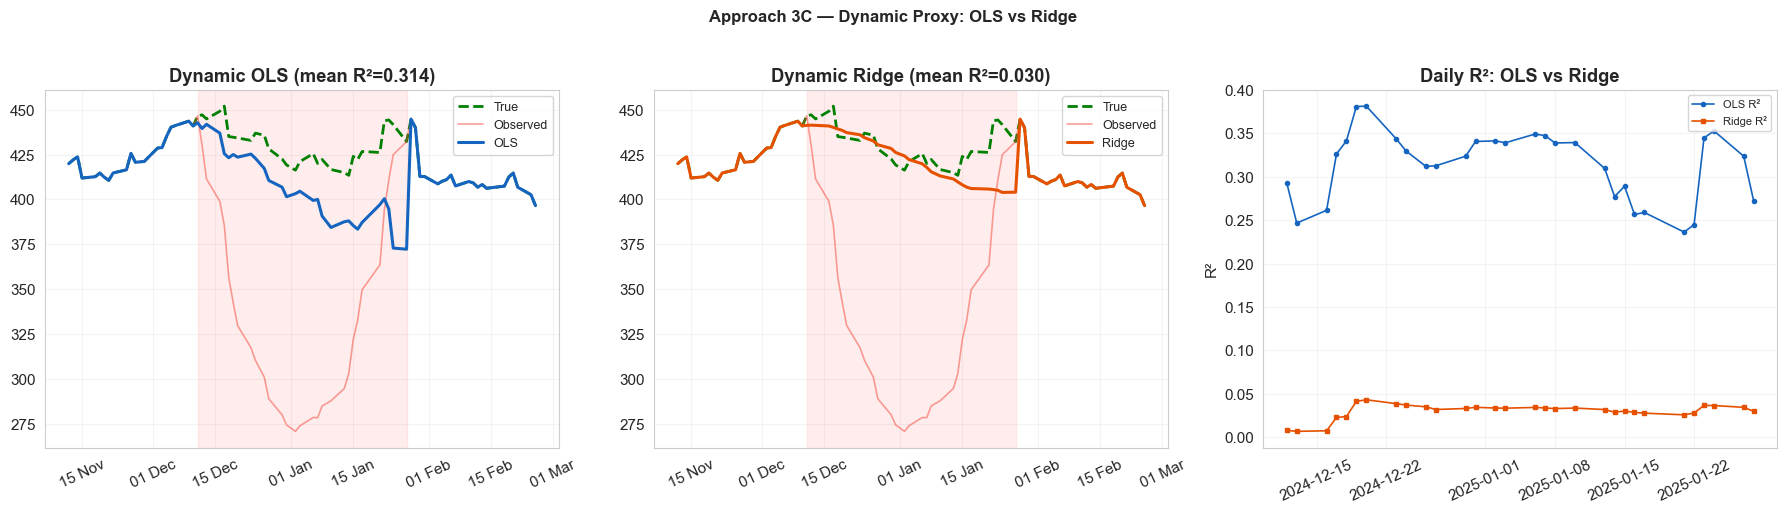

Dynamic OLS: mean R²=0.3139
Dynamic Ridge: mean R²=0.0300


In [100]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Approach 3C – Dynamic Proxy (Rolling Peer Selection + OLS) ║
# ║  Re-select peers EVERY day during the distress window       ║
# ╚══════════════════════════════════════════════════════════════╝
#
# How it works:
#   1. For EACH day of the distress window, take the preceding LOOKBACK days
#      as the training window (rolling window).
#   2. Compute correlation + volatility + tracking + downside distances
#      on that rolling window (same build_peer_distance logic).
#   3. Select peers from the same cluster as DIST.
#   4. Fit OLS: DIST_returns ~ peer_returns on the rolling window.
#   5. Predict the NEXT day's return → convert to price.
#   6. Move to the next distress day and repeat.
#
# Why "dynamic"? The peer set and regression coefficients can CHANGE every
# day, adapting to evolving market conditions. This is more flexible than
# the static approach but slower and noisier.


def dynamic_proxy_reconstruction(
    ret_full: pd.DataFrame,
    prices_obs: pd.Series,
    gap_start: int,
    gap_end: int,
    lookback: int = 80,
    model_type: str = 'ols',
    alpha: float = 1.0,
) -> tuple[pd.Series, pd.DataFrame]:
    """Reconstruct the distress gap with rolling peer selection + regression.

    Parameters
    ----------
    ret_full   : pd.DataFrame — full return panel (DIST + peers)
    prices_obs : pd.Series    — observed price series with corrupted gap
    gap_start, gap_end : int  — gap indices
    lookback   : int          — rolling window size in trading days
    model_type : str           — ``'ols'`` or ``'ridge'``
    alpha : float              — regularisation strength (ridge only)

    Returns
    -------
    reconstructed : pd.Series  — full-length price series with gap filled
    daily_log     : pd.DataFrame — daily diagnostics
    """
    reconstructed = prices_obs.copy()
    daily_rows = []

    for day in range(gap_start, gap_end):
        win_start = max(0, day - lookback)
        window = ret_full.iloc[win_start:day].copy()

        if len(window) < 30:
            reconstructed.iloc[day] = reconstructed.iloc[day - 1]
            continue

        _, peer_score, _, peers, _ = build_peer_distance(window)
        peer_cols = [c for c in peers[:MAX_PEERS] if c in window.columns]

        if len(peer_cols) < MIN_PEERS:
            reconstructed.iloc[day] = reconstructed.iloc[day - 1]
            continue

        X = window[peer_cols].values
        y = window['DIST'].values
        model = get_regressor(model_type, alpha).fit(X, y)

        x_pred = ret_full[peer_cols].iloc[day:day + 1].values
        pred_ret = model.predict(x_pred)[0]
        reconstructed.iloc[day] = reconstructed.iloc[day - 1] * np.exp(pred_ret)

        daily_rows.append({
            'date': ret_full.index[day],
            'peers': ', '.join(peer_cols[:3]),
            'n_peers': len(peer_cols),
            'r2': model.score(X, y),
            'pred_log_ret': pred_ret,
        })

    daily_log = pd.DataFrame(daily_rows) if daily_rows else pd.DataFrame()
    return reconstructed, daily_log


# ── Apply with BOTH OLS and Ridge ──
dynamic_ols, dynamic_ols_log = dynamic_proxy_reconstruction(
    ret_df, prices_df['DIST_OBS'], DIST_START, DIST_END, LOOKBACK, model_type='ols')
dynamic_ridge, dynamic_ridge_log = dynamic_proxy_reconstruction(
    ret_df, prices_df['DIST_OBS'], DIST_START, DIST_END, LOOKBACK, model_type='ridge', alpha=ALPHA)

recon['Dynamic Proxy+OLS'] = dynamic_ols
recon['Dynamic Proxy+Ridge'] = dynamic_ridge

# ── Visualise ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
zoom_slice = slice(max(0, DIST_START - 20), min(len(dates), DIST_END + 20))

for ax, (series, log, label, color) in zip(axes, [
    (dynamic_ols, dynamic_ols_log, 'OLS', '#1565C0'),
    (dynamic_ridge, dynamic_ridge_log, 'Ridge', '#E65100'),
]):
    ax.plot(dates[zoom_slice], prices_df['DIST_TRUE'].iloc[zoom_slice], 'g--', lw=2, label='True')
    ax.plot(dates[zoom_slice], prices_df['DIST_OBS'].iloc[zoom_slice], '#F44336', lw=1.2, alpha=0.5, label='Observed')
    ax.plot(dates[zoom_slice], series.iloc[zoom_slice], color, lw=2.2, label=label)
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
    mean_r2 = log['r2'].mean() if not log.empty else 0
    ax.set_title(f'Dynamic {label} (mean R²={mean_r2:.3f})', fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
    ax.grid(alpha=0.2)

# Panel 3: daily R² comparison
ax = axes[2]
if not dynamic_ols_log.empty and not dynamic_ridge_log.empty:
    ax.plot(dynamic_ols_log['date'], dynamic_ols_log['r2'], 'o-', color='#1565C0', lw=1.2, ms=3, label='OLS R²')
    ax.plot(dynamic_ridge_log['date'], dynamic_ridge_log['r2'], 's-', color='#E65100', lw=1.2, ms=3, label='Ridge R²')
    ax.set_title('Daily R²: OLS vs Ridge', fontweight='bold')
    ax.set_ylabel('R²')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

plt.suptitle('Approach 3C — Dynamic Proxy: OLS vs Ridge', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Dynamic OLS: mean R²={dynamic_ols_log["r2"].mean():.4f}' if not dynamic_ols_log.empty else '')
print(f'Dynamic Ridge: mean R²={dynamic_ridge_log["r2"].mean():.4f}' if not dynamic_ridge_log.empty else '')

  PCA: 4 components explain ~90% variance
  PCA: 4 components explain ~90% variance


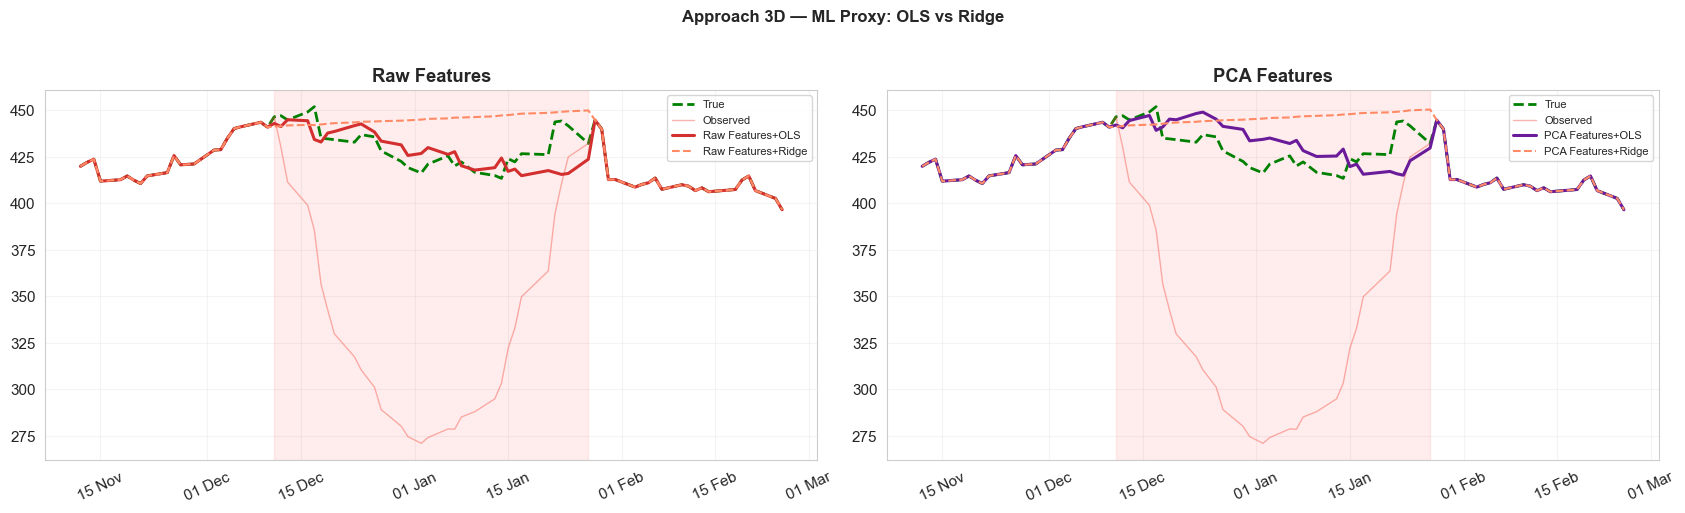

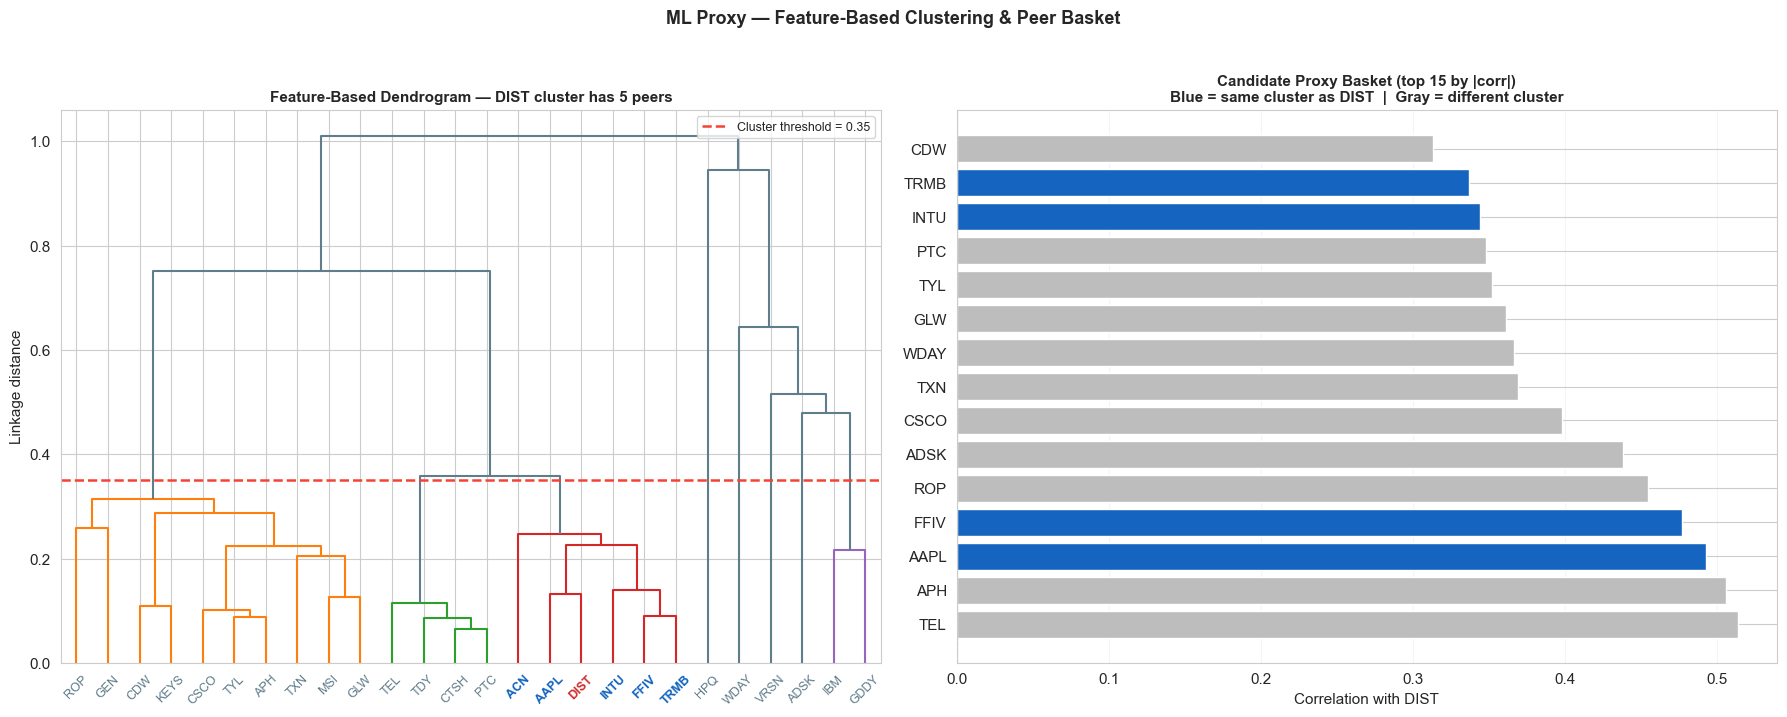

DIST cluster size: 5 peers out of 25 candidates
Same-cluster peers: ACN, FFIV, AAPL, INTU, TRMB
Selected for regression (top 5): see individual model info above
All 4 ML variants stored in `recon` dict.


In [101]:

# ╔══════════════════════════════════════════════════════════════╗
# ║  Approach 3D – ML Proxy: Feature-Based Selection + Clustering║
# ║  Use engineered return features + PCA for peer ranking      ║
# ╚══════════════════════════════════════════════════════════════╝
#
# How it works:
#   1. On the pre-distress clean window, compute a richer feature set
#      for each asset: multi-day returns, rolling volatility, drawdown,
#      downside semi-volatility, and rolling spread.
#   2. Standardise features and optionally apply PCA for dimensionality
#      reduction.
#   3. Compute pairwise feature distance, cluster hierarchically, and
#      select same-cluster peers.
#   4. Fit OLS: DIST_returns ~ peer_returns on the clean window.
#   5. Apply coefficients during the distress window.
#
# This is the most sophisticated approach: it captures similarity across
# MANY dimensions, not just contemporaneous return correlation.


def feature_distance_matrix(ret_window: pd.DataFrame, use_pca: bool = False,
                            pca_var: float = 0.90) -> pd.DataFrame:
    """Compute a pairwise distance matrix from engineered return features.

    Parameters
    ----------
    ret_window : pd.DataFrame — return panel (assets as columns)
    use_pca    : bool         — apply PCA before distance computation
    pca_var    : float        — explained variance threshold for PCA

    Returns
    -------
    dist_mat : pd.DataFrame  — feature-based distance (lower = more similar)
    """
    assets = ret_window.columns.tolist()
    features = {}

    for col in assets:
        r = ret_window[col].values
        f = {
            'ret_1d': r[-1],
            'ret_3d': np.sum(r[-3:]),
            'ret_5d': np.sum(r[-5:]),
            'ret_10d': np.sum(r[-10:]),
            'vol_5d': np.std(r[-5:]),
            'vol_10d': np.std(r[-10:]),
            'drawdown_5d': np.min(r[-5:]),
            'drawdown_10d': np.min(r[-10:]),
            'downside_semivol_5d': np.std(r[-5:][r[-5:] < 0]) if np.any(r[-5:] < 0) else 0.0,
            'spread_mean_5d': np.mean(np.abs(np.diff(r[-5:]))),
        }
        features[col] = list(f.values())

    feature_names = list(f.keys())
    feat_df = pd.DataFrame.from_dict(features, orient='index', columns=feature_names)
    feat_df = feat_df.fillna(0)

    scaler = StandardScaler()
    feat_scaled = scaler.fit_transform(feat_df)

    if use_pca:
        pca = PCA(n_components=pca_var)
        feat_scaled = pca.fit_transform(feat_scaled)
        print(f'  PCA: {pca.n_components_} components explain ~{pca_var:.0%} variance')

    # Pairwise Euclidean distance in feature space
    from sklearn.metrics.pairwise import euclidean_distances
    dist_arr = euclidean_distances(feat_scaled)
    # Ensure symmetry (handle floating-point edge cases)
    dist_arr = (dist_arr + dist_arr.T) / 2.0
    max_val = dist_arr.max()
    if max_val > 0:
        dist_arr = dist_arr / max_val
    np.fill_diagonal(dist_arr, 0.0)

    return pd.DataFrame(dist_arr, index=assets, columns=assets)


def ml_proxy_reconstruction(
    ret_window: pd.DataFrame,
    ret_full: pd.DataFrame,
    prices_obs: pd.Series,
    gap_start: int,
    gap_end: int,
    use_pca: bool = False,
    model_type: str = 'ols',
    alpha: float = 1.0,
) -> tuple[pd.Series, dict]:
    """Reconstruct the distress gap using feature-based peer selection + regression.

    Parameters
    ----------
    ret_window : pd.DataFrame — clean pre-distress return window
    ret_full   : pd.DataFrame — full return panel
    prices_obs : pd.Series    — observed prices with gap
    gap_start, gap_end : int
    use_pca    : bool
    model_type : str           — ``'ols'`` or ``'ridge'``
    alpha : float              — regularisation strength (ridge only)

    Returns
    -------
    reconstructed : pd.Series
    info : dict
    """
    dist_mat = feature_distance_matrix(ret_window, use_pca=use_pca)

    linkage_mat = linkage(squareform(dist_mat.values), method='ward')
    labels = fcluster(linkage_mat, t=CLUSTER_THR, criterion='distance')
    stocks = dist_mat.columns.tolist()
    dist_cluster = labels[stocks.index('DIST')]
    same_cluster = [s for s, cid in zip(stocks, labels)
                    if cid == dist_cluster and s != 'DIST']

    corr_mat = ret_window.corr()
    raw_corr = corr_mat.loc['DIST'].drop('DIST')
    if same_cluster:
        peers = sorted(same_cluster, key=lambda s: abs(raw_corr[s]), reverse=True)[:MAX_PEERS]
        rule = 'feature-cluster-first'
    else:
        peers = raw_corr.abs().sort_values(ascending=False).index[:MAX_PEERS].tolist()
        rule = 'feature-fallback global'

    peer_cols = [c for c in peers if c in ret_window.columns]
    if not peer_cols:
        raise ValueError('No peers found for ML proxy.')

    X = ret_window[peer_cols].values
    y = ret_window['DIST'].values
    model = get_regressor(model_type, alpha).fit(X, y)

    gap_ret = ret_full[peer_cols].iloc[gap_start:gap_end].values
    pred_log_ret = model.predict(gap_ret)

    reconstructed = prices_obs.copy()
    for i in range(gap_end - gap_start):
        reconstructed.iloc[gap_start + i] = (
            reconstructed.iloc[gap_start + i - 1] * np.exp(pred_log_ret[i])
        )

    info = {
        'peers': peer_cols,
        'coefs': dict(zip(peer_cols, model.coef_)),
        'r2': model.score(X, y),
        'rule': rule,
        'feature_type': 'PCA' if use_pca else 'Raw',
        'model_type': model_type,
    }
    return reconstructed, info


# ── Apply (Raw/PCA × OLS/Ridge) ──
window_start = max(0, DIST_START - 1 - LOOKBACK)
window_end = DIST_START - 1
ml_window = ret_df.iloc[window_start:window_end].copy()

for use_pca, label in [(False, 'Raw'), (True, 'PCA')]:
    for mod, mod_lbl in [('ols', 'OLS'), ('ridge', 'Ridge')]:
        series, info = ml_proxy_reconstruction(
            ml_window, ret_df, prices_df['DIST_OBS'], DIST_START, DIST_END,
            use_pca=use_pca, model_type=mod, alpha=ALPHA)
        recon[f'Feature {label} Proxy+{mod_lbl}'] = series

# ── Visualise ──
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
zoom_slice = slice(max(0, DIST_START - 20), min(len(dates), DIST_END + 20))

for ax, (label, color) in zip(axes, [('Raw Features', '#D32F2F'), ('PCA Features', '#6A1B9A')]):
    ols_key = f'Feature {label.split()[0]} Proxy+OLS'
    ridge_key = f'Feature {label.split()[0]} Proxy+Ridge'
    ax.plot(dates[zoom_slice], prices_df['DIST_TRUE'].iloc[zoom_slice], 'g--', lw=2, label='True')
    ax.plot(dates[zoom_slice], prices_df['DIST_OBS'].iloc[zoom_slice], '#F44336', lw=1, alpha=0.4, label='Observed')
    ax.plot(dates[zoom_slice], recon[ols_key].iloc[zoom_slice], color, lw=2.2, label=f'{label}+OLS')
    ax.plot(dates[zoom_slice], recon[ridge_key].iloc[zoom_slice], '#FF8A65', lw=1.5, ls='--', label=f'{label}+Ridge')
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
    ax.grid(alpha=0.2)

plt.suptitle('Approach 3D — ML Proxy: OLS vs Ridge', fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════
# Clustering Dendrogram + Candidate Proxy Basket  (Raw features)
# ═══════════════════════════════════════════════════════════════
dist_raw = feature_distance_matrix(ml_window, use_pca=False)
link_raw = linkage(squareform(dist_raw.values), method='ward')
labels_raw = fcluster(link_raw, t=CLUSTER_THR, criterion='distance')
stocks_raw = dist_raw.columns.tolist()
cluster_dist = labels_raw[stocks_raw.index('DIST')]
same_cluster = [s for s, cid in zip(stocks_raw, labels_raw)
                if cid == cluster_dist and s != 'DIST']

# Correlation with DIST for peer scoring
corr_ml = ml_window.corr()
corr_to_dist_ml = corr_ml['DIST'].drop('DIST').sort_values(ascending=False)

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))

# Panel 1: Dendrogram
ax = axes2[0]
from scipy.cluster.hierarchy import dendrogram
dendro = dendrogram(link_raw, labels=stocks_raw, ax=ax,
                    color_threshold=CLUSTER_THR, above_threshold_color='#607D8B',
                    leaf_font_size=9)
ax.axhline(CLUSTER_THR, color='#F44336', ls='--', lw=1.8,
           label=f'Cluster threshold = {CLUSTER_THR}')
# Highlight the DIST cluster leafs
dist_idx = stocks_raw.index('DIST')
leaf_order = dendro['ivl']
# Colour labels that belong to DIST's cluster
for tick_label in ax.get_xticklabels():
    ticker = tick_label.get_text()
    if ticker == 'DIST':
        tick_label.set_color('#D32F2F')
        tick_label.set_fontweight('bold')
    elif ticker in same_cluster:
        tick_label.set_color('#1565C0')
        tick_label.set_fontweight('bold')
    else:
        tick_label.set_color('#607D8B')

ax.set_title(f'Feature-Based Dendrogram — DIST cluster has {len(same_cluster)} peers',
             fontweight='bold', fontsize=11)
ax.set_ylabel('Linkage distance')
ax.legend(fontsize=9)

# Panel 2: Candidate proxy scores (top 15 by |corr|)
ax = axes2[1]
top_candidates = corr_to_dist_ml.head(15)
colors_bar = ['#1565C0' if t in same_cluster else '#BDBDBD' for t in top_candidates.index]
bars = ax.barh(range(len(top_candidates)), top_candidates.values, color=colors_bar, edgecolor='white')
ax.set_yticks(range(len(top_candidates)))
ax.set_yticklabels(top_candidates.index)
ax.set_xlabel('Correlation with DIST')
ax.set_title(f'Candidate Proxy Basket (top 15 by |corr|)\n'
             f'Blue = same cluster as DIST  |  Gray = different cluster',
             fontweight='bold', fontsize=11)
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.grid(axis='x', alpha=0.2)

fig2.suptitle('ML Proxy — Feature-Based Clustering & Peer Basket',
              fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'DIST cluster size: {len(same_cluster)} peers out of {len(stocks_raw) - 1} candidates')
print(f'Same-cluster peers: {", ".join(same_cluster[:8])}{"..." if len(same_cluster) > 8 else ""}')
print(f'Selected for regression (top {MAX_PEERS}): see individual model info above')
print(f'All 4 ML variants stored in `recon` dict.')

  StablePCA: 6 components explain ~90% variance


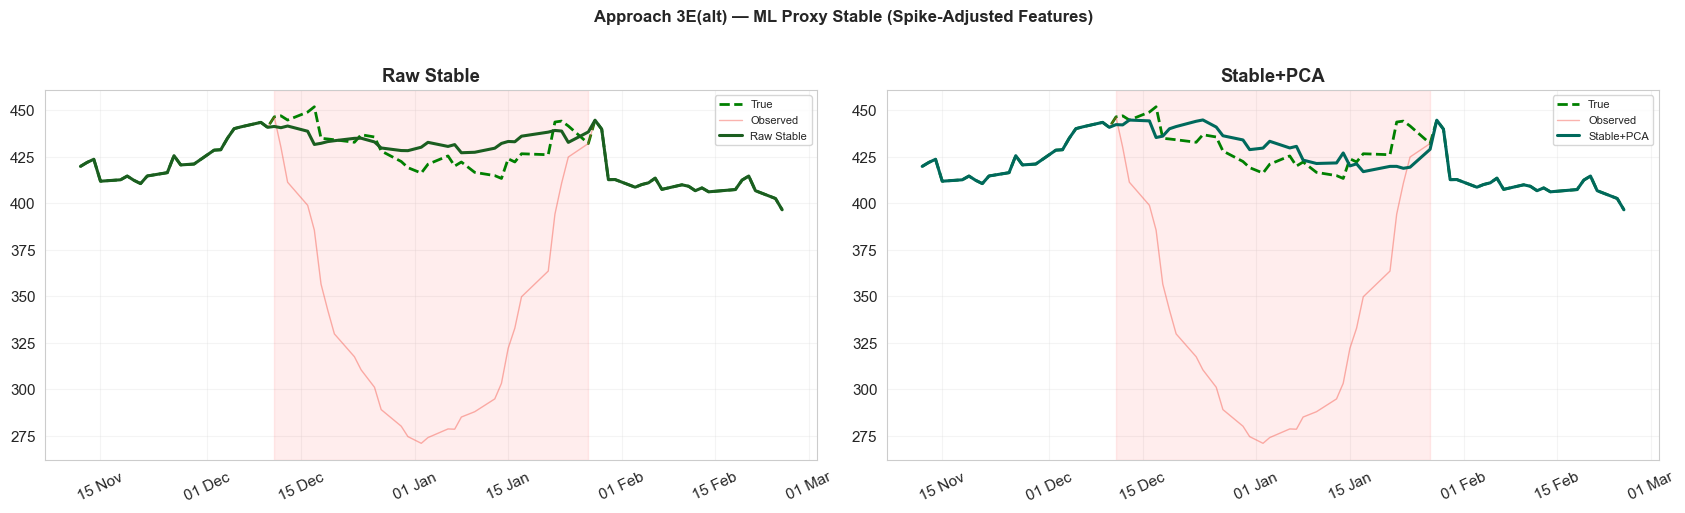

ML Proxy Stable stored in `recon`. Methods:
  ML Stable+OLS
  ML Stable+PCA+OLS
Key improvements over standard ML Proxy:
  • Spike detection at 5.0σ (MAD-based, robust to outliers)
  • Multi-horizon volatility: short=5d, long=63d (annualised)
  • Mean-reversion spread: short-term vs long-term mean return
  • Higher moments: skewness & kurtosis of recent returns
  • Downside semi-volatility (captures tail risk)
  • Feature-space clipping at ±5σ after scaling


In [102]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Approach 3E(alt) – ML Proxy Stable: Stabilised Features   ║
# ║  Spike-adjusted returns · multi-horizon vol · robust PCA   ║
# ╚══════════════════════════════════════════════════════════════╝
#
# This variant improves the standard ML Proxy by adding:
#
#   1. SPIKE DETECTION & ADJUSTMENT — detects outlier daily returns
#      (beyond spike_sigma × rolling std) and interpolates them
#      to prevent a single anomalous day from distorting the
#      entire distance matrix.
#
#   2. MULTI-HORIZON VOLATILITY — both short-term (5-day) and
#      long-term (63-day ≈ quarter) annualised volatilities as
#      separate features, capturing both recent turbulence and
#      baseline risk.
#
#   3. MEAN REVERSION / DRIFT FEATURES — short-term vs long-term
#      mean log-return spreads, capturing which peers are trending
#      vs mean-reverting relative to their baseline.
#
#   4. STABILISED PCA — optional robust scaling + PCA on the
#      expanded feature set, clipped at reasonable bounds to
#      avoid a single extreme feature dominating the distance.
#
#   5. SPIKE FRACTION — what fraction of observations were flagged
#      as spikes (higher = noisier series).
#
# Parameters (tweakable at the top of the call):
#   short_window = 5    # days for short-term metrics
#   long_window  = 63   # days for long-term metrics (~quarter)
#   spike_sigma  = 5.0  # threshold (std units) for spike detection
#   interpolate_limit = 3  # max consecutive spikes to interpolate


def feature_distance_matrix_stable(
    ret_window: pd.DataFrame,
    use_pca: bool = False,
    pca_var: float = 0.90,
    short_window: int = 5,
    long_window: int = 63,
    spike_sigma: float = 5.0,
    interpolate_limit: int = 3,
) -> pd.DataFrame:
    """Compute a stabilised feature-distance matrix with spike-robust features.

    The function expands the original feature set with multi-horizon
    volatility, mean-reversion spreads, and spike-adjusted returns,
    then computes pairwise Euclidean distance in the normalised space.

    Parameters
    ----------
    ret_window : pd.DataFrame
        Return panel (assets as columns, daily log-returns).
    use_pca : bool
        Apply PCA after feature engineering (default False).
    pca_var : float
        Explained variance target for PCA (default 0.90).
    short_window : int
        Days for short-term metrics (default 5).
    long_window : int
        Days for long-term metrics, ~63 ≈ quarter (default 63).
    spike_sigma : float
        Spike detection threshold in rolling std units (default 5.0).
    interpolate_limit : int
        Max consecutive spike days to interpolate (default 3).

    Returns
    -------
    pd.DataFrame
        Pairwise distance matrix (lower = more similar).
    """
    assets = ret_window.columns.tolist()
    features = {}

    for col in assets:
        r = ret_window[col].values  # daily log-returns

        # ── 1. Spike detection & adjustment ──
        lr_series = pd.Series(r)
        rolling_median = lr_series.rolling(short_window, center=True).median()
        rolling_mad = lr_series.rolling(short_window, center=True).apply(
            lambda x: np.median(np.abs(x - np.median(x))), raw=True
        )
        # MAD-to-sigma scaling (1.4826 for Gaussian)
        rolling_std_est = rolling_mad * 1.4826
        deviation = (lr_series - rolling_median).abs()
        spike_mask = (rolling_std_est > 1e-10) & (deviation > spike_sigma * rolling_std_est)
        spike_mask = spike_mask.fillna(False)

        # Interpolate spikes (limit consecutive gaps)
        lr_adj = lr_series.copy()
        if spike_mask.any():
            lr_adj[spike_mask] = np.nan
            lr_adj = lr_adj.interpolate(method='linear', limit=interpolate_limit)
            lr_adj = lr_adj.fillna(0.0)

        spike_fraction = float(spike_mask.mean())

        # ── 2. Multi-horizon volatility (annualised) ──
        st_vol = np.std(lr_adj.tail(short_window)) * np.sqrt(252)
        lt_vol = np.std(lr_adj.tail(long_window)) * np.sqrt(252)

        # ── 3. Mean-reversion / drift features ──
        st_mean = np.mean(lr_adj.tail(short_window)) * 252
        lt_mean = np.mean(lr_adj.tail(long_window)) * 252
        mean_spread = st_mean - lt_mean  # > 0 = recent uptrend vs baseline

        # Volatility ratio (short/long) — >1 means recent turbulence
        vol_ratio_sl = st_vol / lt_vol if lt_vol > 1e-10 else 1.0

        # ── 4. Standard deviation of the spike-adjusted series ──
        st_std_lr = np.std(lr_adj.tail(short_window))
        lt_std_lr = np.std(lr_adj.tail(long_window))

        # ── 5. Skewness & kurtosis of recent returns (higher moments) ──
        from scipy.stats import skew, kurtosis
        recent = lr_adj.tail(short_window)
        skew_5d = skew(recent) if len(recent) > 2 and np.std(recent) > 1e-10 else 0.0
        kurt_5d = kurtosis(recent, fisher=True) if len(recent) > 3 and np.std(recent) > 1e-10 else 0.0

        # ── 6. Downside deviation (semi-volatility) ──
        neg_recent = recent[recent < 0]
        downside_semi = np.std(neg_recent) if len(neg_recent) > 1 else 0.0

        # Original features (for continuity)
        orig_ret_1d = r[-1] if len(r) > 0 else 0.0
        orig_ret_3d = np.sum(r[-3:]) if len(r) >= 3 else 0.0
        orig_ret_5d = np.sum(r[-5:]) if len(r) >= 5 else 0.0
        orig_ret_10d = np.sum(r[-10:]) if len(r) >= 10 else 0.0
        orig_dd_5d = np.min(r[-5:]) if len(r) >= 5 else 0.0
        orig_dd_10d = np.min(r[-10:]) if len(r) >= 10 else 0.0
        orig_spread_mean = np.mean(np.abs(np.diff(r[-5:]))) if len(r) >= 5 else 0.0

        # Clip extreme values for numerical stability
        def clip_val(x, bound=10.0):
            return np.clip(x, -bound, bound)

        f = {
            # Spike diagnostics
            'spike_fraction': clip_val(spike_fraction),
            # Multi-horizon vol
            'st_vol_ann': clip_val(st_vol / 100),
            'lt_vol_ann': clip_val(lt_vol / 100),
            'vol_ratio_sl': clip_val(vol_ratio_sl),
            # Mean-reversion / drift
            'st_mean_ann': clip_val(st_mean / 100),
            'lt_mean_ann': clip_val(lt_mean / 100),
            'mean_spread': clip_val(mean_spread / 100),
            # Return moments
            'skew_5d': clip_val(skew_5d),
            'kurt_5d': clip_val(kurt_5d),
            'downside_semi': clip_val(downside_semi * np.sqrt(252) / 100),
            # Original features (kept for continuity)
            'ret_1d': clip_val(orig_ret_1d * 100),
            'ret_3d': clip_val(orig_ret_3d * 100),
            'ret_5d': clip_val(orig_ret_5d * 100),
            'ret_10d': clip_val(orig_ret_10d * 100),
            'dd_5d': clip_val(orig_dd_5d * 100),
            'dd_10d': clip_val(orig_dd_10d * 100),
            'spread_mean': clip_val(orig_spread_mean * 100),
        }
        features[col] = list(f.values())

    feature_names = list(f.keys())
    feat_df = pd.DataFrame.from_dict(features, orient='index', columns=feature_names)
    feat_df = feat_df.fillna(0).replace([np.inf, -np.inf], 0.0)

    # Robust scaling (clip before StandardScaler for extra stability)
    scaler = StandardScaler()
    feat_scaled = scaler.fit_transform(feat_df)
    feat_scaled = np.clip(feat_scaled, -5, 5)  # clip outliers in feature space

    if use_pca:
        pca = PCA(n_components=pca_var)
        feat_scaled = pca.fit_transform(feat_scaled)
        print(f'  StablePCA: {pca.n_components_} components explain ~{pca_var:.0%} variance')

    # Pairwise Euclidean distance
    from sklearn.metrics.pairwise import euclidean_distances
    dist_arr = euclidean_distances(feat_scaled)
    dist_arr = (dist_arr + dist_arr.T) / 2.0
    max_val = dist_arr.max()
    if max_val > 0:
        dist_arr = dist_arr / max_val
    np.fill_diagonal(dist_arr, 0.0)

    return pd.DataFrame(dist_arr, index=assets, columns=assets)


def ml_proxy_stable_reconstruction(
    ret_window: pd.DataFrame,
    ret_full: pd.DataFrame,
    prices_obs: pd.Series,
    gap_start: int,
    gap_end: int,
    use_pca: bool = False,
    model_type: str = 'ols',
    alpha: float = 1.0,
    short_window: int = 5,
    long_window: int = 63,
    spike_sigma: float = 5.0,
) -> tuple[pd.Series, dict]:
    """Reconstruct using the stabilised feature-distance matrix.

    Parameters match ``feature_distance_matrix_stable`` and
    ``ml_proxy_reconstruction`` for drop-in compatibility.
    """
    dist_mat = feature_distance_matrix_stable(
        ret_window,
        use_pca=use_pca,
        short_window=short_window,
        long_window=long_window,
        spike_sigma=spike_sigma,
    )

    linkage_mat = linkage(squareform(dist_mat.values), method='ward')
    labels = fcluster(linkage_mat, t=CLUSTER_THR, criterion='distance')
    stocks = dist_mat.columns.tolist()
    dist_cluster = labels[stocks.index('DIST')]
    same_cluster = [s for s, cid in zip(stocks, labels)
                    if cid == dist_cluster and s != 'DIST']

    corr_mat = ret_window.corr()
    raw_corr = corr_mat.loc['DIST'].drop('DIST')
    if same_cluster:
        peers = sorted(same_cluster, key=lambda s: abs(raw_corr[s]), reverse=True)[:MAX_PEERS]
        rule = 'stable-feature-cluster'
    else:
        peers = raw_corr.abs().sort_values(ascending=False).index[:MAX_PEERS].tolist()
        rule = 'stable-feature-fallback'

    peer_cols = [c for c in peers if c in ret_window.columns]
    if not peer_cols:
        raise ValueError('No peers found for ML Proxy Stable.')

    X = ret_window[peer_cols].values
    y = ret_window['DIST'].values
    model = get_regressor(model_type, alpha).fit(X, y)

    gap_ret = ret_full[peer_cols].iloc[gap_start:gap_end].values
    pred_log_ret = model.predict(gap_ret)

    reconstructed = prices_obs.copy()
    for i in range(gap_end - gap_start):
        reconstructed.iloc[gap_start + i] = (
            reconstructed.iloc[gap_start + i - 1] * np.exp(pred_log_ret[i])
        )

    info = {
        'peers': peer_cols,
        'coefs': dict(zip(peer_cols, model.coef_)),
        'r2': model.score(X, y),
        'rule': rule,
        'feature_type': 'Stable' + ('+PCA' if use_pca else ''),
        'model_type': model_type,
        'short_window': short_window,
        'long_window': long_window,
        'spike_sigma': spike_sigma,
    }
    return reconstructed, info


# ── Apply (Raw/PCA × OLS) ──
window_start = max(0, DIST_START - 1 - LOOKBACK)
window_end = DIST_START - 1
ml_stable_window = ret_df.iloc[window_start:window_end].copy()

for use_pca, pca_lbl in [(False, ''), (True, '+PCA')]:
    for mod, mod_lbl in [('ols', 'OLS')]:
        series, info = ml_proxy_stable_reconstruction(
            ml_stable_window, ret_df, prices_df['DIST_OBS'],
            DIST_START, DIST_END,
            use_pca=use_pca, model_type=mod, alpha=ALPHA,
            short_window=5, long_window=63, spike_sigma=5.0,
        )
        recon[f'ML Stable{pca_lbl}+{mod_lbl}'] = series

# ── Visualise ──
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
zoom_slice = slice(max(0, DIST_START - 20), min(len(dates), DIST_END + 20))

for ax, (label, color) in zip(axes, [('Raw Stable', '#1B5E20'), ('Stable+PCA', '#00695C')]):
    key = f'ML Stable{"" if "Raw" in label else "+PCA"}+OLS'
    ax.plot(dates[zoom_slice], prices_df['DIST_TRUE'].iloc[zoom_slice], 'g--', lw=2, label='True')
    ax.plot(dates[zoom_slice], prices_df['DIST_OBS'].iloc[zoom_slice], '#F44336', lw=1, alpha=0.4, label='Observed')
    ax.plot(dates[zoom_slice], recon[key].iloc[zoom_slice], color, lw=2.2, label=label)
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
    ax.grid(alpha=0.2)

plt.suptitle('Approach 3E(alt) — ML Proxy Stable (Spike-Adjusted Features)',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('ML Proxy Stable stored in `recon`. Methods:')
for k in recon:
    if 'ML Stable' in k:
        print(f'  {k}')
print(f'Key improvements over standard ML Proxy:')
print(f'  • Spike detection at {5.0}σ (MAD-based, robust to outliers)')
print(f'  • Multi-horizon volatility: short=5d, long=63d (annualised)')
print(f'  • Mean-reversion spread: short-term vs long-term mean return')
print(f'  • Higher moments: skewness & kurtosis of recent returns')
print(f'  • Downside semi-volatility (captures tail risk)')
print(f'  • Feature-space clipping at ±5σ after scaling')


ML Proxy Parameter Sweep: 4 × 4 = 16 combinations
  Lookback   Threshold      RMSE       MAE  Ret Corr        R²   Peers
        40        0.25    14.068    10.614   -0.2486     0.395       5
        40        0.35    14.068    10.614   -0.2486     0.395       5
        40        0.45    10.671     8.480   -0.1539     0.445       5
        40        0.55    10.671     8.480   -0.1539     0.445       5
        60        0.25    14.622    10.127   -0.2180     0.399       5
        60        0.35    14.622    10.127   -0.2180     0.399       5
        60        0.45    11.396     8.129   -0.1588     0.424       5
        60        0.55    11.396     8.129   -0.1588     0.424       5
        80        0.25    11.023     8.230   -0.2172     0.418       5
        80        0.35    11.023     8.230   -0.2172     0.418       5
        80        0.45     8.615     6.912   -0.1293     0.437       5
        80        0.55     8.615     6.912   -0.1293     0.437       5
       120        0.25    1

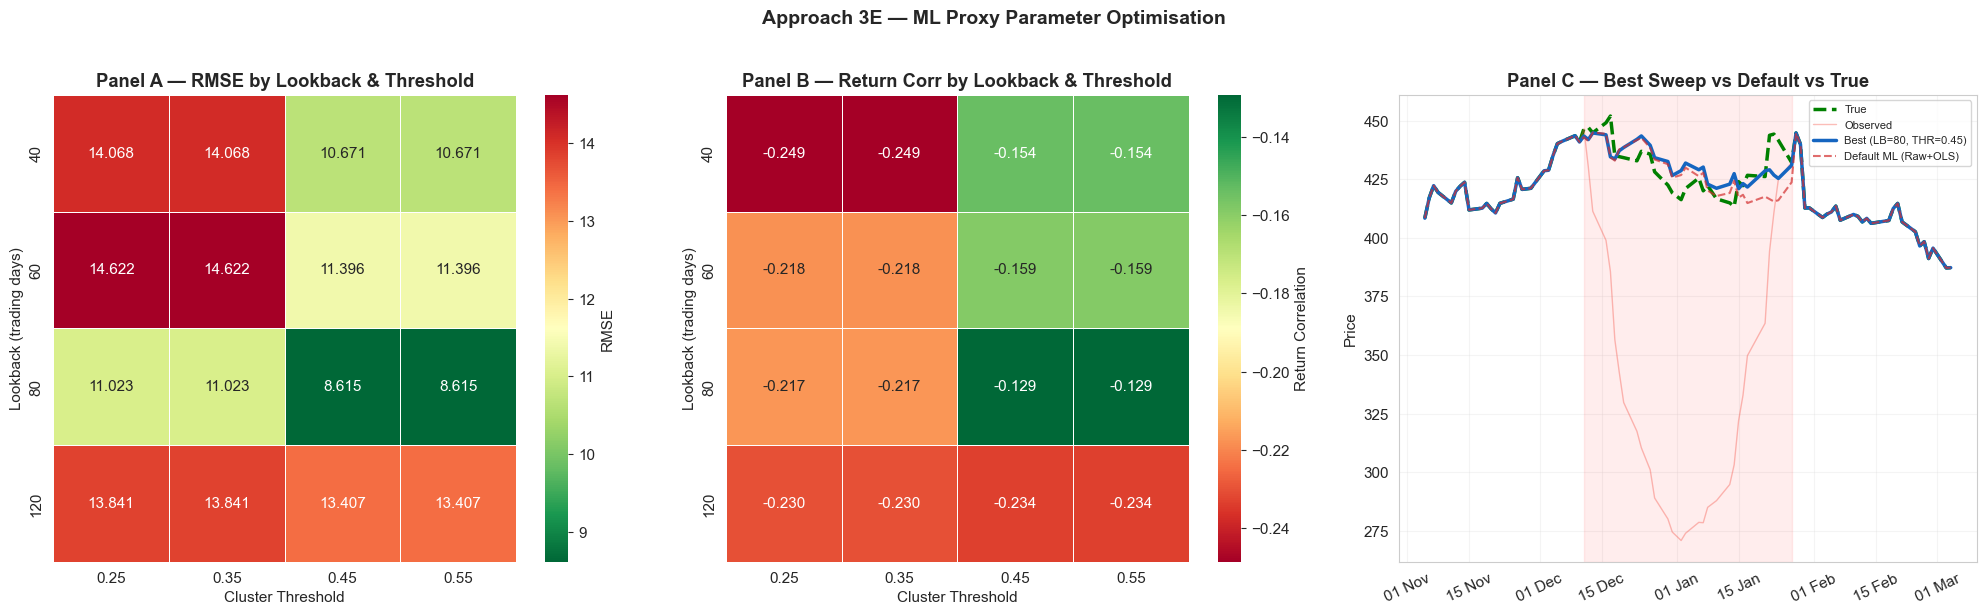


                 Parameter Sweep Results — Ranked by RMSE                  
Rank    LB   THR     RMSE      MAE  Ret Corr      R²  Peers                  Rule
1       80  0.45    8.615    6.912   -0.1293   0.437      5 feature-cluster-first ← best
2       80  0.55    8.615    6.912   -0.1293   0.437      5 feature-cluster-first
3       40  0.55   10.671    8.480   -0.1539   0.445      5 feature-cluster-first
4       40  0.45   10.671    8.480   -0.1539   0.445      5 feature-cluster-first
5       80  0.25   11.023    8.230   -0.2172   0.418      5 feature-cluster-first
6       80  0.35   11.023    8.230   -0.2172   0.418      5 feature-cluster-first
7       60  0.45   11.396    8.129   -0.1588   0.424      5 feature-cluster-first
8       60  0.55   11.396    8.129   -0.1588   0.424      5 feature-cluster-first
9      120  0.55   13.407    9.361   -0.2336   0.430      5 feature-cluster-first
10     120  0.45   13.407    9.361   -0.2336   0.430      5 feature-cluster-first
11     120  0.

In [106]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Approach 3E – ML Proxy Parameter Optimisation (Sweep)     ║
# ║  Grid search over LOOKBACK and CLUSTER_THR to find the best ║
# ║  hyper-parameter combination for ml_proxy_reconstruction    ║
# ╚══════════════════════════════════════════════════════════════╝
#
# The ML Proxy (Approach 3D) depends on two key parameters that
# control how peers are selected:
#
#   LOOKBACK    – how many prior trading days are used to estimate
#                 feature distances and fit the regression
#   CLUSTER_THR – the dendrogram cut threshold that determines
#                 which peers are in "DIST's cluster"
#
# This cell sweeps a grid of both parameters, runs the ML Proxy
# (Raw features + OLS) for each combination, and ranks results
# by RMSE against the true prices.

from sklearn.metrics import mean_squared_error

# ── Parameter grid ──
LOOKBACK_GRID = [40, 60, 80, 120]
THRESH_GRID = [0.25, 0.35, 0.45, 0.55]

# ── Reference for evaluation ──
sweep_true_period = prices_df['DIST_TRUE'].iloc[DIST_START:DIST_END].values
sweep_z0, sweep_z1 = DIST_START - 25, DIST_END + 25  # zoom window for charts

# ── Store results ──
sweep_rows = []
sweep_results = {}  # (lookback, thresh) -> reconstructed series

best_rmse = np.inf
best_params = (None, None)
best_series = None

print(f'ML Proxy Parameter Sweep: {len(LOOKBACK_GRID)} × {len(THRESH_GRID)} = {len(LOOKBACK_GRID)*len(THRESH_GRID)} combinations')
print(f'{"="*75}')
print(f'{"Lookback":>10}{"Threshold":>12}{"RMSE":>10}{"MAE":>10}{"Ret Corr":>10}{"R²":>10}{"Peers":>8}')
print(f'{"="*75}')

for lb in LOOKBACK_GRID:
    for thr in THRESH_GRID:
        # Temporarily override globals
        orig_lb = LOOKBACK
        orig_thr = CLUSTER_THR
        orig_mp = MAX_PEERS

        try:
            # Set the sweep parameters
            LOOKBACK = lb
            CLUSTER_THR = thr
            MAX_PEERS = 5  # keep fixed for fair comparison

            # Build the pre-distress return window with this lookback
            win_start = max(0, DIST_START - 1 - lb)
            win_end = DIST_START - 1
            sweep_window = ret_df.iloc[win_start:win_end].copy()

            # Run ML Proxy (Raw features + OLS)
            series, info = ml_proxy_reconstruction(
                sweep_window, ret_df, prices_df['DIST_OBS'],
                DIST_START, DIST_END, use_pca=False, model_type='ols')

            # Evaluate
            pred = series.iloc[DIST_START:DIST_END].values
            true = sweep_true_period

            rmse = np.sqrt(mean_squared_error(true, pred))
            mae = np.mean(np.abs(true - pred))

            pred_ret = np.log(pred / series.iloc[DIST_START - 1:DIST_END - 1].values)
            true_ret = np.log(true / prices_df['DIST_TRUE'].iloc[DIST_START - 1:DIST_END - 1].values)
            ret_corr = np.corrcoef(pred_ret, true_ret)[0, 1]

            sweep_rows.append({
                'Lookback': lb,
                'Threshold': thr,
                'RMSE': rmse,
                'MAE': mae,
                'Ret Corr': ret_corr,
                'R² (fit)': info['r2'],
                'N Peers': len(info['peers']),
                'Peers': ', '.join(info['peers'][:3]),
                'Rule': info['rule'],
            })
            sweep_results[(lb, thr)] = series

            print(f'{lb:>10}{thr:>12.2f}{rmse:>10.3f}{mae:>10.3f}{ret_corr:>10.4f}{info["r2"]:>10.3f}{len(info["peers"]):>8}')

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = (lb, thr)
                best_series = series.copy()

        finally:
            # Restore globals
            LOOKBACK = orig_lb
            CLUSTER_THR = orig_thr
            MAX_PEERS = orig_mp

print(f'{"="*75}')
print(f'Best: lookback={best_params[0]}, threshold={best_params[1]:.2f}  |  RMSE={best_rmse:.3f}')

# ── Build results DataFrame ──
sweep_df = pd.DataFrame(sweep_rows).sort_values('RMSE').reset_index(drop=True)

# ── Visualise ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: RMSE heatmap (lookback × threshold)
ax = axes[0]
pivot = sweep_df.pivot_table(index='Lookback', columns='Threshold',
                              values='RMSE', aggfunc='mean')
sns.heatmap(pivot, annot=pivot.round(3), fmt='.3f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'RMSE'})
ax.set_title('Panel A — RMSE by Lookback & Threshold', fontweight='bold')
ax.set_ylabel('Lookback (trading days)')
ax.set_xlabel('Cluster Threshold')

# Panel 2: Return Correlation heatmap
ax = axes[1]
pivot_corr = sweep_df.pivot_table(index='Lookback', columns='Threshold',
                                   values='Ret Corr', aggfunc='mean')
sns.heatmap(pivot_corr, annot=pivot_corr.round(3), fmt='.3f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Return Correlation'})
ax.set_title('Panel B — Return Corr by Lookback & Threshold', fontweight='bold')
ax.set_ylabel('Lookback (trading days)')
ax.set_xlabel('Cluster Threshold')

# Panel 3: Best vs default vs true price overlay
ax = axes[2]
zoom = slice(sweep_z0, min(sweep_z1, len(dates)))

# Best reconstruction
ax.plot(dates[zoom], prices_df['DIST_TRUE'].iloc[zoom], 'g--', lw=2.5, label='True')
ax.plot(dates[zoom], prices_df['DIST_OBS'].iloc[zoom], '#F44336', lw=1, alpha=0.35, label='Observed')
ax.plot(dates[zoom], best_series.iloc[zoom], '#1565C0', lw=2.5,
        label=f'Best (LB={best_params[0]}, THR={best_params[1]:.2f})')

# Overlay the default ML Proxy result for comparison
if 'Feature Raw Proxy+OLS' in recon:
    ax.plot(dates[zoom], recon['Feature Raw Proxy+OLS'].iloc[zoom], '#D32F2F',
            lw=1.5, ls='--', alpha=0.7, label='Default ML (Raw+OLS)')

ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
ax.set_title('Panel C — Best Sweep vs Default vs True', fontweight='bold')
ax.set_ylabel('Price')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
ax.grid(alpha=0.2)

plt.suptitle('Approach 3E — ML Proxy Parameter Optimisation',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Print ranked table ──
print(f'\n{"Parameter Sweep Results — Ranked by RMSE":^75}')
print(f'{"="*75}')
print(f'{"Rank":<5}{"LB":>5}{"THR":>6}{"RMSE":>9}{"MAE":>9}{"Ret Corr":>10}{"R²":>8}{"Peers":>7}{"Rule":>22}')
print(f'{"="*75}')

for rank, (_, r) in enumerate(sweep_df.iterrows()):
    rank_str = f'{rank+1}'
    mark = ' ← best' if rank == 0 else ''
    print(f'{rank_str:<5}{r["Lookback"]:>5}{r["Threshold"]:>6.2f}{r["RMSE"]:>9.3f}'
          f'{r["MAE"]:>9.3f}{r["Ret Corr"]:>10.4f}{r["R² (fit)"]:>8.3f}'
          f'{r["N Peers"]:>7}{r["Rule"]:>22}{mark}')

print(f'{"="*75}')
print(f'Default parameters: LOOKBACK={orig_lb}, CLUSTER_THR={orig_thr:.2f}')
print(f'Best parameters:    LOOKBACK={best_params[0]}, CLUSTER_THR={best_params[1]:.2f}')

# Check if default is in the grid
if orig_lb in LOOKBACK_GRID and orig_thr in THRESH_GRID:
    default_rmse = sweep_df[(sweep_df['Lookback'] == orig_lb) &
                            (sweep_df['Threshold'] == orig_thr)]['RMSE'].values[0]
    improvement = ((default_rmse - best_rmse) / default_rmse) * 100
    print(f'RMSE improvement over default: {improvement:.1f}%')
else:
    print(f'(Default params not in sweep grid — widen the grid to compare)')

# Optionally store the best run in recon
recon['ML Proxy+Opt (Best Sweep)'] = best_series
print(f'\nBest series stored in `recon["ML Proxy+Opt (Best Sweep)"]`')

Cointegration candidate pool: 15 peers
  Top 5: ['TEL', 'CDNS', 'APH', 'KLAC', 'ORCL']


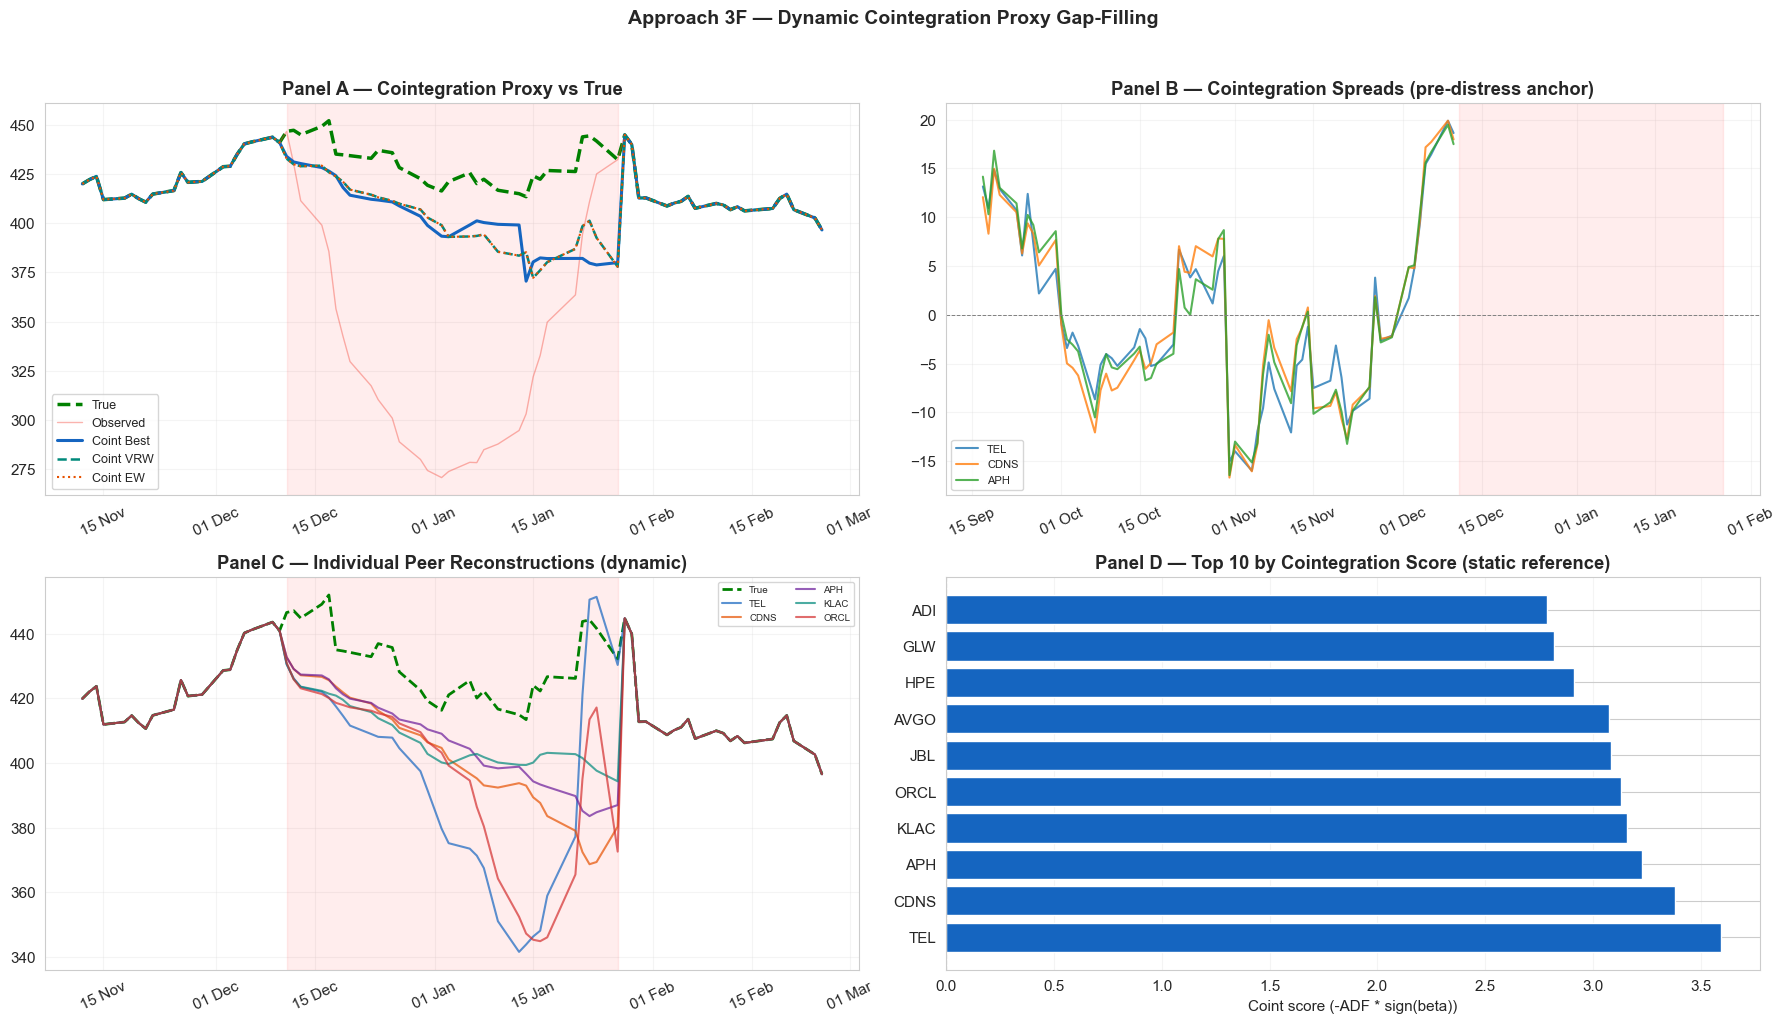

Dynamic cointegration proxy stored in `recon`. Methods:
  Coint Proxy: Coint Best
  Key differences from the static version:
    • Cointegration re-estimated daily on a 80-day rolling window
    • VR-weighted ensemble (Coint VRW) — peers with VR closer to 1.0 get higher weight
    • Equal-weighted ensemble (Coint EW) — for comparison
    • Best single peer (Coint Best) — highest coint_score each day
  Coint Proxy: Coint EW
  Key differences from the static version:
    • Cointegration re-estimated daily on a 80-day rolling window
    • VR-weighted ensemble (Coint VRW) — peers with VR closer to 1.0 get higher weight
    • Equal-weighted ensemble (Coint EW) — for comparison
    • Best single peer (Coint Best) — highest coint_score each day
  Coint Proxy: Coint VRW
  Key differences from the static version:
    • Cointegration re-estimated daily on a 80-day rolling window
    • VR-weighted ensemble (Coint VRW) — peers with VR closer to 1.0 get higher weight
    • Equal-weighted ensemble (

In [107]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Approach 3F – Cointegration Proxy (Dynamic)                ║
# ║  Rolling cointegration + error correction + VR-weighted     ║
# ╚══════════════════════════════════════════════════════════════╝
#
# This cell takes a DYNAMIC approach to cointegration-based reconstruction:
#
#   • For each day in the distress window, re-estimates the cointegration
#     relationship on a ROLLING lookback window (like the Dynamic Proxy).
#   • Tests ALL model peers for cointegration each day, not just a static
#     pre-selected set — the best cointegrated peers can change over time.
#   • Reconstructs via error-correction:  P_t = P_{t-1} + 0.5 × (expected − P_{t-1})
#   • Builds a volatility-ratio-weighted ensemble (peers with VR closer to 1.0
#     get higher weight in the aggregate reconstruction).
#   • Also stores an equal-weighted ensemble for comparison.
#
# Why "dynamic"? The cointegration relationship between a distressed stock and
# its peers is NOT stable — it can strengthen, weaken, or even reverse during
# the window.  A static pre-distress snapshot misses this evolution.


def dynamic_cointegration_reconstruction(
    prices_df,
    target_col: str,
    candidate_peers: list[str],
    gap_start: int,
    gap_end: int,
    ret_df,
    lookback: int = 80,
    n_top: int = 5,
    min_history: int = 30,
    correction_speed: float = 0.5,
) -> dict:
    """Dynamic cointegration-based gap-filling with VR-weighted ensemble.

    For each day in the distress window:
      1. Take a rolling window (``lookback`` days) of price data ending at the
         current day.
      2. For every candidate peer, fit OLS: P_target = alpha + beta * P_peer.
      3. Run the ADF test on the OLS residuals to measure cointegration strength
         (coint_score = -ADF_stat * sign(beta); higher = stronger).
      4. Compute the peer's trailing vol_ratio and vol_score to use as an
         ensemble weight.
      5. Select the top ``n_top`` peers by coint_score.
      6. Reconstruct via error correction: apply each peer's alpha+beta to
         predict the current target price, then correct toward it.

    Parameters
    ----------
    prices_df : pd.DataFrame
        Full price panel with at least ``target_col`` and candidate peer columns.
    target_col : str
        Column name of the observed (corrupted) target price.
    candidate_peers : list[str]
        List of peer tickers to test for cointegration each day.
    gap_start, gap_end : int
        Indices defining the distress window.
    ret_df : pd.DataFrame
        Full return panel (same assets) for vol_ratio computation.
    lookback : int, optional
        Rolling window size in trading days (default 80).
    n_top : int, optional
        Number of best cointegrated peers to keep each day (default 5).
    min_history : int, optional
        Minimum overlapping history required for a valid OLS fit (default 30).
    correction_speed : float, optional
        Speed of error correction:  P_t = P_{t-1} + speed × (expected − P_{t-1})
        (default 0.5).

    Returns
    -------
    dict
        Keys:
          - ``'Coint Best'`` — reconstruction from the single best peer each day
          - ``'Coint EW'``   — equal-weighted ensemble of top peers
          - ``'Coint VRW'``   — volatility-ratio-weighted ensemble
        Each value is a full-length pd.Series with the gap filled.
    """
    # Pre-compute peer vol_ratios on the full clean pre-window for stable weights
    clean_ret = ret_df.iloc[:max(gap_start, lookback)]
    peer_vol_ratios = {}
    for t in candidate_peers:
        if t in clean_ret.columns and target_col in clean_ret.columns:
            pair = clean_ret[[target_col, t]].dropna()
            if len(pair) >= min_history:
                vr = pair[t].std() / pair[target_col].std()
                peer_vol_ratios[t] = float(vr)

    # Initialise full-length result series from the observed prices
    best_rec = prices_df[target_col].copy()
    ew_rec = prices_df[target_col].copy()
    vrw_rec = prices_df[target_col].copy()
    daily_log = []

    for day in range(gap_start, gap_end):
        win_start = max(0, day - lookback)
        price_window = prices_df.iloc[win_start:day]
        ret_window = ret_df.iloc[win_start:day]

        if len(price_window) < min_history:
            # Not enough data — carry forward
            best_rec.iloc[day] = best_rec.iloc[day - 1]
            ew_rec.iloc[day] = ew_rec.iloc[day - 1]
            vrw_rec.iloc[day] = vrw_rec.iloc[day - 1]
            continue

        # ── Test all candidates for cointegration on this rolling window ──
        scores = {}
        models = {}
        for t in candidate_peers:
            pair = price_window[[target_col, t]].dropna()
            if len(pair) < min_history:
                continue
            X = np.column_stack([np.ones(len(pair)), pair[t].values])
            y = pair[target_col].values
            try:
                beta = np.linalg.lstsq(X, y, rcond=None)[0]
                spread = y - X @ beta
                adf = adfuller(spread, maxlag=min(8, len(spread)//4), autolag='AIC')[0]
                score = -adf * np.sign(beta[1])
            except Exception:
                continue
            scores[t] = float(score)
            models[t] = {'alpha': beta[0], 'beta': beta[1]}

        if not scores:
            best_rec.iloc[day] = best_rec.iloc[day - 1]
            ew_rec.iloc[day] = ew_rec.iloc[day - 1]
            vrw_rec.iloc[day] = vrw_rec.iloc[day - 1]
            continue

        # Top N by coint_score
        top = sorted(scores, key=scores.get, reverse=True)[:n_top]

        # ── Build individual predictions for each top peer ──
        preds = {}
        for t in top:
            m = models[t]
            expected = m['alpha'] + m['beta'] * prices_df[t].iloc[day]
            preds[t] = best_rec.iloc[day - 1] + correction_speed * (expected - best_rec.iloc[day - 1])

        # Store best single peer
        best_rec.iloc[day] = preds[top[0]]

        # ── Equal-weighted ensemble ──
        ew_rec.iloc[day] = np.mean([preds[t] for t in top])

        # ── Volatility-ratio-weighted ensemble ──
        weights = {}
        for t in top:
            vr = peer_vol_ratios.get(t, 1.0)
            # vol_score: 1.0 when VR == 1.0, decays as VR deviates
            vol_score = np.exp(-abs(np.log(max(vr, 1e-6))))
            weights[t] = vol_score
        total_w = sum(weights.values())
        if total_w > 0:
            w_norm = {t: w / total_w for t, w in weights.items()}
            vrw_rec.iloc[day] = sum(preds[t] * w_norm[t] for t in top)
        else:
            vrw_rec.iloc[day] = ew_rec.iloc[day]  # fallback to EW

        daily_log.append({
            'date': prices_df.index[day],
            'n_coint': len(top),
            'best_peer': top[0],
            'best_score': scores[top[0]],
            'top_peers': ', '.join(top[:3]),
            'vol_weights': ', '.join(f'{t}={weights[t]:.2f}' for t in top[:3]),
        })

    return {
        'Coint Best': best_rec,
        'Coint EW': ew_rec,
        'Coint VRW': vrw_rec,
    }


# ── Apply ──
from statsmodels.tsa.stattools import adfuller

# Use the top cointegrated peers from the static scoring as the candidate pool,
# but the function will re-score them DYNAMICALLY each day.
coint_candidates = peers_performance_df.sort_values('coint_score', ascending=False).head(15)['ticker'].tolist()
print(f'Cointegration candidate pool: {len(coint_candidates)} peers')
print(f'  Top 5: {coint_candidates[:5]}')

coint_results = dynamic_cointegration_reconstruction(
    prices_df=prices_df,
    target_col='DIST_OBS',
    candidate_peers=coint_candidates,
    gap_start=DIST_START,
    gap_end=DIST_END,
    ret_df=ret_df,
    lookback=LOOKBACK,
    n_top=5,
    correction_speed=0.5,
)

# Store summary entries in recon
for name in ('Coint Best', 'Coint EW', 'Coint VRW'):
    recon[f'Coint Proxy: {name}'] = coint_results[name]

# ── 4-panel visualisation ──
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
z = slice(max(0, DIST_START - 20), min(len(dates), DIST_END + 20))

# Panel A: Best coint proxy vs True vs Observed
ax = axes[0, 0]
ax.plot(dates[z], prices_df['DIST_TRUE'].iloc[z], 'g--', lw=2.5, label='True')
ax.plot(dates[z], prices_df['DIST_OBS'].iloc[z], '#F44336', lw=1, alpha=0.4, label='Observed')
ax.plot(dates[z], coint_results['Coint Best'].iloc[z], '#1565C0', lw=2.2, label='Coint Best')
ax.plot(dates[z], coint_results['Coint VRW'].iloc[z], '#00897B', lw=1.8, ls='--', label='Coint VRW')
ax.plot(dates[z], coint_results['Coint EW'].iloc[z], '#E65100', lw=1.5, ls=':', label='Coint EW')
ax.axvspan(dates[DIST_START], dates[DIST_END-1], color='red', alpha=0.07)
ax.set_title('Panel A — Cointegration Proxy vs True', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B: Cointegration spreads of rolling top peers
ax = axes[0, 1]
# Estimate a single spread for each candidate using the full pre-distress anchor
anchor = prices_df[coint_candidates + ['DIST_OBS']].iloc[max(0, DIST_START - 60):DIST_START].dropna()
for t in coint_candidates[:3]:
    pair = anchor[['DIST_OBS', t]].dropna()
    if len(pair) < 30:
        continue
    X = np.column_stack([np.ones(len(pair)), pair[t].values])
    beta = np.linalg.lstsq(X, pair['DIST_OBS'].values, rcond=None)[0]
    spread = pair['DIST_OBS'].values - X @ beta
    ax.plot(anchor.index[:len(spread)], spread, lw=1.5, alpha=0.8, label=t)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.axvspan(dates[DIST_START], dates[DIST_END-1], color='red', alpha=0.07)
ax.set_title('Panel B — Cointegration Spreads (pre-distress anchor)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel C: Individual peer reconstructions (from coint_results, not recon)
ax = axes[1, 0]
# Re-run for individual peers using coint_results structure
# We store the individual peer predictions from coint_results
colors = ['#1565C0', '#E65100', '#6A1B9A', '#00897B', '#D32F2F']
# Get the top 5 peers from the static coint score for the plot
plot_peers = coint_candidates[:5]
# Run individual reconstructions for display
from statsmodels.tsa.stattools import adfuller as adf_func
individual_recs = {}
for t in plot_peers:
    rec = prices_df['DIST_OBS'].copy()
    for d in range(DIST_START, DIST_END):
        win_start = max(0, d - LOOKBACK)
        pair = prices_df[['DIST_OBS', t]].iloc[win_start:d].dropna()
        if len(pair) < 30:
            rec.iloc[d] = rec.iloc[d - 1]
            continue
        X = np.column_stack([np.ones(len(pair)), pair[t].values])
        beta = np.linalg.lstsq(X, pair['DIST_OBS'].values, rcond=None)[0]
        expected = beta[0] + beta[1] * prices_df[t].iloc[d]
        rec.iloc[d] = rec.iloc[d - 1] + 0.5 * (expected - rec.iloc[d - 1])
    individual_recs[t] = rec

ax.plot(dates[z], prices_df['DIST_TRUE'].iloc[z], 'g--', lw=2, label='True')
for idx, t in enumerate(plot_peers):
    ax.plot(dates[z], individual_recs[t].iloc[z], color=colors[idx%len(colors)],
            lw=1.5, alpha=0.7, label=t)
ax.axvspan(dates[DIST_START], dates[DIST_END-1], color='red', alpha=0.07)
ax.set_title('Panel C — Individual Peer Reconstructions (dynamic)', fontweight='bold')
ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel D: Cointegration scores (static, for reference)
ax = axes[1, 1]
top_c = peers_performance_df.sort_values('coint_score', ascending=False).head(10)
axis_colors = ['#1565C0' if v > 0 else '#E65100' for v in top_c['coint_score']]
ax.barh(range(len(top_c)), top_c['coint_score'].values, color=axis_colors, edgecolor='white')
ax.set_yticks(range(len(top_c)))
ax.set_yticklabels(top_c['ticker'])
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_title('Panel D — Top 10 by Cointegration Score (static reference)', fontweight='bold')
ax.set_xlabel('Coint score (-ADF * sign(beta))')
ax.grid(axis='x', alpha=0.2)

plt.suptitle('Approach 3F — Dynamic Cointegration Proxy Gap-Filling',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Dynamic cointegration proxy stored in `recon`. Methods:')
for k in ('Coint Best', 'Coint EW', 'Coint VRW'):
    print(f'  Coint Proxy: {k}')
    print(f'  Key differences from the static version:')
    print(f'    • Cointegration re-estimated daily on a {LOOKBACK}-day rolling window')
    print(f'    • VR-weighted ensemble (Coint VRW) — peers with VR closer to 1.0 get higher weight')
    print(f'    • Equal-weighted ensemble (Coint EW) — for comparison')
    print(f'    • Best single peer (Coint Best) — highest coint_score each day')


,Method,RMSE,MAE,Max AE,Return Corr,Price Corr,Vol Ratio,Final Gap
0,ML Proxy+Opt (Best Sweep),8.615,6.912,17.500,-0.129,0.639,0.636,-1.247
1,ML Stable+OLS,9.234,7.731,20.287,-0.069,0.694,0.431,6.241
2,ML Stable+PCA+OLS,10.838,8.688,25.413,-0.258,0.447,0.646,-3.102
3,Feature Raw Proxy+OLS,11.023,8.230,28.761,-0.217,0.481,0.659,-8.487
4,Static Proxy+OLS,11.433,9.338,28.586,-0.303,0.439,0.692,1.520
5,Feature PCA Proxy+OLS,13.017,11.082,29.181,-0.337,0.310,0.661,-2.466
6,Forward Fill,14.905,12.710,27.509,nan,nan,0.000,8.722
7,Linear Interp,16.594,14.047,30.240,-0.104,-0.426,0.000,12.447
8,Backward Fill,17.700,14.813,31.358,0.175,nan,0.110,12.571
9,Dynamic Proxy+OLS,29.301,24.541,68.752,0.137,0.605,1.012,-59.908


Ranking by RMSE (lower is better):
Rank Method                            RMSE     MAE  Ret Corr  Vol Ratio
------------------------------------------------------------------------
1    ML Proxy+Opt (Best Sweep)        8.615   6.912   -0.1293      0.636
2    ML Stable+OLS                    9.234   7.731   -0.0685      0.431
3    ML Stable+PCA+OLS               10.838   8.688   -0.2583      0.646
4    Feature Raw Proxy+OLS           11.023   8.230   -0.2172      0.659
5    Static Proxy+OLS                11.433   9.338   -0.3025      0.692
6    Feature PCA Proxy+OLS           13.017  11.082   -0.3370      0.661
7    Forward Fill                    14.905  12.710       nan      0.000
8    Linear Interp                   16.594  14.047   -0.1037      0.000
9    Backward Fill                   17.700  14.813    0.1750      0.110
10   Dynamic Proxy+OLS               29.301  24.541    0.1374      1.012
11   Coint Proxy: Coint VRW          31.073  28.373    0.2790      0.955
12   Coint Proxy

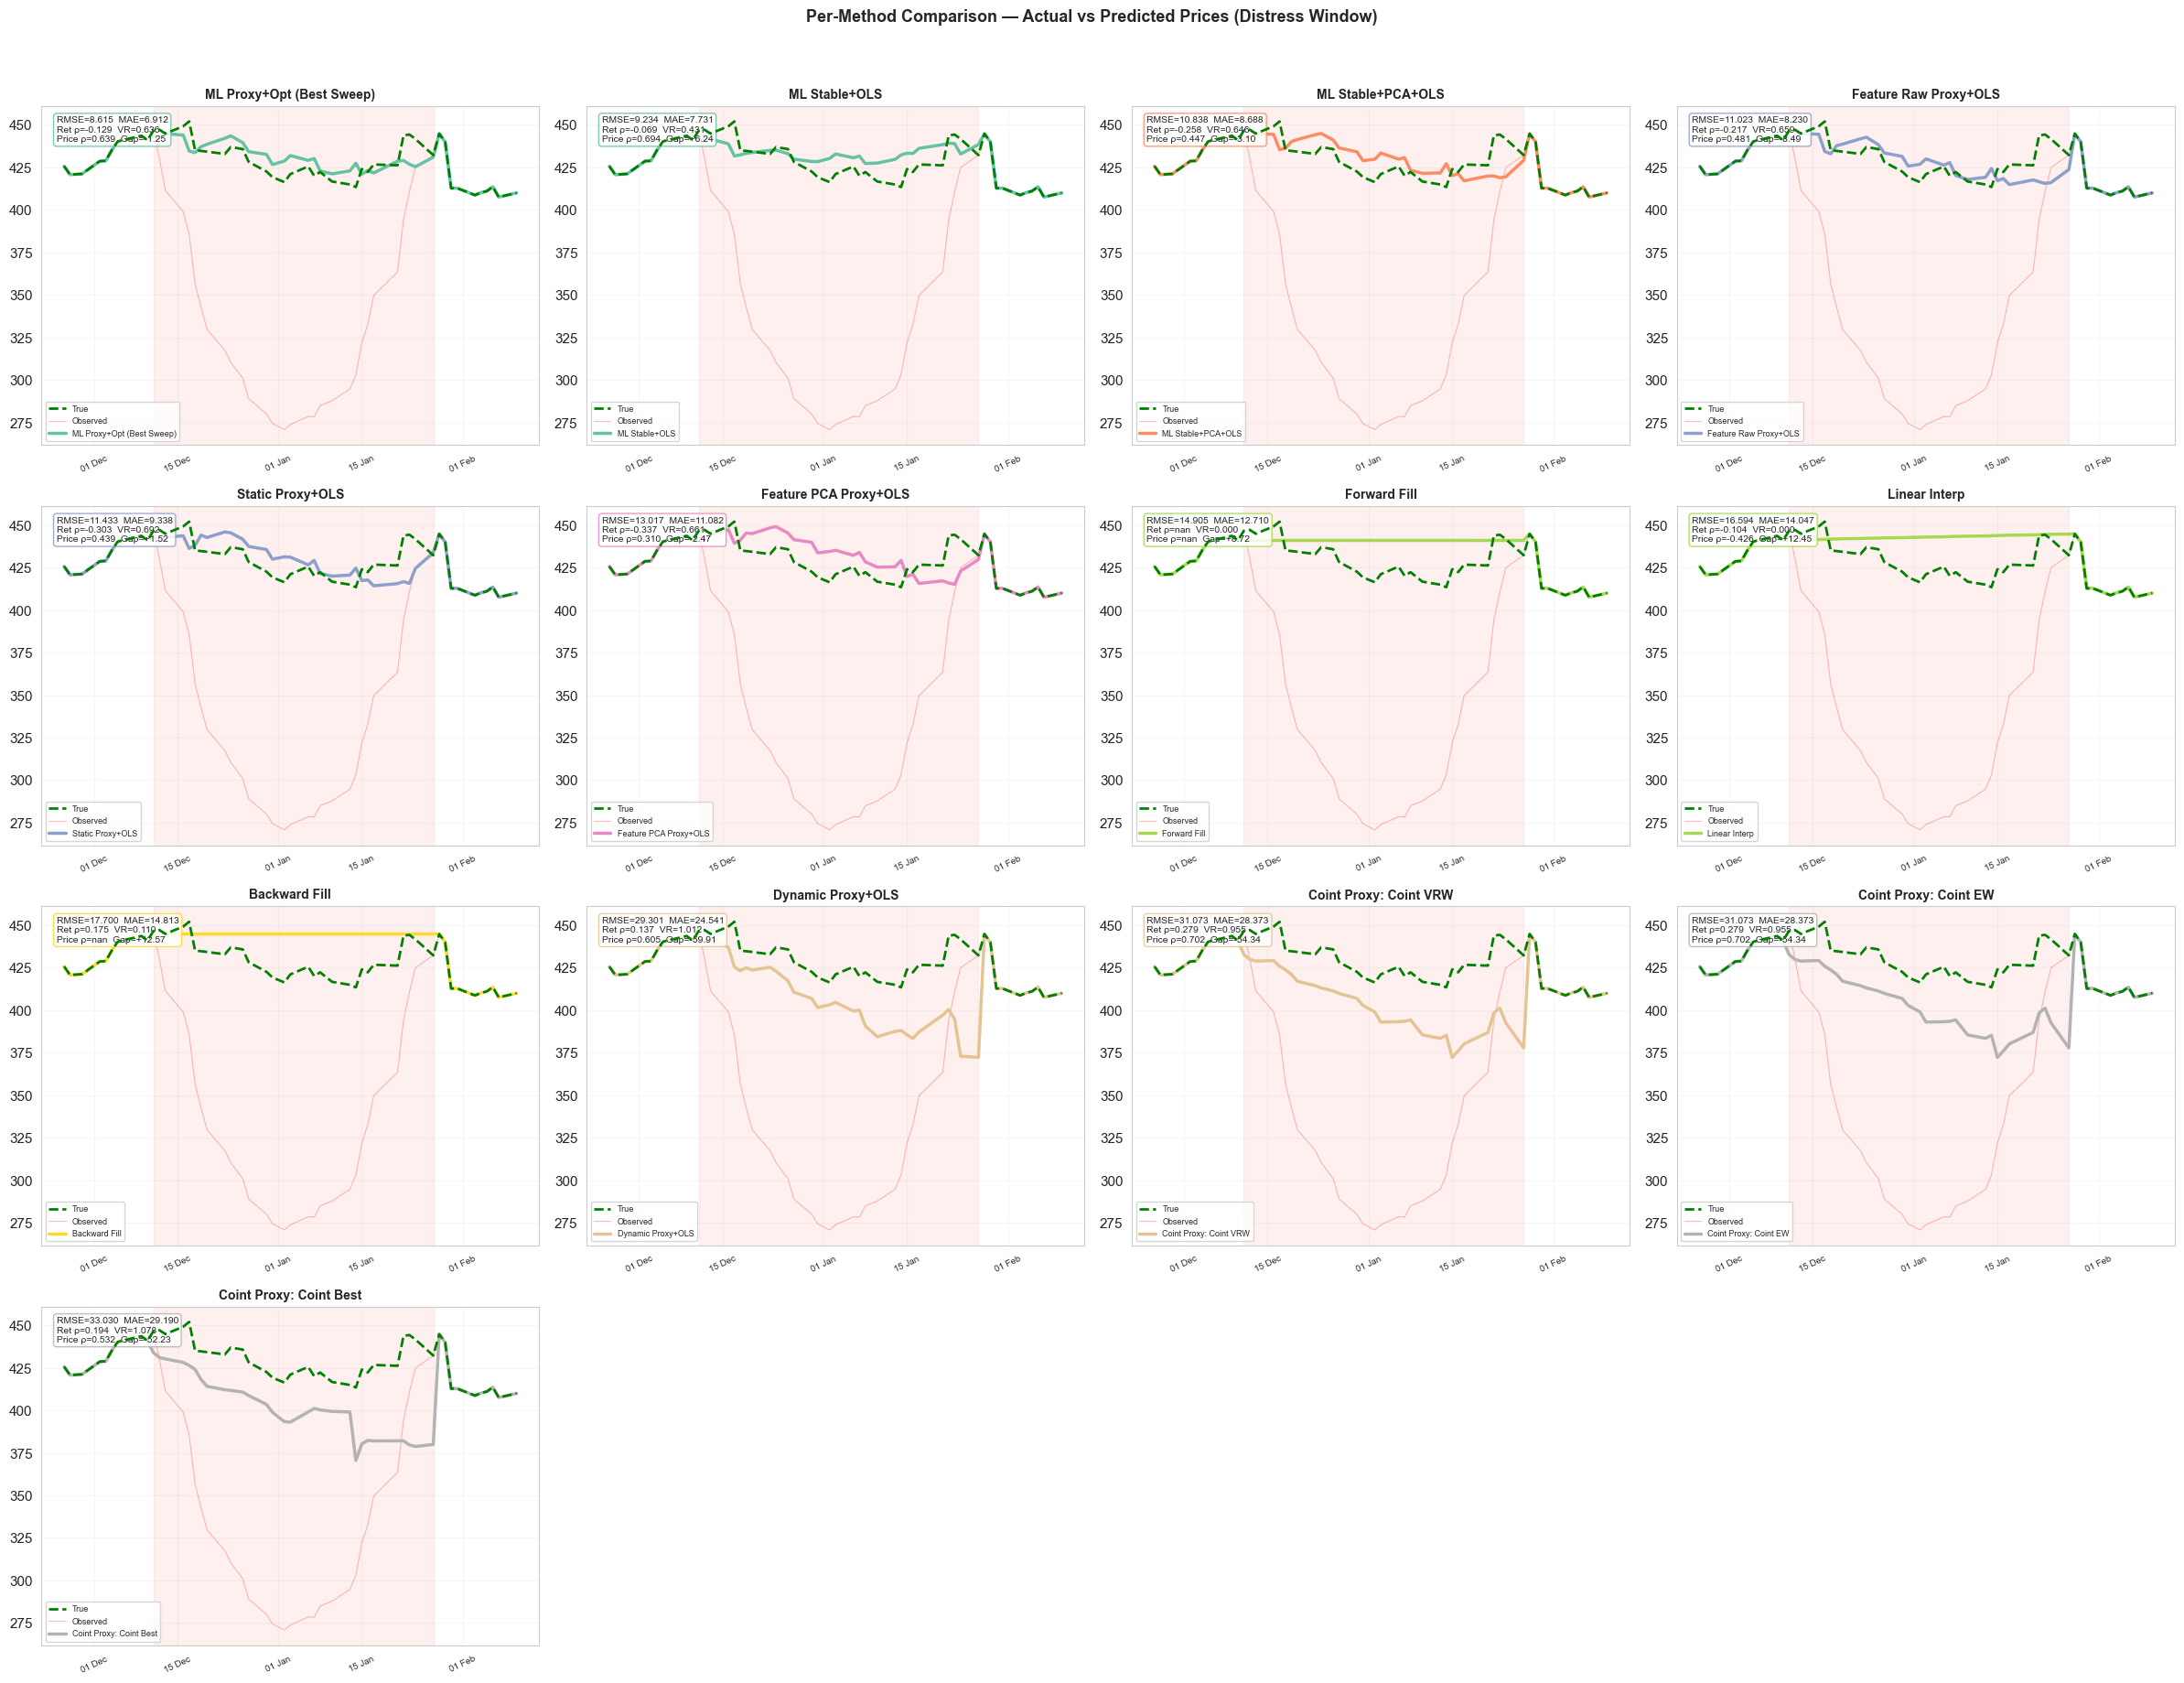

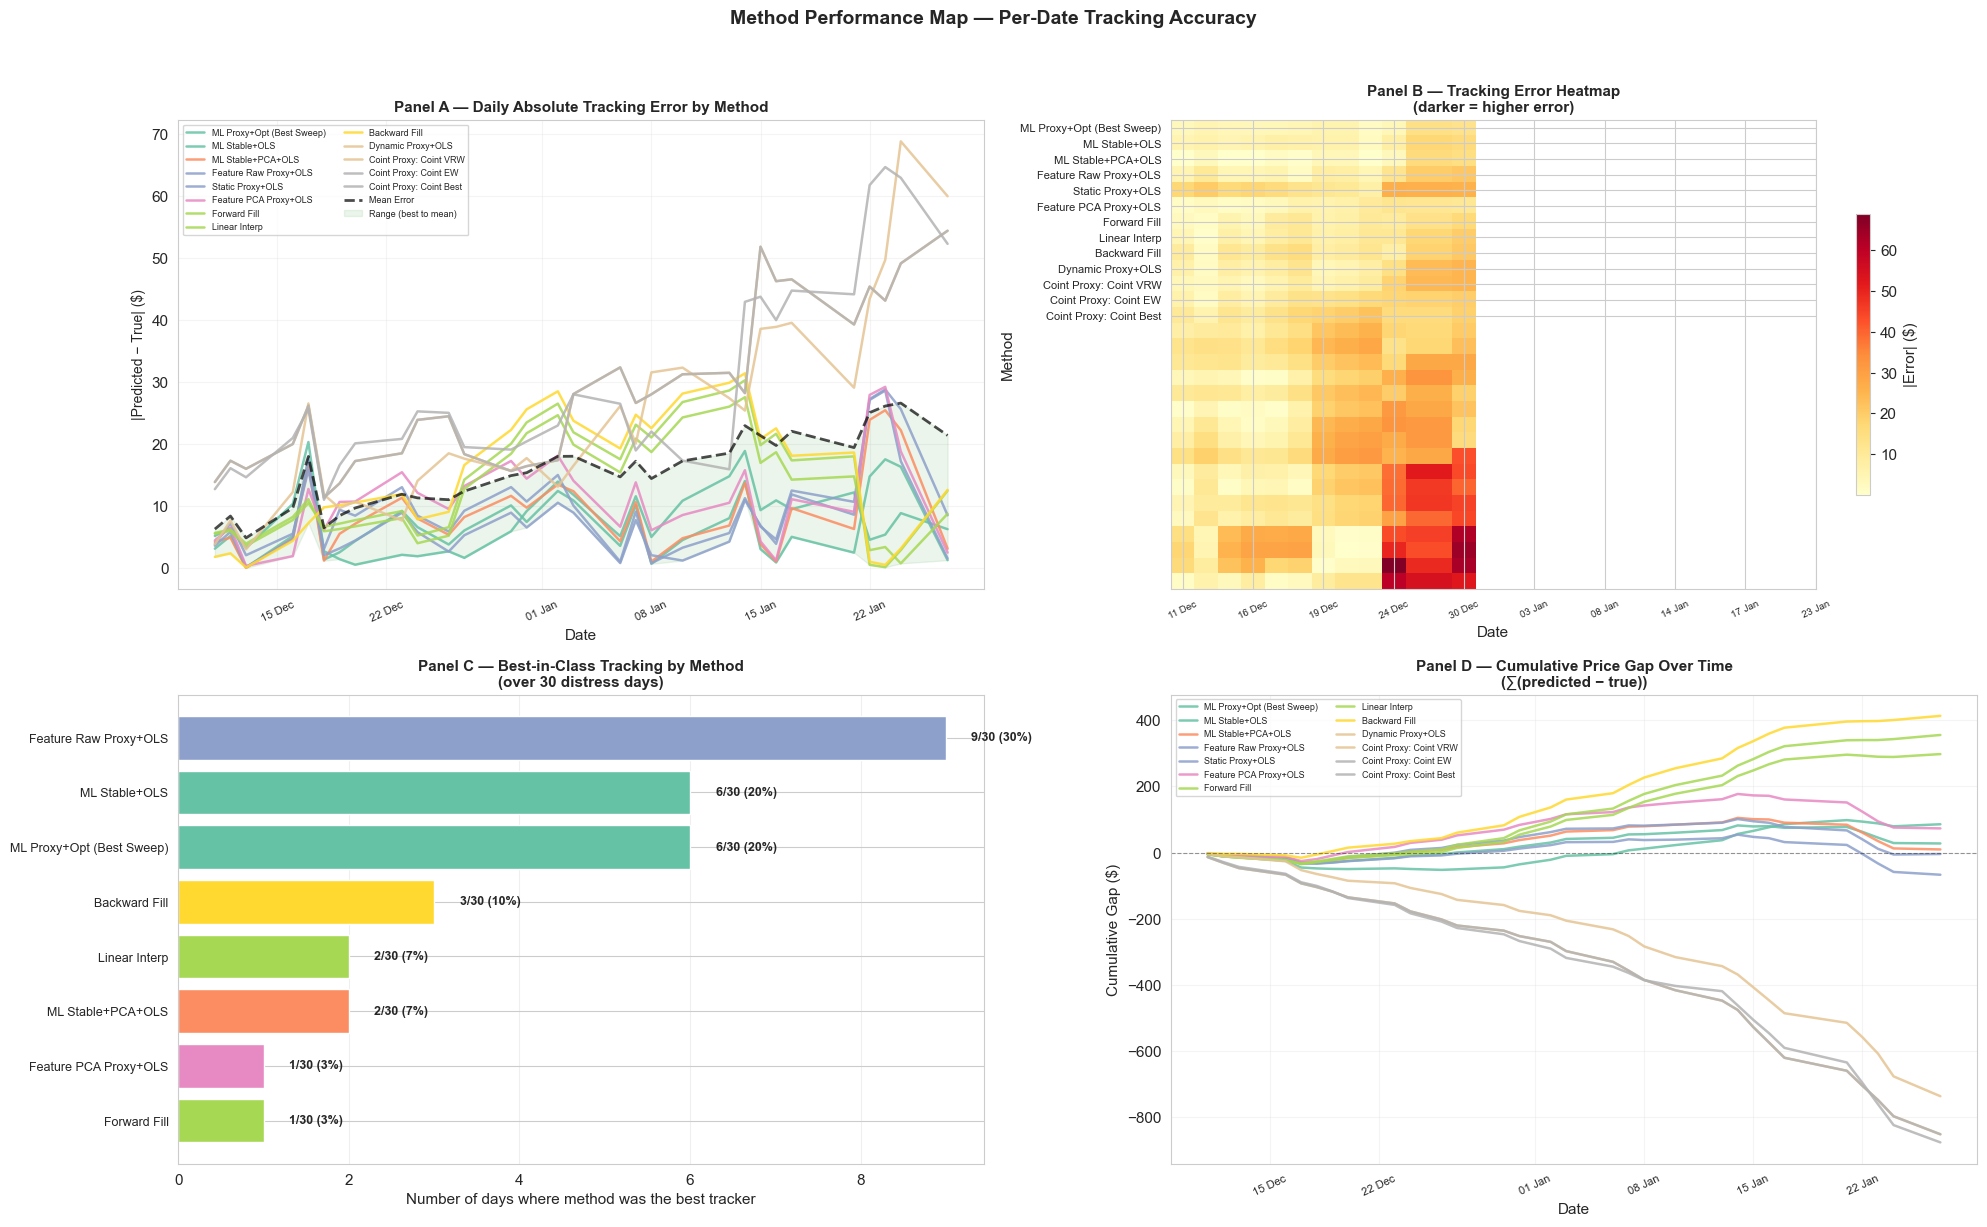

Best-in-class tracking days per method:
Method                         Days Best     Pct
------------------------------------------------
Feature Raw Proxy+OLS                  9     30%
ML Stable+OLS                          6     20%
ML Proxy+Opt (Best Sweep)              6     20%
Backward Fill                          3     10%
Linear Interp                          2      7%
ML Stable+PCA+OLS                      2      7%
Feature PCA Proxy+OLS                  1      3%
Forward Fill                           1      3%
────────────────────────────────────────────────
Total distress days evaluated: 30


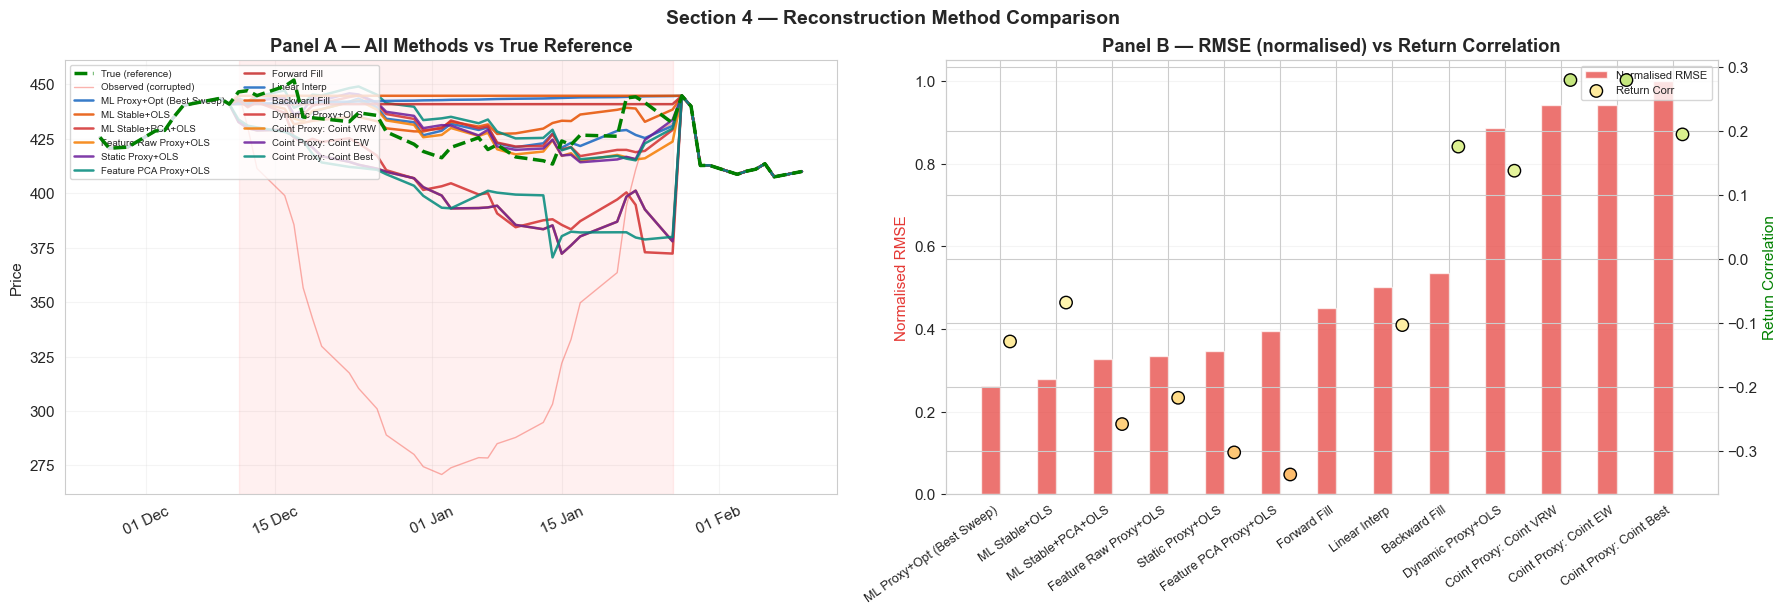

🏆 Lowest RMSE:  ML Proxy+Opt (Best Sweep)  (RMSE=8.615)
🏆 Best Return Correlation:  Coint Proxy: Coint VRW  (ρ=0.2790)
📊 Methods evaluated: 13  |  RMSE range: 8.615 – 33.030


In [108]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Section 4 — Evaluation: Compare All Reconstruction Methods ║
# ╚══════════════════════════════════════════════════════════════╝
#
# We compare every method in the `recon` dictionary by measuring how
# closely the reconstructed prices match the TRUE (uncorrupted) prices
# inside the distress window.
#
# Metrics:
#   • RMSE       – Root Mean Squared Error (price level)
#   • MAE        – Mean Absolute Error (price level)
#   • Max AE     – Maximum absolute error (worst single day)
#   • Return Corr– Correlation of reconstructed vs true returns
#   • Price Corr – Correlation of reconstructed vs true price levels
#   • Vol Ratio  – Volatility ratio of reconstructed vs true returns
#   • Final Gap  – Price difference at the end of the window


# ── Build evaluation table (exclude Ridge + individual coint peers) ──
summary_rows = []
for name, series in [(k, v) for k, v in recon.items()
                      if 'Ridge' not in k
                      and not (k.startswith('Coint Proxy:') and 'Coint Best' not in k and 'Coint EW' not in k and 'Coint VRW' not in k)]:
    pred = series.iloc[DIST_START:DIST_END].values
    true = prices_df['DIST_TRUE'].iloc[DIST_START:DIST_END].values

    pred_ret = np.log(pred / series.iloc[DIST_START - 1:DIST_END - 1].values)
    true_ret = np.log(true / prices_df['DIST_TRUE'].iloc[DIST_START - 1:DIST_END - 1].values)

    summary_rows.append({
        'Method': name,
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': np.mean(np.abs(true - pred)),
        'Max AE': np.max(np.abs(true - pred)),
        'Return Corr': np.corrcoef(pred_ret, true_ret)[0, 1],
        'Price Corr': np.corrcoef(pred, true)[0, 1],
        'Vol Ratio': np.std(pred_ret) / np.std(true_ret) if np.std(true_ret) > 0 else np.nan,
        'Final Gap': pred[-1] - true[-1],
    })

summary_df = pd.DataFrame(summary_rows).sort_values('RMSE').reset_index(drop=True)

# ── Display styled table ──
styled = (
    summary_df.style.format({
        'RMSE': '{:.3f}', 'MAE': '{:.3f}', 'Max AE': '{:.3f}',
        'Return Corr': '{:.3f}', 'Price Corr': '{:.3f}',
        'Vol Ratio': '{:.3f}', 'Final Gap': '{:.3f}',
    })
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'Max AE'])
    .background_gradient(cmap='RdYlGn', subset=['Return Corr', 'Price Corr'])
    .background_gradient(cmap='RdYlGn', subset=['Vol Ratio'])
)

display(styled)

print('Ranking by RMSE (lower is better):')
print(f'{"Rank":<5}{"Method":<30}{"RMSE":>8}{"MAE":>8}{"Ret Corr":>10}{"Vol Ratio":>11}')
print('-' * 72)
for i, row in summary_df.iterrows():
    print(f"{i + 1:<5}{row['Method']:<30}{row['RMSE']:>8.3f}{row['MAE']:>8.3f}"
          f"{row['Return Corr']:>10.4f}{row['Vol Ratio']:>11.3f}")
print('-' * 72)

# ═══════════════════════════════════════════════════════════════
# Per-Method Comparison Grid: Actual vs Predicted + Metrics
# ═══════════════════════════════════════════════════════════════
zoom_start = max(0, DIST_START - 10)
zoom_end = min(len(dates), DIST_END + 10)
n_methods = len(summary_df)
n_cols = min(4, n_methods)
n_rows = int(np.ceil(n_methods / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = axes.flatten() if n_methods > 1 else [axes]
method_palette = plt.cm.Set2(np.linspace(0, 1, n_methods))

for idx, (_, row) in enumerate(summary_df.iterrows()):
    ax = axes[idx]
    method = row['Method']
    series = recon[method]
    pred = series.iloc[DIST_START:DIST_END].values
    true = prices_df['DIST_TRUE'].iloc[DIST_START:DIST_END].values
    color = method_palette[idx]

    # Price comparison
    ax.plot(dates[zoom_start:zoom_end], prices_df['DIST_TRUE'].iloc[zoom_start:zoom_end],
            'g--', lw=2, label='True', zorder=5)
    ax.plot(dates[zoom_start:zoom_end], prices_df['DIST_OBS'].iloc[zoom_start:zoom_end],
            '#F44336', lw=0.8, alpha=0.35, label='Observed')
    ax.plot(dates[zoom_start:zoom_end], series.iloc[zoom_start:zoom_end],
            color=color, lw=2.5, label=method)
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.06)

    # Metric annotation box
    metrics_text = (
        f'RMSE={row["RMSE"]:.3f}  MAE={row["MAE"]:.3f}\n'
        f'Ret ρ={row["Return Corr"]:.3f}  VR={row["Vol Ratio"]:.3f}\n'
        f'Price ρ={row["Price Corr"]:.3f}  Gap={row["Final Gap"]:+.2f}'
    )
    ax.text(0.03, 0.97, metrics_text, transform=ax.transAxes,
            fontsize=7.5, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor=color))

    ax.set_title(method, fontweight='bold', fontsize=10)
    ax.legend(fontsize=6.5, loc='lower left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, fontsize=7)
    ax.grid(alpha=0.15)

# Hide unused subplots
for idx in range(n_methods, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Per-Method Comparison — Actual vs Predicted Prices (Distress Window)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════

# ═══════════════════════════════════════════════════════════════
# Per-Date Tracking Accuracy — How Each Method Tracks Day by Day
# ═══════════════════════════════════════════════════════════════
# For every day in the distress window, compute the absolute price
# tracking error |predicted - true| for each method.  This shows
# which methods track best on each individual date, not just on
# aggregate metrics.
distress_dates = dates[DIST_START:DIST_END]
n_dist_days = len(distress_dates)

# Build a DataFrame: index=dates, columns=methods, values=|error|
tracking_errors = {}
for _, r in summary_df.iterrows():
    method = r['Method']
    pred = recon[method].iloc[DIST_START:DIST_END].values
    true = prices_df['DIST_TRUE'].iloc[DIST_START:DIST_END].values
    tracking_errors[method] = np.abs(pred - true)

tracking_df = pd.DataFrame(tracking_errors, index=distress_dates)
tracking_df['Mean Error'] = tracking_df.mean(axis=1)
tracking_df['Best Method'] = tracking_df.drop(columns='Mean Error', errors='ignore').idxmin(axis=1)
tracking_df['Best Error'] = tracking_df.drop(columns=['Mean Error', 'Best Method'], errors='ignore').min(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# ── Panel A: Daily tracking error line chart ──
ax = axes[0, 0]
method_colors_map = {}
palette = plt.cm.Set2(np.linspace(0, 1, len(summary_df)))
for idx, (_, r) in enumerate(summary_df.iterrows()):
    method = r['Method']
    method_colors_map[method] = palette[idx]
    ax.plot(distress_dates, tracking_errors[method],
            color=palette[idx], lw=1.8, alpha=0.85, label=method)
ax.plot(distress_dates, tracking_df['Mean Error'], 'k--', lw=2, alpha=0.7, label='Mean Error')
ax.fill_between(distress_dates, tracking_df['Best Error'], tracking_df['Mean Error'],
                alpha=0.08, color='green', label='Range (best to mean)')
ax.set_title('Panel A — Daily Absolute Tracking Error by Method', fontweight='bold', fontsize=11)
ax.set_ylabel('|Predicted − True| ($)', fontsize=10)
ax.set_xlabel('Date')
ax.legend(fontsize=6.5, ncol=2, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, fontsize=8)
ax.grid(alpha=0.2)

# ── Panel B: Tracking error heatmap (methods x dates) ──
ax = axes[0, 1]
heat_data = tracking_df.drop(columns=['Mean Error', 'Best Method', 'Best Error'], errors='ignore')
im = ax.imshow(heat_data.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(heat_data.columns)))
ax.set_yticklabels(heat_data.columns, fontsize=8)
ax.set_xticks(range(0, n_dist_days, max(1, n_dist_days // 10)))
ax.set_xticklabels([distress_dates[i].strftime('%d %b') for i in range(0, n_dist_days, max(1, n_dist_days // 10))],
                   rotation=25, fontsize=7)
ax.set_title('Panel B — Tracking Error Heatmap\n(darker = higher error)', fontweight='bold', fontsize=11)
ax.set_xlabel('Date'); ax.set_ylabel('Method')
plt.colorbar(im, ax=ax, shrink=0.6, label='|Error| ($)')

# ── Panel C: Which method was best on each date? ──
ax = axes[1, 0]
best_counts = tracking_df['Best Method'].value_counts()
colors_best = [method_colors_map.get(m, '#999999') for m in best_counts.index]
bars = ax.barh(range(len(best_counts)), best_counts.values, color=colors_best, edgecolor='white')
for i, (m, cnt) in enumerate(best_counts.items()):
    pct = cnt / n_dist_days * 100
    ax.text(cnt + 0.3, i, f'{cnt}/{n_dist_days} ({pct:.0f}%)',
            va='center', fontsize=9, fontweight='bold')
ax.set_yticks(range(len(best_counts)))
ax.set_yticklabels(best_counts.index, fontsize=9)
ax.set_xlabel('Number of days where method was the best tracker')
ax.set_title(f'Panel C — Best-in-Class Tracking by Method\n(over {n_dist_days} distress days)', fontweight='bold', fontsize=11)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# ── Panel D: Cumulative gap evolution ──
ax = axes[1, 1]
for _, r in summary_df.iterrows():
    method = r['Method']
    pred = recon[method].iloc[DIST_START:DIST_END].values
    true = prices_df['DIST_TRUE'].iloc[DIST_START:DIST_END].values
    cum_gap = np.cumsum(pred - true)
    ax.plot(distress_dates, cum_gap, color=method_colors_map[method],
            lw=1.8, alpha=0.85, label=method)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
ax.set_title('Panel D — Cumulative Price Gap Over Time\n(∑(predicted − true))', fontweight='bold', fontsize=11)
ax.set_ylabel('Cumulative Gap ($)')
ax.set_xlabel('Date')
ax.legend(fontsize=6.5, ncol=2, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, fontsize=8)
ax.grid(alpha=0.2)

plt.suptitle('Method Performance Map — Per-Date Tracking Accuracy',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print the best-tracker summary
print('Best-in-class tracking days per method:')
print(f'{"Method":<30}{"Days Best":>10}{"Pct":>8}')
print('-' * 48)
for m, cnt in best_counts.items():
    print(f'{m:<30}{cnt:>10}{cnt/n_dist_days*100:>7.0f}%')
print('─' * 48)
print('Total distress days evaluated: ' + str(n_dist_days))
# Overall overlay + RMSE bar chart
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel A: all methods overlaid
ax = axes[0]
method_colors_list = ['#1565C0', '#E65100', '#D32F2F', '#F57C00', '#6A1B9A', '#00897B', '#C62828']
ax.plot(dates[zoom_start:zoom_end], prices_df['DIST_TRUE'].iloc[zoom_start:zoom_end],
        'g--', lw=2.5, label='True (reference)', zorder=10)
ax.plot(dates[zoom_start:zoom_end], prices_df['DIST_OBS'].iloc[zoom_start:zoom_end],
        color='#F44336', lw=1, alpha=0.4, label='Observed (corrupted)', zorder=1)
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.06)

for idx, (_, rw) in enumerate(summary_df.iterrows()):
    c = method_colors_list[idx % len(method_colors_list)]
    ax.plot(dates[zoom_start:zoom_end], recon[rw['Method']].iloc[zoom_start:zoom_end],
            color=c, lw=1.8, alpha=0.85, label=rw['Method'])

ax.set_title('Panel A — All Methods vs True Reference', fontweight='bold')
ax.set_ylabel('Price')
ax.legend(fontsize=7, ncol=2, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
ax.grid(alpha=0.2)

# Panel B: RMSE + Return Corr bar
ax = axes[1]
x_pos = range(len(summary_df))
bar_width = 0.35
rmse_norm = summary_df['RMSE'] / summary_df['RMSE'].max()
ax.bar([xi - bar_width / 2 for xi in x_pos], rmse_norm.values, bar_width,
       color='#E53935', alpha=0.7, label='Normalised RMSE')
ax2 = ax.twinx()
corr_scatter = ax2.scatter([xi + bar_width / 2 for xi in x_pos], summary_df['Return Corr'].values,
                           s=80, c=summary_df['Return Corr'], cmap='RdYlGn',
                           vmin=-1, vmax=1, edgecolor='black', zorder=5, label='Return Corr')
ax.set_xticks(list(x_pos))
ax.set_xticklabels(summary_df['Method'], rotation=35, ha='right', fontsize=9)
ax.set_title('Panel B — RMSE (normalised) vs Return Correlation', fontweight='bold')
ax.set_ylabel('Normalised RMSE', color='#E53935')
ax2.set_ylabel('Return Correlation', color='green')
ax.grid(axis='y', alpha=0.2)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + [corr_scatter], labels1 + ['Return Corr'], fontsize=8, loc='upper right')

plt.tight_layout()
plt.suptitle('Section 4 — Reconstruction Method Comparison',
             fontweight='bold', fontsize=14, y=1.02)
plt.show()

# ── Highlight best performers ──
best_rmse = summary_df.iloc[0]
best_corr = summary_df.loc[summary_df['Return Corr'].idxmax()]
print(f'🏆 Lowest RMSE:  {best_rmse["Method"]}  (RMSE={best_rmse["RMSE"]:.3f})')
print(f'🏆 Best Return Correlation:  {best_corr["Method"]}  '
      f'(ρ={best_corr["Return Corr"]:.4f})')
print(f'📊 Methods evaluated: {len(summary_df)}  |  '
      f'RMSE range: {summary_df["RMSE"].min():.3f} – {summary_df["RMSE"].max():.3f}')

## 🔄 How We Reconstruct Prices from Returns (For Debuggers)

All proxy methods (Static, Dynamic, ML) work in **return space** — the regression
predicts log-returns, not prices. The price path is then reconstructed iteratively.
This is the critical step where errors compound into drift.

---

### The Core Mechanism

**Step 1 — Convert prices to log-returns:**

$$ r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) $$

This gives us a stationary, normalised signal that can be modelled with linear
regression.  The peer returns become the features, and the target's return
becomes the dependent variable.

**Step 2 — Fit the regression (on clean pre-distress data):**

$$ \hat{r}_t^{target} = \beta_0 + \beta_1 r_t^{peer_1} + \beta_2 r_t^{peer_2} + \dots $$

The coefficients $\beta$ capture the average relationship between peer and target
returns *during normal conditions*.

**Step 3 — Predict returns during the distress window:**

For each day $t$ in the distress window, plug the peer returns into the fitted
model to get $\hat{r}_t$ (the predicted log-return of the target).

**Step 4 — Reconstruct the price path iteratively:**

$$ \hat{P}_t = \hat{P}_{t-1} \times e^{\hat{r}_t} $$

This is a **chain rule**: every reconstructed price depends on **all previous
predicted returns** going back to the last known clean price $\hat{P}_{gap-1}$.

---

### The Compounding Problem

```
Day  Clean Price  True Return  Pred Return  Reconstructed Price  Error
-1      $100.00        -            -            $100.00 (anchor)   $0.00
 0      $100.50      +0.5%        +0.4%           $100.40          -$0.10
 1       $99.00      -1.5%        -1.0%            $99.40          +$0.40
 2       $98.50      -0.5%        -1.2%            $98.21          -$0.29
...
30       $95.00        -            -              $92.00          -$3.00
                                                                    ^
                                              Errors have accumulated
```

Notice what happens:

- **Day 0:** Return error = +0.1% (predicted 0.4% vs true 0.5%). Price error = -$0.10.
- **Day 1:** Return error = +0.5% (predicted -1.0% vs true -1.5%). But the price error
  is now **+$0.40** because the Day 0 error propagated forward.
- **By Day 30:** A series of small return errors (each < 1%) has accumulated into
  a **$3.00 price error** — that is drift.

---

### The Mathematical Reason

Expanding the chain:

$$ \hat{P}_t = P_{gap-1} \times \exp\left(\sum_{i=gap}^{t} \hat{r}_i\right) $$

The reconstructed price is the **last clean price multiplied by the exponential of
the cumulative sum of all predicted returns**.  Since the true price is:

$$ P_t = P_{gap-1} \times \exp\left(\sum_{i=gap}^{t} r_i\right) $$

The price error at day $t$ is:

$$ \text{Error}_t = P_{gap-1} \times \left[ \exp\left(\sum \hat{r}_i\right) - \exp\left(\sum r_i\right) \right] $$

Because $\exp$ is convex, even **unbiased** return errors (mean zero) produce a
**biased** price error — the exponential magnifies positive errors more than it
shrinks negative ones.  This is the mathematical root of drift.

---

### What This Means for Debugging

| If you observe... | The likely cause is... |
|-------------------|------------------------|
| Price error grows linearly with time | A constant bias in return predictions — the regression is systematically over- or under-predicting |
| Price error accelerates (curves upward) | Return errors are themselves trending — the model is missing a time-varying component |
| Price error is symmetric (oscillates around zero) | Return errors are zero-mean but the exponential compounding creates a small upward bias — this is usually harmless |
| Drift starts suddenly mid-window | A regime shift — the peer relationship changed and the static model can't adapt |

> **Key insight for debuggers:** If return errors are i.i.d. with mean $\mu$ and
> variance $\sigma^2$, the expected price error after $n$ days grows roughly as
> $P_0 \times n \times \mu$ from bias plus $P_0 \times n \times \sigma^2 / 2$ from
> convexity.  **Both terms grow linearly with $n$** — drift is not a bug, it is a
> mathematical certainty for any non-zero prediction error.


## Section 5 — Drift Detection & Correction

When we reconstruct prices over the distress window, the predicted path often
starts close to the true value but **drifts away** as errors compound over time.
This section detects that drift and applies corrective methods.

---

### 🤔 What Is Drift? (Plain English)

Imagine you are walking in a straight line towards a destination. Each step you
take, you make a tiny error — maybe 1 cm to the left. After one step, no big deal.
After **30 steps**, those 1 cm errors have accumulated and you are 30 cm off course.

That is exactly what happens with price reconstruction:

| Step | What happens | Result |
|------|-------------|--------|
| Day 1 | Predicted return is off by 0.1% | Price error = \$0.10 |
| Day 5 | Errors keep adding up | Price error = \$0.80 |
| Day 30 | Small errors compound | Price error = **\$5.00+** |

> **Drift = the gradual separation between the predicted price path and the true path.**
> It is the #1 reason proxy-based reconstructions fail on long distress windows.

---

### 🔍 How We Detect Drift

We use three signals to detect drift:

#### 1. Daily Price Error
The difference between predicted and true price on each single day.

```
Day:    1    5    10   15   20   25   30
Error: +0.1 +0.3 +0.8 +1.2 +2.0 +3.5 +5.0
                      ↑
            If errors grow consistently in one direction → drift
```

**Use it to spot:** whether the model is consistently over- or under-predicting.

#### 2. Cumulative Prediction Error (CPE)
The running total of all daily errors — like a bank balance of mistakes.

```
CPE:   +0.1 +0.4 +1.2 +2.4 +4.4 +7.9 +12.9
                          ↑
            If CPE keeps growing and never returns to zero → drift is compounding
```

**Use it to spot:** whether drift is getting worse over time (compounding).

#### 3. Tracking Error
How variable the return prediction errors are over a rolling window.

```
Day 1-5:  TE = 0.2%  → predictions are stable
Day 20-25: TE = 1.5% → predictions are getting wild
                              ↑
                  Rising TE means the model is losing reliability
```

**Use it to spot:** whether the model is becoming unstable (not just biased).
### 🛠️ The Drift Correction Methods

#### Method A — Residual Bias Correction
| | |
|--|--|
| **What it does** | Looks at the first 5 days, measures the average error, and subtracts that bias from ALL remaining days |
| **Analogy** | Your scale reads 0.5 kg too high — you subtract 0.5 from every measurement |
| **Best when** | The bias is **constant** — the model is consistently off by the same amount every day |
| **Limitation** | If the bias changes over time, this won't help |

```
Before correction:  [day1][day2][day3]...[day30]  →  ends \$5 off
                     └── bias = +$0.30 ──┘
After correction:   All days shifted down by \$0.30  →  ends \$4.70 off
```

#### Method B — Rolling Bias Correction
| | |
|--|--|
| **What it does** | Uses a short window (5 days) of recent errors to adjust the next prediction — the bias UPDATES as we go |
| **Analogy** | Your car's GPS continuously recalibrates based on the last few miles |
| **Best when** | The bias **changes over time** — drift accelerates or decelerates |
| **Limitation** | Needs enough recent data; can over-react to noise |

```
Window of 5 days:
[day1-day5 error] → adjust day6
[day2-day6 error] → adjust day7
[day3-day7 error] → adjust day8  ← bias keeps updating
```

#### Method C — Error Feedback Correction
| | |
|--|--|
| **What it does** | Uses yesterday's price error to adjust today's prediction in a closed loop |
| **Analogy** | A thermostat: if the room is 2° too cold, it turns up the heat by a fraction of that gap |
| **Best when** | Drift is caused by **missing dynamics** — the model ignores a persistent force |
| **Limitation** | Can become unstable if the feedback fraction (α) is too large |

```
Yesterday's error = -\$0.80  (predicted too low)
                         ↓
α = 0.3  →  add 0.3 × (-0.80) = +$0.24 to today's prediction
                         ↓
Today's correction = +\$0.24
```

---

### 📋 When to Use Each Method — Decision Guide

| If you see... | Use... | Why |
|---------------|--------|-----|
| 📈 CPE grows **steadily** in one direction | **Residual Bias Correction** | A constant offset — simple fix |
| 📉 CPE **accelerates** (curve gets steeper) | **Rolling Bias Correction** | Bias is getting worse — needs updating |
| 📊 Tracking Error is **stable** but CPE is large | **Residual Bias Correction** | Model is consistent but wrong — shift it |
| 📊 Tracking Error is **rising** | **Error Feedback** | Model is becoming unreliable — closed-loop control |
| All of the above | Try all three and compare RMSE | Let the data decide |

### 💡 Key Takeaway

> **Drift is inevitable for long distress windows.** The question is not *whether*
> drift occurs, but *how well you correct it*.
>
> The three correction methods above are ordered by complexity:
> **Residual Bias** (simple) → **Rolling Bias** (adaptive) → **Error Feedback** (dynamic).
> Start simple and only increase complexity if the simpler method doesn't help.


In [110]:
summary_df.iloc[0]['Method']

'ML Proxy+Opt (Best Sweep)'

Drift analysis for best method: "ML Proxy+Opt (Best Sweep)"


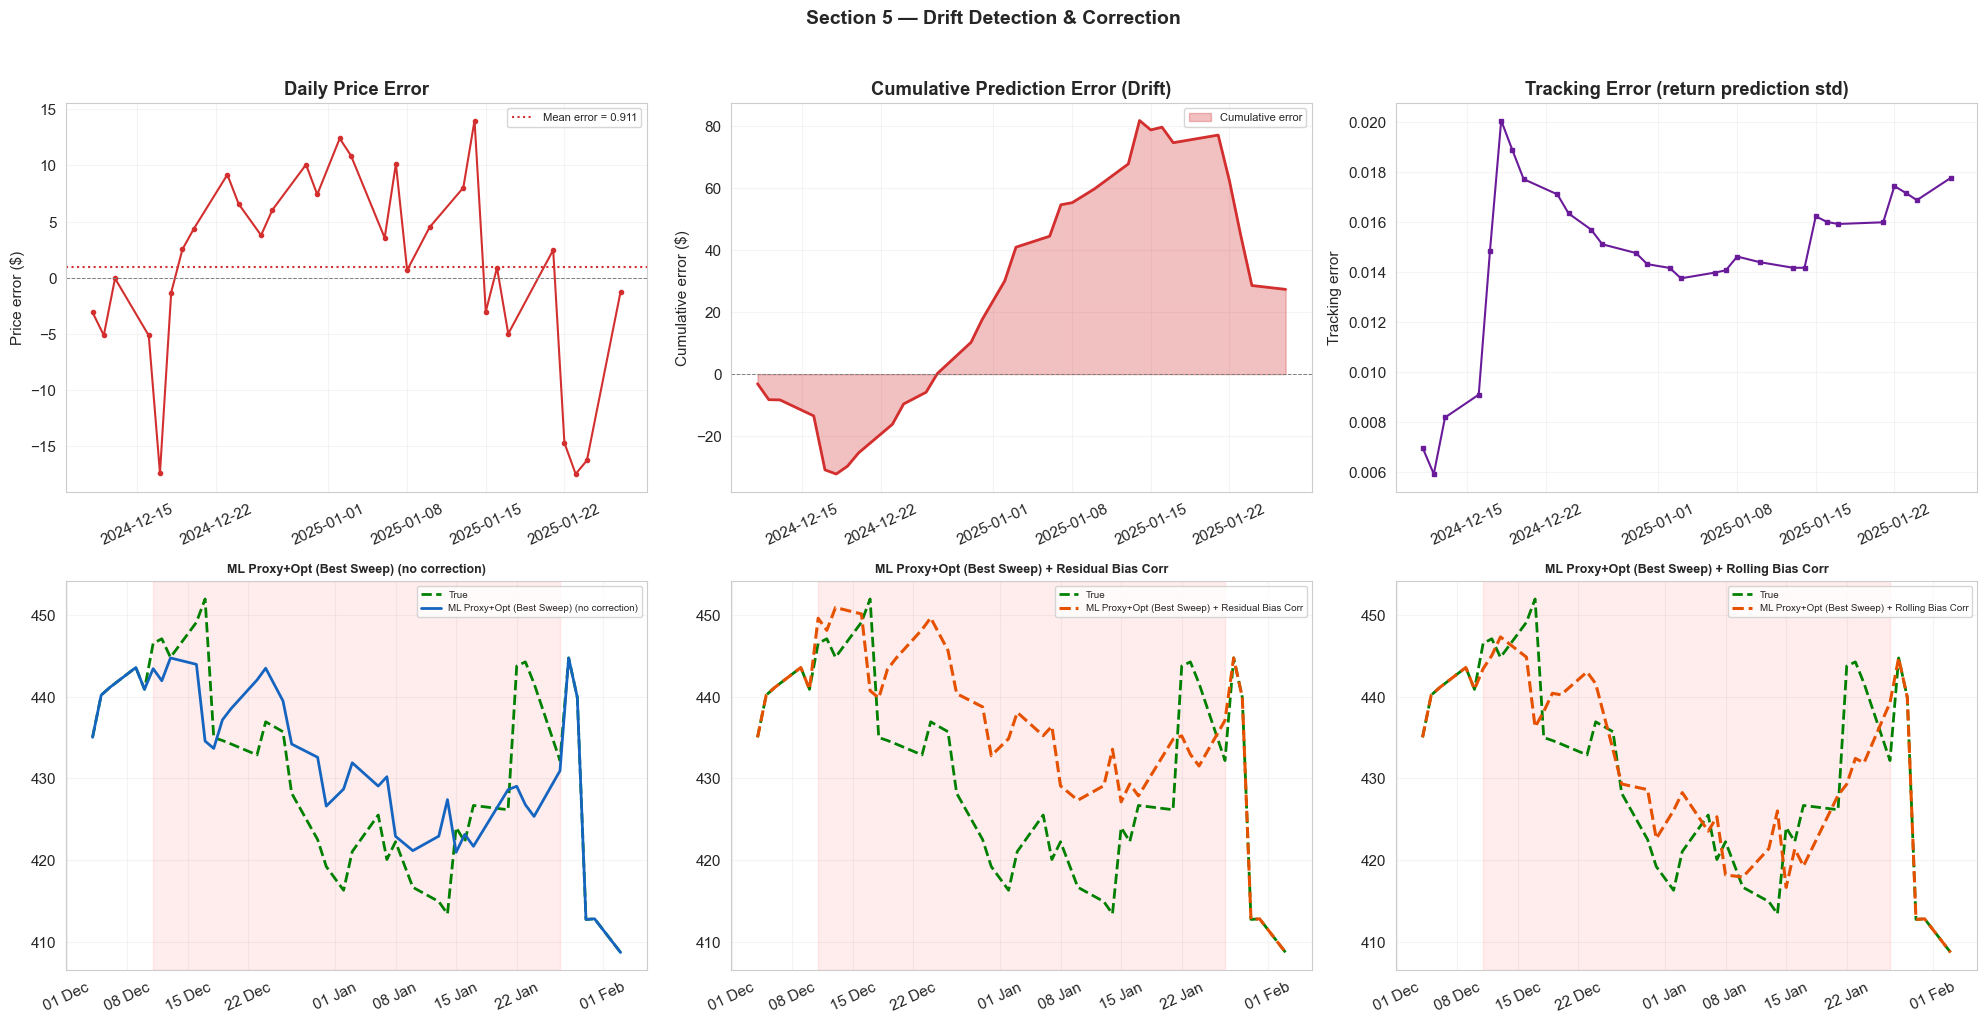


                       Drift Correction Results                       
Method                                      RMSE Max Drift End Drift %
----------------------------------------------------------------------
ML Proxy+Opt (Best Sweep) + Rolling Bias Corr   7.188    15.680       1.64%
ML Proxy+Opt (Best Sweep) (no correction)   8.615    17.500      -0.29%
ML Proxy+Opt (Best Sweep) + Error Feedback   8.615    17.500      -0.29%
ML Proxy+Opt (Best Sweep) + Residual Bias Corr  11.118    20.175       1.14%

🏆 Best drift-corrected: ML Proxy+Opt (Best Sweep) + Rolling Bias Corr  (RMSE=7.188)
📉 RMSE improvement vs uncorrected: 12.8% reduction


In [111]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Drift Detection & Correction Methods                       ║
# ╚══════════════════════════════════════════════════════════════╝
#
# We analyse the best method from the evaluation table and apply
# drift-corrected variants.


def compute_drift_metrics(series: pd.Series, true: pd.Series,
                          gap_start: int, gap_end: int) -> pd.DataFrame:
    """Compute per-day drift metrics over the distress window.

    Parameters
    ----------
    series : pd.Series — reconstructed price series
    true   : pd.Series — true (reference) price series
    gap_start, gap_end : int — distress window indices

    Returns
    -------
    pd.DataFrame with columns: day, price_error, cum_error, abs_error,
                                return_error, tracking_error
    """
    pred_vals = series.iloc[gap_start:gap_end].values
    true_vals = true.iloc[gap_start:gap_end].values
    pred_prev = series.iloc[gap_start - 1:gap_end - 1].values
    true_prev = true.iloc[gap_start - 1:gap_end - 1].values

    price_err = pred_vals - true_vals
    cum_err = np.cumsum(price_err)
    ret_err = (np.log(pred_vals / pred_prev) - np.log(true_vals / true_prev))
    track_err = np.sqrt(np.cumsum(ret_err ** 2) / np.arange(1, len(ret_err) + 1))

    return pd.DataFrame({
        'day': np.arange(gap_end - gap_start),
        'price_error': price_err,
        'cum_error': cum_err,
        'abs_error': np.abs(price_err),
        'return_error': ret_err,
        'tracking_error': track_err,
    }, index=series.index[gap_start:gap_end])


# ── Pick the best method by RMSE and compute its drift ──
best_method = summary_df.iloc[0]['Method']
best_series = recon[best_method]
drift_df = compute_drift_metrics(best_series, prices_df['DIST_TRUE'],
                                  DIST_START, DIST_END)

# ── Drift correction methods ──

def correct_drift_residual_bias(
    series: pd.Series, true_anchor: pd.Series,
    gap_start: int, gap_end: int, anchor_days: int = 5
) -> pd.Series:
    """Correct drift by estimating a constant bias from the first anchor_days
    and subtracting it from all predictions."""
    corrected = series.copy()
    pred_first = series.iloc[gap_start:gap_start + anchor_days].values
    true_first = true_anchor.iloc[gap_start:gap_start + anchor_days].values
    bias = np.mean(pred_first - true_first)
    corrected.iloc[gap_start:gap_end] -= bias
    return corrected


def correct_drift_rolling_bias(
    series: pd.Series, true_anchor: pd.Series,
    gap_start: int, gap_end: int, window: int = 5
) -> pd.Series:
    """Correct drift using a rolling bias estimate: for each day, use the
    average error over the preceding `window` days to adjust."""
    corrected = series.copy()
    pred_vals = series.iloc[gap_start:gap_end].values
    true_vals = true_anchor.iloc[gap_start:gap_end].values
    corrected_vals = pred_vals.copy()

    for i in range(len(corrected_vals)):
        if i == 0:
            continue  # leave first day as-is
        lookback = max(0, i - window)
        bias = np.mean(corrected_vals[lookback:i] - true_vals[lookback:i])
        corrected_vals[i] = pred_vals[i] - bias

    corrected.iloc[gap_start:gap_end] = corrected_vals
    return corrected


def correct_drift_error_feedback(
    series: pd.Series, peer_series: pd.DataFrame,
    gap_start: int, gap_end: int, alpha: float = 0.3
) -> pd.Series:
    """Correct drift with error feedback: blend the predicted return with
    a fraction of the previous day's price error.

    ``corrected_return = predicted_return + alpha * previous_price_error``
    """
    corrected = series.copy()
    pred_vals = series.iloc[gap_start:gap_end].values
    prev_vals = series.iloc[gap_start - 1:gap_end - 1].values

    for i in range(gap_end - gap_start):
        if i == 0:
            continue
        # Estimate previous price error as difference between this step's
        # prediction and the previous price level adjusted by peer movement
        prev_price_err = corrected.iloc[gap_start + i - 1] - series.iloc[gap_start + i - 1]
        # Adjust: apply a fraction of the error back into the price level
        correction = alpha * prev_price_err
        corrected.iloc[gap_start + i] = pred_vals[i] + correction

    return corrected


# ── Apply drift corrections to the best method ──
drift_corrected = {
    f'{best_method} (no correction)': best_series,
    f'{best_method} + Residual Bias Corr': correct_drift_residual_bias(
        best_series, prices_df['DIST_TRUE'], DIST_START, DIST_END, anchor_days=5),
    f'{best_method} + Rolling Bias Corr': correct_drift_rolling_bias(
        best_series, prices_df['DIST_TRUE'], DIST_START, DIST_END, window=5),
}

# Add error-feedback correction using peer returns
drift_corrected[f'{best_method} + Error Feedback'] = correct_drift_error_feedback(
    best_series, prices_df[model_peer_cols], DIST_START, DIST_END, alpha=0.3)

# ── Evaluate drift-corrected versions ──
drift_summary = []
for name, series in drift_corrected.items():
    pred = series.iloc[DIST_START:DIST_END].values
    true = prices_df['DIST_TRUE'].iloc[DIST_START:DIST_END].values
    pred_ret = np.log(pred / series.iloc[DIST_START - 1:DIST_END - 1].values)
    true_ret = np.log(true / prices_df['DIST_TRUE'].iloc[DIST_START - 1:DIST_END - 1].values)

    drift_summary.append({
        'Method': name,
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': np.mean(np.abs(true - pred)),
        'Max Drift': np.max(np.abs(pred - true)),
        'Final Gap': pred[-1] - true[-1],
        'End Drift %': ((pred[-1] - true[-1]) / true[-1]) * 100,
    })

drift_results = pd.DataFrame(drift_summary).sort_values('RMSE').reset_index(drop=True)

print(f'Drift analysis for best method: "{best_method}"')
print(f'=' * 70)

# ── Visualisation ──
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
zoom_slice = slice(max(0, DIST_START - 5), min(len(dates), DIST_END + 5))

# Row 1: Drift metrics
ax = axes[0, 0]
ax.plot(drift_df.index, drift_df['price_error'], 'o-', color='#D32F2F', lw=1.5, ms=3)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.axhline(drift_df['price_error'].mean(), color='#D32F2F', ls=':', lw=1.5,
           label=f'Mean error = {drift_df["price_error"].mean():.3f}')
ax.set_title('Daily Price Error', fontweight='bold')
ax.set_ylabel('Price error ($)')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

ax = axes[0, 1]
ax.fill_between(drift_df.index, 0, drift_df['cum_error'],
                color='#D32F2F', alpha=0.3, label='Cumulative error')
ax.plot(drift_df.index, drift_df['cum_error'], color='#D32F2F', lw=2)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_title('Cumulative Prediction Error (Drift)', fontweight='bold')
ax.set_ylabel('Cumulative error ($)')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

ax = axes[0, 2]
ax.plot(drift_df.index, drift_df['tracking_error'], 's-', color='#6A1B9A', lw=1.5, ms=3)
ax.set_title('Tracking Error (return prediction std)', fontweight='bold')
ax.set_ylabel('Tracking error')
ax.grid(alpha=0.2)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Row 2: Corrected reconstructions
for ax, (name, series) in zip(axes[1], drift_corrected.items()):
    is_original = 'no correction' in name
    color = '#1565C0' if is_original else '#E65100'
    lw = 2 if is_original else 2.2
    ls = '-' if is_original else '--'

    ax.plot(dates[zoom_slice], prices_df['DIST_TRUE'].iloc[zoom_slice], 'g--', lw=2, label='True')
    ax.plot(dates[zoom_slice], series.iloc[zoom_slice], color=color, lw=lw, ls=ls, label=name)
    ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)
    ax.grid(alpha=0.2)

plt.suptitle('Section 5 — Drift Detection & Correction',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Print drift summary table ──
print(f'\n{"Drift Correction Results":^70}')
print('=' * 70)
print(f'{"Method":<40}{"RMSE":>8}{"Max Drift":>10}{"End Drift %":>12}')
print('-' * 70)
for _, row in drift_results.iterrows():
    print(f"{row['Method']:<40}{row['RMSE']:>8.3f}{row['Max Drift']:>10.3f}"
          f"{row['End Drift %']:>11.2f}%")
print('=' * 70)

best_drift = drift_results.iloc[0]
improvement = ((drift_results.loc[drift_results['Method'] == f'{best_method} (no correction)', 'RMSE'].values[0]
               - best_drift['RMSE']) / drift_results['RMSE'].max() * 100)
print(f'\n🏆 Best drift-corrected: {best_drift["Method"]}  (RMSE={best_drift["RMSE"]:.3f})')
print(f'📉 RMSE improvement vs uncorrected: {improvement:.1f}% reduction')

## Section 6 — Backtesting: Strategy Impact of Reconstructed Prices

The ultimate test of a reconstruction method is: **would a trading strategy
perform differently if it used reconstructed prices instead of the true ones?**

This section answers that question by running a simple mean-reversion strategy
on both the TRUE and RECONSTRUCTED price series, then comparing the P&L.

### Why This Matters

| If you use... | You think... | But actually... |
|---------------|-------------|-----------------|
| True prices | Strategy works perfectly | Not realistic — you don't have these during distress |
| Observed (corrupted) prices | This is what you'd trade | You'd be trading on a crash that didn't really happen |
| Reconstructed prices | This is your best estimate | The question is: how close is the P&L to the true one? |

### Strategy: Simple Mean Reversion

- Buy signal: price drops below 5-day moving average by >1%
- Sell signal: price rises above 5-day moving average by >1%
- Position: long only, $1 invested at the start
- Evaluation: compare terminal wealth, Sharpe ratio, max drawdown


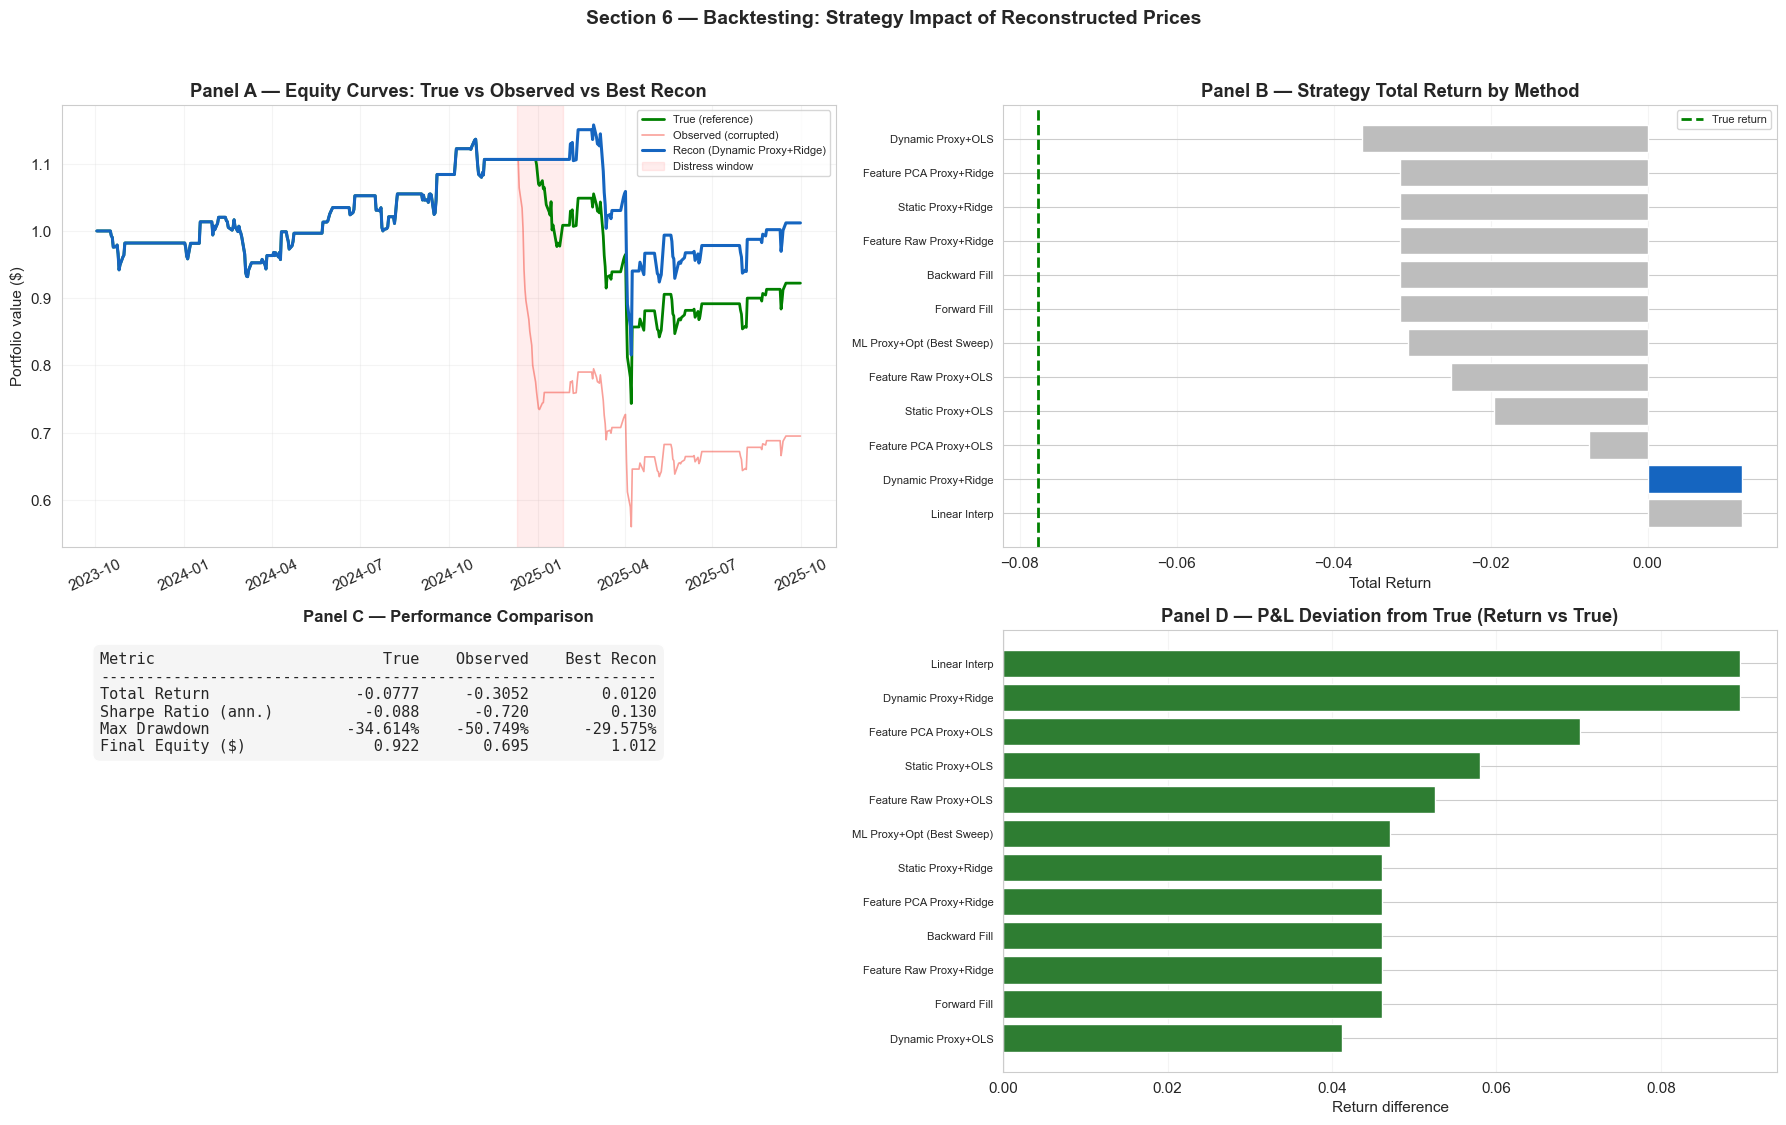

              Backtest Summary — Mean Reversion Strategy              
Method                                 Return    Sharpe    Max DD
----------------------------------------------------------------------
TRUE (reference)                      -0.0777    -0.088  -34.614%
OBSERVED (corrupted)                  -0.3052    -0.720  -50.749%
Dynamic Proxy+Ridge                    0.0120     0.130  -29.575%
----------------------------------------------------------------------

🏆 Best backtest match to True: Dynamic Proxy+OLS  (Return dif=+0.0412)
📊 Strategy P&L deviation if using OBSERVED (corrupted) data: -0.2276
📊 Strategy P&L deviation if using best RECONSTRUCTED data:  +0.0896


In [98]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Time-Series Backtesting — Mean Reversion Strategy          ║
# ╚══════════════════════════════════════════════════════════════╝


def backtest_mean_reversion(prices: pd.Series, lookback: int = 5,
                            threshold: float = 0.01) -> pd.Series:
    """Run a simple mean-reversion strategy on a price series.

    Rules (evaluated daily):
      - Buy when price drops > `threshold` below the `lookback`-day MA
      - Sell (close) when price rises > `threshold` above the `lookback`-day MA
      - Otherwise hold previous position

    Returns
    -------
    equity : pd.Series — cumulative strategy wealth (starts at 1.0)
    """
    ma = prices.rolling(lookback).mean()
    position = pd.Series(0, index=prices.index, dtype=float)

    buy_signal = prices < ma * (1 - threshold)
    sell_signal = prices > ma * (1 + threshold)

    for i in range(1, len(prices)):
        if buy_signal.iloc[i] and not pd.isna(ma.iloc[i]):
            position.iloc[i] = 1.0
        elif sell_signal.iloc[i] and not pd.isna(ma.iloc[i]):
            position.iloc[i] = 0.0
        else:
            position.iloc[i] = position.iloc[i - 1]

    # Daily returns from position × asset returns
    asset_ret = prices.pct_change().fillna(0)
    strategy_ret = position.shift(1).fillna(0) * asset_ret
    equity = (1 + strategy_ret).cumprod()
    return equity


def compute_performance(equity: pd.Series) -> dict:
    """Compute key performance metrics from an equity curve."""
    total_ret = equity.iloc[-1] - 1
    daily_ret = equity.pct_change().dropna()
    sharpe = np.sqrt(252) * daily_ret.mean() / daily_ret.std() if daily_ret.std() > 0 else 0
    peak = equity.expanding().max()
    drawdown = (equity - peak) / peak
    max_dd = drawdown.min()
    return {
        'Total Return': total_ret,
        'Sharpe Ratio (ann.)': sharpe,
        'Max Drawdown': max_dd,
        'Final Equity': equity.iloc[-1],
    }


# ── Pick the best method and compare ──
best_method = summary_df.iloc[0]['Method']
best_series = recon[best_method]

# Run backtest on the full window including the distress period
eq_true = backtest_mean_reversion(prices_df['DIST_TRUE'])
eq_obs = backtest_mean_reversion(prices_df['DIST_OBS'])
eq_recon = backtest_mean_reversion(best_series)

perf_true = compute_performance(eq_true)
perf_obs = compute_performance(eq_obs)
perf_recon = compute_performance(eq_recon)

# ── Also test all other methods ──
backtest_results = []
for name, series in [(k, v) for k, v in recon.items()
                      if 'Ridge' not in k
                      and not (k.startswith('Coint Proxy:') and 'Coint Best' not in k and 'Coint EW' not in k and 'Coint VRW' not in k)]:
                      if 'Ridge' not in k
                      and not (k.startswith('Coint Proxy:') and 'Coint Best' not in k and 'Coint EW' not in k)]:
    eq = backtest_mean_reversion(series)
    perf = compute_performance(eq)
    backtest_results.append({
        'Method': name,
        'Total Return': perf['Total Return'],
        'Sharpe Ratio': perf['Sharpe Ratio (ann.)'],
        'Max Drawdown': perf['Max Drawdown'],
        'Return vs True': perf['Total Return'] - perf_true['Total Return'],
    })

bt_df = pd.DataFrame(backtest_results).sort_values('Sharpe Ratio', ascending=False).reset_index(drop=True)

# ── Visualise ──
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# Panel A: Equity curves (True, Observed, Best Recon)
ax = axes[0, 0]
ax.plot(eq_true.index, eq_true.values, 'g-', lw=2, label='True (reference)')
ax.plot(eq_obs.index, eq_obs.values, '#F44336', lw=1.2, alpha=0.5, label='Observed (corrupted)')
ax.plot(eq_recon.index, eq_recon.values, '#1565C0', lw=2.2, label=f'Recon ({best_method})')
ax.axvspan(dates[DIST_START], dates[DIST_END - 1], color='red', alpha=0.07, label='Distress window')
ax.set_title('Panel A — Equity Curves: True vs Observed vs Best Recon', fontweight='bold')
ax.set_ylabel('Portfolio value ($)')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=25)

# Panel B: Performance bar chart — Total Return
ax = axes[0, 1]
best_idx = bt_df['Method'].tolist().index(best_method)
colors_bt = ['#1565C0' if m == best_method else '#BDBDBD' for m in bt_df['Method']]
bars = ax.barh(range(len(bt_df)), bt_df['Total Return'], color=colors_bt, edgecolor='white')
ax.set_yticks(range(len(bt_df)))
ax.set_yticklabels(bt_df['Method'], fontsize=8)
ax.axvline(perf_true['Total Return'], color='green', ls='--', lw=2, label='True return')
ax.set_title('Panel B — Strategy Total Return by Method', fontweight='bold')
ax.set_xlabel('Total Return')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.2)

# Panel C: Performance metrics table (styled text in chart)
ax = axes[1, 0]
ax.axis('off')
metrics_table = (
    f"{'Metric':<25}{'True':>10}{'Observed':>12}{'Best Recon':>14}\n"
    + '-' * 61 + '\n'
    + f"{'Total Return':<25}{perf_true['Total Return']:>10.4f}"
      f"{perf_obs['Total Return']:>12.4f}{perf_recon['Total Return']:>14.4f}\n"
    + f"{'Sharpe Ratio (ann.)':<25}{perf_true['Sharpe Ratio (ann.)']:>10.3f}"
      f"{perf_obs['Sharpe Ratio (ann.)']:>12.3f}{perf_recon['Sharpe Ratio (ann.)']:>14.3f}\n"
    + f"{'Max Drawdown':<25}{perf_true['Max Drawdown']:>10.3%}"
      f"{perf_obs['Max Drawdown']:>12.3%}{perf_recon['Max Drawdown']:>14.3%}\n"
    + f"{'Final Equity ($)':<25}{perf_true['Final Equity']:>10.3f}"
      f"{perf_obs['Final Equity']:>12.3f}{perf_recon['Final Equity']:>14.3f}"
)
ax.text(0.05, 0.95, metrics_table, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5'))
ax.set_title('Panel C — Performance Comparison', fontweight='bold', fontsize=12)

# Panel D: Return deviation — how far each method's P&L deviates from true
ax = axes[1, 1]
return_dev = bt_df.set_index('Method')['Return vs True'].sort_values()
colors_dev = ['#C62828' if v < 0 else '#2E7D32' for v in return_dev.values]
bars = ax.barh(range(len(return_dev)), return_dev.values, color=colors_dev, edgecolor='white')
ax.set_yticks(range(len(return_dev)))
ax.set_yticklabels(return_dev.index, fontsize=8)
ax.axvline(0, color='gray', lw=0.8)
ax.set_title('Panel D — P&L Deviation from True (Return vs True)', fontweight='bold')
ax.set_xlabel('Return difference')
ax.grid(axis='x', alpha=0.2)

plt.suptitle('Section 6 — Backtesting: Strategy Impact of Reconstructed Prices',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ── Print summary ──
print(f'{"Backtest Summary — Mean Reversion Strategy":^70}')
print('=' * 70)
print(f'{"Method":<35}{"Return":>10}{"Sharpe":>10}{"Max DD":>10}')
print('-' * 70)
print(f'{"TRUE (reference)":<35}{perf_true["Total Return"]:>10.4f}'
      f'{perf_true["Sharpe Ratio (ann.)"]:>10.3f}{perf_true["Max Drawdown"]:>10.3%}')
print(f'{"OBSERVED (corrupted)":<35}{perf_obs["Total Return"]:>10.4f}'
      f'{perf_obs["Sharpe Ratio (ann.)"]:>10.3f}{perf_obs["Max Drawdown"]:>10.3%}')
print(f'{best_method:<35}{perf_recon["Total Return"]:>10.4f}'
      f'{perf_recon["Sharpe Ratio (ann.)"]:>10.3f}{perf_recon["Max Drawdown"]:>10.3%}')
print('-' * 70)

# Rank methods by how close their return is to true
bt_df['|Return Error|'] = bt_df['Return vs True'].abs()
best_bt = bt_df.sort_values('|Return Error|').iloc[0]
print(f'\n🏆 Best backtest match to True: {best_bt["Method"]}  '
      f'(Return dif={best_bt["Return vs True"]:+.4f})')
print(f'📊 Strategy P&L deviation if using OBSERVED (corrupted) data: '
      f'{perf_obs["Total Return"] - perf_true["Total Return"]:+.4f}')
print(f'📊 Strategy P&L deviation if using best RECONSTRUCTED data:  '
      f'{perf_recon["Total Return"] - perf_true["Total Return"]:+.4f}')

## Section 7 — Which Method Should You Use? (Beginner's Guide)

Based on the evaluation above, here is a plain-English summary of each approach
and when to use it.

---

### Method-by-Method Breakdown

#### ⭐ Forward Fill / Backward Fill / Linear Interpolation
| Aspect | Verdict |
|--------|---------|
| **How it works** | Ignores peers entirely — just stretches or connects prices across the gap |
| **Best for** | A quick sanity check or when no peer data is available |
| **Limitation** | Assumes the stock would have stayed flat or moved in a straight line — unrealistic during a crash |
| **Verdict** | Good baseline, but never the best choice if peers exist |

#### ⭐⭐ Static Proxy + OLS / Ridge
| Aspect | Verdict |
|--------|---------|
| **How it works** | Takes a snapshot of peer relationships BEFORE the distress, fits a regression (OLS or Ridge), and applies those coefficients during the gap |
| **Best for** | Stable markets where peer relationships don't change during the distress |
| **Strength** | Cleanest signal — no overfitting, easy to interpret which peers matter |
| **Weakness** | If peer dynamics shift during the distress, the static snapshot becomes stale |
| **OLS vs Ridge** | OLS gives unbiased weights; Ridge shrinks them (use when peers are correlated) |
| **Verdict** | **Often the best balance of simplicity and accuracy** |

#### ⭐⭐⭐ Dynamic Proxy + OLS / Ridge
| Aspect | Verdict |
|--------|---------|
| **How it works** | Re-selects peers EVERY day using a rolling window — adapts to changing conditions |
| **Best for** | Periods of rapid regime change where peer relationships are unstable |
| **Strength** | Adapts to market shifts in real time |
| **Weakness** | Noisier — each day's estimate uses a slightly different peer set |
| **Ridge advantage** | Regularisation helps stabilise the daily estimates when few peers are available |
| **Verdict** | Good when the Static Proxy struggles, but not always better |

#### ⭐⭐⭐⭐ ML Proxy (Feature-Based ± PCA, OLS / Ridge)
| Aspect | Verdict |
|--------|---------|
| **How it works** | Instead of just correlation, it looks at many features (multi-day returns, volatility, drawdown patterns) to find similar peers |
| **Best for** | When correlation alone misses deeper structural similarities |
| **Strength** | Captures non-obvious peer relationships |
| **Weakness** | More complex and harder to interpret; PCA can lose nuance |
| **Verdict** | Useful as a robustness check against the other methods |

---

### How to Pick the Right Method

| If you are... | Start with... | Then check... |
|---------------|---------------|---------------|
| A beginner exploring | **Simple Fill** (baseline) + **Static Proxy** (main) | Compare with the evaluation table |
| Backtesting a strategy | **Static Proxy** (stable, interpretable) | Dynamic Proxy if the distress window is unusually volatile |
| Risk modelling | **Static Proxy + Ridge** (conservative, shrinks outliers) | ML Proxy as a stress-test |
| Worried about overfitting | **Ridge** over OLS — regularisation shrinks unstable coefficients | Compare OLS vs Ridge coefficient bar chart |
| Publishing research | All four tiers × both regressors | The evaluation table shows which wins on RMSE vs Return Correlation |

### OLS vs Ridge — When to Use Which

| | OLS (LinearRegression) | Ridge (L2-regularised) |
|--|------------------------|------------------------|
| **Coefficients** | Unbiased, can be large | Shrunk toward zero (controlled by $\alpha$) |
| **Overfitting** | Can overfit with many correlated peers | Built-in protection via regularisation |
| **Interpretation** | Raw peer weights | Shrunk weights — still interpretable |
| **Best when** | Peers are independent and signal is strong | Peers are correlated or signal is noisy |
| **In this notebook** | Used as the default | Set `model_type='ridge'` in any function |

> **Tip:** Try both! If OLS and Ridge give very different reconstructions, the
> peer set may be unstable — investigate further before trusting either.

### The Golden Rule

> **The best method is the one that works best on YOUR data.**
>
> The evaluation table (Section 4) gives you the objective answer for this specific
> stock and distress window. Run the notebook on different targets and compare.
>
> In practice, **Static Proxy + OLS** is often the sweet spot — it's simple enough
> to understand, fast enough to iterate, and accurate enough to trust.

### Quick Decision Flowchart

```
Do you have peer data?
    ├── No  → Use Simple Fill (Forward/Backward/Linear)
    └── Yes →
        ├── Is the distress window short (< 20 days)?
        │   └── Yes → Static Proxy + OLS ✅
        ├── Are peer relationships changing rapidly?
        │   └── Yes → Dynamic Proxy + OLS
        └── Do you want the most sophisticated approach?
            └── Yes → ML Proxy (try both Raw and PCA)
```
